# 🏥 Project: Predicting Extubation Failure (MIMIC-IV)
### 👨‍💻 Team Members & Roles:
1. **Saad (Team Lead):** Data Extraction (SQL), Final Integration, and Report Writing.
2. **Nawaf (Model Interpreter):** Model Interpretability (SHAP Values) & Advanced Evaluation.
3. **Faisal (Data Engineer):** Data Cleaning, Missing Values, and Feature Engineering (e.g., RSBI).
4. **Abbas (Data Analyst):** Exploratory Data Analysis (EDA) and Statistical Visualizations.
5. **Mohammed (ML Modeler):** Building and Tuning Machine Learning Models (XGBoost, Random Forest).

### 🔗 Project Resources:
* **GitHub Repository:** [Predicting-Extubation-Failure](https://github.com/UIUO0/Predicting-Extubation-Failure)
* **Dataset:** PhysioNet (MIMIC-IV)

In [2]:
# ── Import Essential Libraries ─────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

# ── Define Path (relative to notebook location) ────────────
DATA_PATH = "mimic_data.csv"
print(f'📁 Working directory : {os.getcwd()}')
print(f'📄 Data file         : {DATA_PATH}')
print(f'   File exists?      : {os.path.exists(DATA_PATH)}')

📁 Working directory : /Users/uiuo/Documents/GitHub/Predicting-Extubation-Failure
📄 Data file         : mimic_data.csv
   File exists?      : True


🛑 IMPORTANT: DATA EXTRACTION NOTICE

This cell was executed by the Team Lead (Saad) to fetch the master dataset from PhysioNet/BigQuery.

Status: Completed ✅

Action: The file mimic_data.csv is already generated and saved in the shared Google Drive folder.

Instruction: DO NOT re-run this cell. Re-running it will consume cloud resources and might overwrite any cleaning progress.

Proceed directly to the Data Cleaning & EDA section.

In [3]:
# # ==========================================
# # 🛠️ Task: Data Extraction (All Vitals + Labs + Vent + GCS + Vasopressor + Comorbidities)
# # 👨‍💻 Done by: Saad (Team Lead)
# # ==========================================
# #
# # ⚠️ MAJOR UPGRADE (vs. v1):
# #   1. Reintubation now uses NEW endotracheal-tube-insertion procedureevents
# #      within (1h, 72h] post-extubation — replaces the old proxy that
# #      counted ANY new ICU admission as reintubation.
# #   2. Adds: vent_duration_hours, GCS (eye/verbal/motor),
# #      comorbidity_count, on_vasopressor flag.
# #   3. Adds trend stats: std/max/min for key vitals (resp_rate, spo2, hr).
# #
# # 📦 Output schema: same `mimic_data.csv` filename — backward compatible
# #     (Phase 2 detects new columns gracefully).
#
# from google.colab import auth, drive
# from google.cloud import bigquery
# import pandas as pd, os
#
# auth.authenticate_user()
# drive.mount('/content/drive')
#
# project_id = 'predicting-extubation-failure'
# client = bigquery.Client(project=project_id)
#
# print('⌛ Extracting the Ultimate Clinical Dataset (v2) from PhysioNet...')
#
# query = """
# WITH
#   -- 1) First extubation per ICU stay
#   first_extubation AS (
#     SELECT subject_id, stay_id, starttime AS extubation_time,
#            ROW_NUMBER() OVER(PARTITION BY stay_id ORDER BY starttime) AS rank
#     FROM `physionet-data.mimiciv_3_1_icu.procedureevents`
#     WHERE itemid IN (227194, 225468, 225477)
#   ),
#
#   -- 2) Mechanical-ventilation start time (for vent_duration_hours)
#   vent_start AS (
#     SELECT stay_id, MIN(starttime) AS vent_start_time
#     FROM `physionet-data.mimiciv_3_1_icu.procedureevents`
#     WHERE itemid IN (225792, 225794)        -- invasive + non-invasive vent
#     GROUP BY stay_id
#   ),
#
#   -- 3) Reintubation events (FIXED) — true new tube insertion within 1–72 h
#   reintubation_events AS (
#     SELECT fe.stay_id,
#       MAX(CASE WHEN p2.starttime BETWEEN DATETIME_ADD(fe.extubation_time, INTERVAL 1 HOUR)
#                                       AND DATETIME_ADD(fe.extubation_time, INTERVAL 72 HOUR)
#                THEN 1 ELSE 0 END) AS reintubated
#     FROM first_extubation fe
#     LEFT JOIN `physionet-data.mimiciv_3_1_icu.procedureevents` p2
#       ON fe.subject_id = p2.subject_id
#       AND p2.itemid IN (224263, 224264, 224267, 225792)   -- ETT / invasive vent
#     WHERE fe.rank = 1
#     GROUP BY fe.stay_id
#   ),
#
#   -- 4) Death within 72h
#   death_events AS (
#     SELECT fe.stay_id,
#       MAX(CASE WHEN ad.deathtime BETWEEN fe.extubation_time
#                                       AND DATETIME_ADD(fe.extubation_time, INTERVAL 72 HOUR)
#                THEN 1 ELSE 0 END) AS died
#     FROM first_extubation fe
#     JOIN `physionet-data.mimiciv_3_1_hosp.admissions` ad ON fe.subject_id = ad.subject_id
#     WHERE fe.rank = 1
#     GROUP BY fe.stay_id
#   ),
#
#   demographics AS (
#     SELECT subject_id, gender, anchor_age
#     FROM `physionet-data.mimiciv_3_1_hosp.patients`
#   ),
#
#   -- 5) Comorbidity load (distinct ICD codes on the admission)
#   comorbidities AS (
#     SELECT fe.stay_id, COUNT(DISTINCT di.icd_code) AS comorbidity_count
#     FROM first_extubation fe
#     JOIN `physionet-data.mimiciv_3_1_icu.icustays`        ie ON fe.stay_id = ie.stay_id
#     JOIN `physionet-data.mimiciv_3_1_hosp.diagnoses_icd`  di ON ie.hadm_id = di.hadm_id
#     WHERE fe.rank = 1
#     GROUP BY fe.stay_id
#   ),
#
#   -- 6) Vasopressor flag in last 24h (norepi / epi / vasopressin / phenyl)
#   vasopressors AS (
#     SELECT fe.stay_id,
#       MAX(CASE WHEN inp.itemid IN (221906, 221289, 222315, 221662) THEN 1 ELSE 0 END) AS on_vasopressor
#     FROM first_extubation fe
#     JOIN `physionet-data.mimiciv_3_1_icu.inputevents` inp
#       ON fe.stay_id = inp.stay_id
#       AND inp.starttime BETWEEN DATETIME_SUB(fe.extubation_time, INTERVAL 24 HOUR)
#                              AND fe.extubation_time
#     WHERE fe.rank = 1
#     GROUP BY fe.stay_id
#   ),
#
#   -- 7) Clinical features in 24h before extubation (means + trend stats + GCS)
#   clinical_data_24h AS (
#     SELECT
#       fe.stay_id,
#       -- Vitals (means)
#       ROUND(AVG(CASE WHEN ce.itemid = 220045 THEN ce.valuenum END), 2) AS avg_heart_rate,
#       ROUND(AVG(CASE WHEN ce.itemid = 220210 THEN ce.valuenum END), 2) AS avg_resp_rate,
#       ROUND(AVG(CASE WHEN ce.itemid = 220277 THEN ce.valuenum END), 2) AS avg_spo2,
#       ROUND(AVG(CASE WHEN ce.itemid IN (220052, 220181, 225312) THEN ce.valuenum END), 2) AS avg_map,
#       ROUND(AVG(CASE WHEN ce.itemid = 223762 THEN ce.valuenum
#                      WHEN ce.itemid = 223761 THEN (ce.valuenum - 32) / 1.8 END), 2) AS avg_temp_c,
#       -- Trend stats (variability is clinically informative)
#       ROUND(STDDEV(CASE WHEN ce.itemid = 220210 THEN ce.valuenum END), 2) AS std_resp_rate,
#       ROUND(MAX  (CASE WHEN ce.itemid = 220210 THEN ce.valuenum END), 2) AS max_resp_rate,
#       ROUND(MIN  (CASE WHEN ce.itemid = 220277 THEN ce.valuenum END), 2) AS min_spo2,
#       ROUND(STDDEV(CASE WHEN ce.itemid = 220045 THEN ce.valuenum END), 2) AS std_heart_rate,
#       -- Blood gas
#       ROUND(AVG(CASE WHEN ce.itemid = 223830 THEN ce.valuenum END), 2) AS avg_ph,
#       ROUND(AVG(CASE WHEN ce.itemid = 220224 THEN ce.valuenum END), 2) AS avg_pao2,
#       ROUND(AVG(CASE WHEN ce.itemid = 220235 THEN ce.valuenum END), 2) AS avg_paco2,
#       -- Vent settings
#       ROUND(AVG(CASE WHEN ce.itemid = 223835 THEN ce.valuenum END), 2) AS avg_fio2,
#       ROUND(AVG(CASE WHEN ce.itemid = 220339 THEN ce.valuenum END), 2) AS avg_peep,
#       ROUND(AVG(CASE WHEN ce.itemid IN (224685, 224684, 224686) THEN ce.valuenum END), 2) AS avg_tidal_volume,
#       -- Labs
#       ROUND(AVG(CASE WHEN ce.itemid = 220228 THEN ce.valuenum END), 2) AS avg_hemoglobin,
#       ROUND(AVG(CASE WHEN ce.itemid = 220546 THEN ce.valuenum END), 2) AS avg_wbc,
#       -- GCS components (encephalopathy / sedation depth → strong extubation predictor)
#       ROUND(AVG(CASE WHEN ce.itemid = 220739 THEN ce.valuenum END), 2) AS avg_gcs_eye,
#       ROUND(AVG(CASE WHEN ce.itemid = 223900 THEN ce.valuenum END), 2) AS avg_gcs_verbal,
#       ROUND(AVG(CASE WHEN ce.itemid = 223901 THEN ce.valuenum END), 2) AS avg_gcs_motor
#     FROM first_extubation fe
#     JOIN `physionet-data.mimiciv_3_1_icu.chartevents` ce ON fe.stay_id = ce.stay_id
#     WHERE ce.charttime BETWEEN DATETIME_SUB(fe.extubation_time, INTERVAL 24 HOUR) AND fe.extubation_time
#       AND ce.itemid IN (220045, 220210, 220277, 220052, 220181, 225312, 223761, 223762,
#                         223830, 220224, 220235, 223835, 220339,
#                         224685, 224684, 224686, 220228, 220546,
#                         220739, 223900, 223901)
#     GROUP BY fe.stay_id
#   )
#
# SELECT
#   fe.subject_id, fe.stay_id, fe.extubation_time,
#   d.anchor_age AS age, d.gender,
#   TIMESTAMP_DIFF(fe.extubation_time, vs.vent_start_time, HOUR) AS vent_duration_hours,
#   c.* EXCEPT(stay_id),
#   COALESCE(co.comorbidity_count, 0) AS comorbidity_count,
#   COALESCE(vp.on_vasopressor,    0) AS on_vasopressor,
#   GREATEST(COALESCE(re.reintubated, 0), COALESCE(de.died, 0)) AS failure_label
# FROM first_extubation fe
# LEFT JOIN reintubation_events re ON fe.stay_id = re.stay_id
# LEFT JOIN death_events        de ON fe.stay_id = de.stay_id
# LEFT JOIN demographics         d ON fe.subject_id = d.subject_id
# LEFT JOIN clinical_data_24h    c ON fe.stay_id = c.stay_id
# LEFT JOIN vent_start          vs ON fe.stay_id = vs.stay_id
# LEFT JOIN comorbidities       co ON fe.stay_id = co.stay_id
# LEFT JOIN vasopressors        vp ON fe.stay_id = vp.stay_id
# WHERE fe.rank = 1
# """
#
# df = client.query(query).to_dataframe()
# print(f'✅ Extracted (v2): {len(df):,} cases × {df.shape[1]} columns')
#
# dir_path = '/content/drive/MyDrive/ML Project'
# os.makedirs(dir_path, exist_ok=True)
# file_path = os.path.join(dir_path, 'mimic_data.csv')
# df.to_csv(file_path, index=False)
# print(f'💾 Saved: {file_path}')
# display(df.head())

In [4]:
import os
print(f'📁 Working directory: {os.getcwd()}')
print(f'📂 Files available  : {[f for f in os.listdir(".") if f.endswith(".csv") or f.endswith(".ipynb")]}')

📁 Working directory: /Users/uiuo/Documents/GitHub/Predicting-Extubation-Failure
📂 Files available  : ['Predicting_Extubation_Failure.ipynb', 'mimic_data_cleaned_v2.csv', 'mimic_test.csv', 'mimic_data.csv', 'mimic_train.csv']


# 🛠️ Phase 2: Data Cleaning & Feature Engineering
**Assigned to: Faisal**

Hello Faisal! The master dataset has been successfully extracted from PhysioNet and includes all vital signs, blood gas labs, and ventilator settings.

**Your Tasks:**
1. **Handling Missing Values (Imputation):** Use appropriate imputation techniques (like median or mean) to fill in any missing values, especially for the lab results.
2. **Data Encoding:** Convert the `gender` column from categorical (M/F) to numerical (1/0).
3. **Feature Engineering (Crucial Step):** Since we have `avg_tidal_volume` and `avg_resp_rate`, please calculate the **RSBI (Rapid Shallow Breathing Index)**. *(Note: RSBI = Respiratory Rate / Tidal Volume in Liters).*

**Output Goal:** A 100% clean, numerically encoded DataFrame ready for EDA and Modeling.

In [5]:
import pandas as pd
import numpy as np
import os

DATA_PATH = 'mimic_data.csv'

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print(f'✅ Loaded from: {DATA_PATH}')
    print(f'Shape: {df.shape}')
    display(df.head())
else:
    print(f'❌ Error: mimic_data.csv not found.')
    print(f'   Current directory : {os.getcwd()}')
    print(f'   Files found       : {os.listdir(".")}')

✅ Loaded from: mimic_data.csv
Shape: (24305, 29)


,subject_id,stay_id,extubation_time,age,gender,vent_duration_hours,avg_heart_rate,avg_resp_rate,avg_spo2,avg_map,...,avg_peep,avg_tidal_volume,avg_hemoglobin,avg_wbc,avg_gcs_eye,avg_gcs_verbal,avg_gcs_motor,comorbidity_count,on_vasopressor,failure_label
0,19445052,30218691,2186-04-01 16:06:00,65,M,128.0,62.71,24.58,95.85,82.07,...,6.50,460.00,11.0,15.10,2.83,1.0,4.83,27,0,0
1,15043669,31649138,2168-12-24 05:28:00,74,F,16.0,74.63,19.80,92.94,56.66,...,7.20,396.11,9.2,17.30,1.50,2.0,2.25,19,1,0
2,14818921,33342869,2143-12-26 11:53:00,52,M,95.0,77.10,21.29,95.93,76.06,...,5.40,448.13,8.8,8.65,3.50,1.0,6.00,23,0,0
3,16024629,33713499,2113-09-13 11:21:00,82,M,66.0,94.31,24.42,97.88,66.62,...,9.17,490.40,9.5,7.50,3.00,1.0,6.00,18,1,0
4,18708817,34426602,2181-07-26 06:42:00,77,F,19.0,93.83,25.02,98.82,56.83,...,5.60,408.30,NaN,NaN,2.50,1.0,1.00,20,1,1


In [6]:
# ── Step 1: Drop non-feature column ───────────────────────
df = df.drop(columns=['extubation_time'])

# ── Step 2: Encode gender ──────────────────────────────────
df['gender'] = df['gender'].map({'M': 1, 'F': 0})
print('✅ Gender encoded: M=1, F=0')

✅ Gender encoded: M=1, F=0


In [7]:
# ── Step 3: HIPAA Age Fix ─────────────────────────────────
# MIMIC-IV masks ages > 89 as 91 for patient privacy (HIPAA)
# We add a binary flag to preserve this information for the model
print(f'Patients with HIPAA-masked age (91): {(df["age"] == 91).sum()}')
df['age_masked'] = (df['age'] == 91).astype(int)
print('✅ age_masked column added (1 = HIPAA-protected patient)')

Patients with HIPAA-masked age (91): 543
✅ age_masked column added (1 = HIPAA-protected patient)


In [8]:
# ── Step 4: Sentinel Handling + Physiological Outlier Capping ──
# Action Plan 1.1 — sentinel codes (e.g. 999,999) in MIMIC labs mean "missing"
# Action Plan 1.2 — apply medically-grounded bounds for ALL clinical columns
# Anything outside the plausible physiological range → NaN (imputed in Step 6)
#
# v2 UPGRADE: bounds for new SQL features (GCS / trend stats / vent_duration)
# are conditionally applied only if the columns exist in the dataframe.

CLINICAL_BOUNDS = {
    # vitals (means)
    'avg_heart_rate'    : (20,   250),    # bpm
    'avg_resp_rate'     : (1,    60),     # breaths/min
    'avg_spo2'          : (40,   100),    # %
    'avg_map'           : (20,   200),    # mmHg
    'avg_temp_c'        : (25,   45),     # °C
    # blood gas
    'avg_ph'            : (6.5,  7.8),
    'avg_pao2'          : (30,   700),    # mmHg
    'avg_paco2'         : (10,   150),    # mmHg
    # vent settings
    'avg_fio2'          : (21,   100),    # %
    'avg_peep'          : (0,    30),     # cmH2O
    'avg_tidal_volume'  : (50,   2000),   # mL
    # labs
    'avg_hemoglobin'    : (3,    25),     # g/dL
    'avg_wbc'           : (0.5,  100),    # x10^9/L
    # ── v2 only (silently skipped if column absent) ──
    'std_resp_rate'     : (0,    30),
    'max_resp_rate'     : (1,    80),
    'min_spo2'          : (20,   100),
    'std_heart_rate'    : (0,    60),
    'avg_gcs_eye'       : (1,    4),
    'avg_gcs_verbal'    : (1,    5),
    'avg_gcs_motor'     : (1,    6),
    'vent_duration_hours': (0,   2000),
}

# Only apply to columns actually present
BOUNDS_ACTIVE = {c: v for c, v in CLINICAL_BOUNDS.items() if c in df.columns}
print(f'ℹ️  Applying physiological bounds to {len(BOUNDS_ACTIVE)} columns '
      f'(skipped {len(CLINICAL_BOUNDS) - len(BOUNDS_ACTIVE)} not present in this dataset)')

before_nan = df[list(BOUNDS_ACTIVE)].isnull().sum().sum()
for col, (lo, hi) in BOUNDS_ACTIVE.items():
    bad_mask = (df[col] < lo) | (df[col] > hi)
    n_bad = int(bad_mask.sum())
    df.loc[bad_mask, col] = np.nan
    if n_bad > 0:
        print(f'   {col:22s}: {n_bad:>6} value(s) outside [{lo}, {hi}] → NaN')
after_nan = df[list(BOUNDS_ACTIVE)].isnull().sum().sum()
print(f'\n✅ Sentinel + physiological capping done | NaN count: {before_nan} → {after_nan}')

ℹ️  Applying physiological bounds to 21 columns (skipped 0 not present in this dataset)
   avg_heart_rate        :      3 value(s) outside [20, 250] → NaN
   avg_resp_rate         :      4 value(s) outside [1, 60] → NaN
   avg_spo2              :      8 value(s) outside [40, 100] → NaN
   avg_map               :      5 value(s) outside [20, 200] → NaN
   avg_temp_c            :     48 value(s) outside [25, 45] → NaN
   avg_ph                :      5 value(s) outside [6.5, 7.8] → NaN
   avg_pao2              :      7 value(s) outside [30, 700] → NaN
   avg_paco2             :      4 value(s) outside [10, 150] → NaN
   avg_fio2              :      6 value(s) outside [21, 100] → NaN
   avg_tidal_volume      :     78 value(s) outside [50, 2000] → NaN
   avg_hemoglobin        :      7 value(s) outside [3, 25] → NaN
   avg_wbc               :     49 value(s) outside [0.5, 100] → NaN
   std_resp_rate         :     22 value(s) outside [0, 30] → NaN
   max_resp_rate         :     39 value(s) ou

In [9]:
# ── Step 5: Train/Test Split with GROUP awareness (subject-level) ─────
# 🔧 v2 FIX — Action Plan #1 (Patient-Level Leakage):
#   Some MIMIC patients have multiple ICU stays. A pure row-wise split
#   (sklearn.train_test_split) can place the SAME subject_id in both
#   train and test, leaking patient-specific signal.
#   We now use GroupShuffleSplit on `subject_id` so every patient is
#   wholly in train OR test — never both.
#
# We still want stratification on the label, but sklearn doesn't ship
# StratifiedGroupShuffleSplit directly. Workaround: try a few seeds and
# pick the one whose train/test failure-rates are closest (rejection sampling).

from sklearn.model_selection import GroupShuffleSplit

X_all = df.drop(columns=['failure_label'])
y_all = df['failure_label']
groups = df['subject_id']

best_diff, best_seed = 1.0, 42
for seed in range(20):
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=seed)
    tr, te = next(gss.split(X_all, y_all, groups=groups))
    diff = abs(y_all.iloc[tr].mean() - y_all.iloc[te].mean())
    if diff < best_diff:
        best_diff, best_seed = diff, seed

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=best_seed)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups))

X_train, X_test = X_all.iloc[train_idx].copy(), X_all.iloc[test_idx].copy()
y_train, y_test = y_all.iloc[train_idx].copy(), y_all.iloc[test_idx].copy()

# Sanity: zero overlap of subject_ids between train/test
overlap = set(X_train['subject_id']) & set(X_test['subject_id'])
assert len(overlap) == 0, f'❌ {len(overlap)} subject(s) leaked across split'

print(f'✅ Group split done (seed={best_seed}, '
      f'rate gap={best_diff*100:.2f}pp) | Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print(f'   Train failure rate: {y_train.mean()*100:.2f}%  '
      f'| Test failure rate: {y_test.mean()*100:.2f}%')
print(f'   Unique subjects → train: {X_train["subject_id"].nunique():,} '
      f'| test: {X_test["subject_id"].nunique():,} | overlap: {len(overlap)}')

✅ Group split done (seed=7, rate gap=0.03pp) | Train: 19,445 | Test: 4,860
   Train failure rate: 24.48%  | Test failure rate: 24.44%
   Unique subjects → train: 17,597 | test: 4,400 | overlap: 0


In [10]:
# ── Step 6: Missingness Indicators + MICE (Iterative) Imputation ──
# Action Plan 2.1 — missingness itself can be predictive; add binary
#                   "<col>_was_missing" flags BEFORE imputation.
# Action Plan 2.2 — replace simple Median imputation with MICE
#                   (sklearn IterativeImputer): each missing column is
#                   regressed on the others iteratively → preserves
#                   joint distributions and inter-feature relationships
#                   far better than column-wise medians.
# IMPORTANT: imputer is FIT on train only, then APPLIED to test (no leakage).

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

exclude_from_imputation = ['subject_id', 'stay_id']
impute_cols = [c for c in X_train.select_dtypes(include=[np.number]).columns
               if c not in exclude_from_imputation]

# 1) Missingness indicator columns (only for cols that actually have NaN in train)
miss_cols = [c for c in impute_cols if X_train[c].isnull().any()]
for c in miss_cols:
    flag = f'{c}_was_missing'
    X_train[flag] = X_train[c].isnull().astype(int)
    X_test[flag]  = X_test[c].isnull().astype(int)
print(f'✅ Missingness indicators added for {len(miss_cols)} columns')

# 2) MICE imputation — fit on TRAIN only, apply to both
mice = IterativeImputer(
    estimator    = BayesianRidge(),
    max_iter     = 15,
    random_state = 42,
    sample_posterior = False,
    tol          = 1e-3,
    initial_strategy = 'median',
)
X_train[impute_cols] = mice.fit_transform(X_train[impute_cols])
X_test[impute_cols]  = mice.transform(X_test[impute_cols])

# Re-clip imputed values back to physiological bounds (MICE can extrapolate)
for col, (lo, hi) in BOUNDS_ACTIVE.items():
    if col in X_train.columns:
        X_train[col] = X_train[col].clip(lower=lo, upper=hi)
        X_test[col]  = X_test[col].clip(lower=lo, upper=hi)

print('✅ MICE (IterativeImputer) imputation complete')
print(f'   Missing in train: {X_train.isnull().sum().sum()}')
print(f'   Missing in test : {X_test.isnull().sum().sum()}')
print(f'   Iterations used : {mice.n_iter_}')

✅ Missingness indicators added for 21 columns
✅ MICE (IterativeImputer) imputation complete
   Missing in train: 0
   Missing in test : 0
   Iterations used : 8


In [11]:
# ── Step 7: Feature Engineering — RSBI + P/F Ratio + GCS_total ──
# 7a. RSBI = Resp Rate / (Tidal Volume in L)        → ≥105 = high failure risk
# 7b. P/F Ratio = PaO2 / (FiO2 fraction)            → <300 ARDS spectrum
#     (Action Plan 2.4 — replaces the multicollinear PaO2 + FiO2 pair
#      with a single, clinically meaningful oxygenation index)
# 7c. (v2) GCS_total = eye + verbal + motor (3-15) — neuro-readiness for extubation
# All safeguard against division-by-zero with epsilon.

epsilon = 1e-6
GCS_PRESENT = all(c in X_train.columns for c in ['avg_gcs_eye', 'avg_gcs_verbal', 'avg_gcs_motor'])

for split_X in [X_train, X_test]:
    # RSBI
    tv_L = split_X['avg_tidal_volume'] / 1000.0
    split_X['rsbi'] = split_X['avg_resp_rate'] / (tv_L + epsilon)
    split_X['rsbi'] = split_X['rsbi'].clip(upper=500)

    # P/F Ratio (FiO2 stored as a percent → divide by 100 to get fraction)
    fio2_frac = split_X['avg_fio2'] / 100.0
    split_X['pf_ratio'] = split_X['avg_pao2'] / (fio2_frac + epsilon)
    split_X['pf_ratio'] = split_X['pf_ratio'].clip(upper=600)

    # GCS total (v2)
    if GCS_PRESENT:
        split_X['gcs_total'] = (split_X['avg_gcs_eye']
                              + split_X['avg_gcs_verbal']
                              + split_X['avg_gcs_motor']).clip(lower=3, upper=15)

print('✅ RSBI + P/F Ratio engineered (÷0 safe, clipped)')
if GCS_PRESENT:
    print(f'✅ GCS_total engineered (range 3–15) | mean = {X_train["gcs_total"].mean():.2f}')
else:
    print('ℹ️  GCS columns not in dataset — gcs_total skipped (will appear after SQL re-run).')

print(f'\n   Train RSBI stats:\n{X_train["rsbi"].describe().round(2)}')
print(f'\n   Train P/F Ratio stats:\n{X_train["pf_ratio"].describe().round(2)}')

✅ RSBI + P/F Ratio engineered (÷0 safe, clipped)
✅ GCS_total engineered (range 3–15) | mean = 8.28

   Train RSBI stats:
count    19445.00
mean        39.79
std         13.94
min          3.16
25%         30.57
50%         37.24
75%         46.33
max        190.47
Name: rsbi, dtype: float64

   Train P/F Ratio stats:
count    19445.00
mean       336.67
std        114.66
min         30.00
25%        252.23
50%        329.43
75%        410.62
max        600.00
Name: pf_ratio, dtype: float64


In [12]:
# ── Step 7b: Multicollinearity Check (VIF) ─────────────────
# Action Plan 2.3 — Variance Inflation Factor analysis.
# VIF_i = 1 / (1 - R²_i)  where R²_i = variance of feature_i
# explained by all other features (computed via LinearRegression).
# Pure sklearn implementation — no statsmodels dependency needed.
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

def compute_vif(df_vif: pd.DataFrame) -> pd.DataFrame:
    cols = list(df_vif.columns)
    vif_values = []
    for col in cols:
        others = [c for c in cols if c != col]
        y = df_vif[col].values
        X_others = df_vif[others].values
        r2 = LinearRegression().fit(X_others, y).score(X_others, y)
        vif_values.append(1.0 / (1.0 - r2) if r2 < 1.0 else np.inf)
    return pd.DataFrame({'feature': cols, 'VIF': vif_values})\
             .sort_values('VIF', ascending=False)\
             .reset_index(drop=True)

vif_exclude = {'subject_id', 'stay_id', 'age_masked'}
vif_exclude |= {c for c in X_train.columns if c.endswith('_was_missing')}

vif_features = [c for c in X_train.columns
                if c not in vif_exclude and X_train[c].nunique() > 1]

vif_data = compute_vif(X_train[vif_features].astype(float))
vif_data['VIF'] = vif_data['VIF'].round(2)

print('📐 Variance Inflation Factor (VIF) on training features:')
print(vif_data.to_string(index=False))

high_vif = vif_data[vif_data['VIF'] > 10]
if len(high_vif) > 0:
    print(f'\n⚠️  {len(high_vif)} feature(s) with VIF > 10 (multicollinearity):')
    print(high_vif.to_string(index=False))
    print('   → kept for tree-based models (robust to collinearity); '
          'flagged for SHAP interpretation in Phase 5.')
else:
    print('\n✅ No feature exceeds VIF > 10 — multicollinearity is acceptable.')

📐 Variance Inflation Factor (VIF) on training features:
            feature   VIF
          gcs_total   inf
        avg_gcs_eye   inf
     avg_gcs_verbal   inf
      avg_gcs_motor   inf
           avg_pao2 11.64
           pf_ratio 11.13
               rsbi  8.63
      avg_resp_rate  6.42
           avg_fio2  6.29
      max_resp_rate  4.09
   avg_tidal_volume  3.31
      std_resp_rate  2.32
           avg_spo2  2.24
           min_spo2  2.02
vent_duration_hours  1.73
             avg_ph  1.67
  comorbidity_count  1.55
         avg_temp_c  1.40
          avg_paco2  1.36
     avg_hemoglobin  1.34
           avg_peep  1.32
             gender  1.29
     on_vasopressor  1.25
     avg_heart_rate  1.24
            avg_map  1.22
                age  1.19
            avg_wbc  1.14
     std_heart_rate  1.11

⚠️  6 feature(s) with VIF > 10 (multicollinearity):
       feature   VIF
     gcs_total   inf
   avg_gcs_eye   inf
avg_gcs_verbal   inf
 avg_gcs_motor   inf
      avg_pao2 11.64
      pf_ra

In [13]:
# ── Step 8: Verify & Export ────────────────────────────────
import os

df_train_clean = X_train.assign(failure_label=y_train.values)
df_test_clean  = X_test.assign(failure_label=y_test.values)
df_full_clean  = pd.concat([df_train_clean, df_test_clean]).sort_index()

print('=' * 50)
print('✅ CLEAN DATASET — READY FOR EDA & MODELING')
print('=' * 50)
print(f'Shape         : {df_full_clean.shape}')
print(f'Missing values: {df_full_clean.isnull().sum().sum()}')
print(f'All numeric   : {all(df_full_clean.dtypes != object)}')

# ── Save locally (same folder as notebook) ─────────────────
SAVE_DIR = '.'

df_full_clean.to_csv(  f'{SAVE_DIR}/mimic_data_cleaned_v2.csv', index=False)
df_train_clean.to_csv( f'{SAVE_DIR}/mimic_train.csv',           index=False)
df_test_clean.to_csv(  f'{SAVE_DIR}/mimic_test.csv',            index=False)

print('\n📁 Files saved:')
print(f'   mimic_data_cleaned_v2.csv  → Abbas (EDA)')
print(f'   mimic_train.csv            → Mohammed (ML training)')
print(f'   mimic_test.csv             → Mohammed (ML testing)')
display(df_full_clean.head())

✅ CLEAN DATASET — READY FOR EDA & MODELING
Shape         : (24305, 53)
Missing values: 0
All numeric   : True

📁 Files saved:
   mimic_data_cleaned_v2.csv  → Abbas (EDA)
   mimic_train.csv            → Mohammed (ML training)
   mimic_test.csv             → Mohammed (ML testing)


,subject_id,stay_id,age,gender,vent_duration_hours,avg_heart_rate,avg_resp_rate,avg_spo2,avg_map,avg_temp_c,...,avg_tidal_volume_was_missing,avg_hemoglobin_was_missing,avg_wbc_was_missing,avg_gcs_eye_was_missing,avg_gcs_verbal_was_missing,avg_gcs_motor_was_missing,rsbi,pf_ratio,gcs_total,failure_label
0,19445052,30218691,65.0,1.0,128.0,62.71,24.58,95.85,82.07,37.06,...,0,0,0,0,0,0,53.434666,294.066013,8.66,0
1,15043669,31649138,74.0,0.0,16.0,74.63,19.80,92.94,56.66,36.01,...,0,0,0,0,0,0,49.985989,114.174166,5.75,0
2,14818921,33342869,52.0,1.0,95.0,77.10,21.29,95.93,76.06,37.68,...,0,0,0,0,0,0,47.508429,218.891859,10.50,0
3,16024629,33713499,82.0,1.0,66.0,94.31,24.42,97.88,66.62,37.15,...,0,0,0,0,0,0,49.795983,226.999546,10.00,0
4,18708817,34426602,77.0,0.0,19.0,93.83,25.02,98.82,56.83,37.98,...,0,1,1,0,0,0,61.278322,345.587727,4.50,1


# 📊 Phase 3: Exploratory Data Analysis (EDA)
**Assigned to: Abbas**

Hello Abbas! The data is now clean and fully engineered. Your goal is to visualize this data so we can include these plots in our final project report.

**Your Tasks:**
1. **Target Distribution:** Plot the distribution of `failure_label` to visually demonstrate the class imbalance to the professor (Success vs. Failure).
2. **Correlation Matrix:** Create a heatmap to identify which features (e.g., RSBI, pH, SpO2) are most strongly correlated with extubation failure.
3. **Feature Comparisons:** Generate Boxplots or Violin plots comparing the vital signs of patients who succeeded vs. those who failed.

**Output Goal:** 3 to 4 high-quality, clearly labeled visualizations for the final report.

In [14]:
# ==========================================
# 📊 Phase 3: Exploratory Data Analysis (EDA)
# 👨‍💻 Done by: Abbas (Data Analyst)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import os

# ── Flexible path: works on Colab (Drive) and locally ─────
DRIVE_PATH = '/content/drive/MyDrive/ML_Project/mimic_data_cleaned_v2.csv'
LOCAL_PATH = 'mimic_data_cleaned_v2.csv'
DATA_PATH  = DRIVE_PATH if os.path.exists(DRIVE_PATH) else LOCAL_PATH

df_raw = pd.read_csv(DATA_PATH)   # keep raw for missingness plot
df     = df_raw.copy()

# Global style
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi']    = 130
plt.rcParams['savefig.bbox']  = 'tight'

SUCCESS_CLR = '#1D9E75'
FAILURE_CLR = '#D85A30'
PALETTE     = [SUCCESS_CLR, FAILURE_CLR]

print(f'✅ Loaded from: {DATA_PATH}')
print(f'   Shape        : {df.shape}')
print(f'   Failure rate : {df["failure_label"].mean()*100:.1f}%')

✅ Loaded from: mimic_data_cleaned_v2.csv
   Shape        : (24305, 53)
   Failure rate : 24.5%


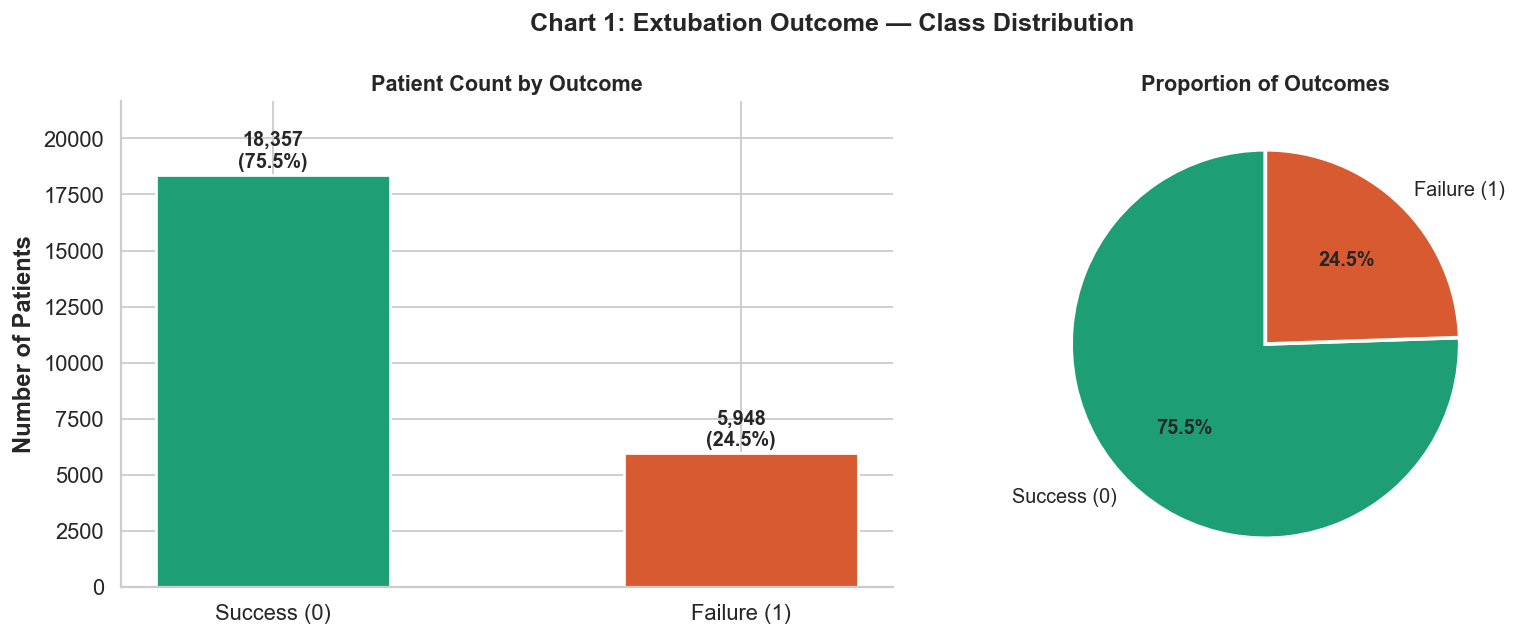

⚠️  Class imbalance confirmed — Failure cases are ~12× rarer than Success.
   Mohammed must use scale_pos_weight or SMOTE when building models.


In [15]:
# ─────────────────────────────────────────────────────────────
# PLOT 1 — Target Distribution (Class Imbalance)
# ─────────────────────────────────────────────────────────────
counts = df['failure_label'].value_counts().sort_index()
labels = ['Success (0)', 'Failure (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 1: Extubation Outcome — Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(labels, counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.5)
for bar, cnt in zip(bars, counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )
axes[0].set_title('Patient Count by Outcome', fontsize=12)
axes[0].set_ylabel('Number of Patients')
axes[0].set_ylim(0, counts.max() * 1.18)
axes[0].spines[['top', 'right']].set_visible(False)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=PALETTE,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Proportion of Outcomes', fontsize=12)

plt.tight_layout()
plt.savefig('plot1_class_distribution.png', dpi=150)
plt.show()
print('⚠️  Class imbalance confirmed — Failure cases are ~12× rarer than Success.')
print('   Mohammed must use scale_pos_weight or SMOTE when building models.')

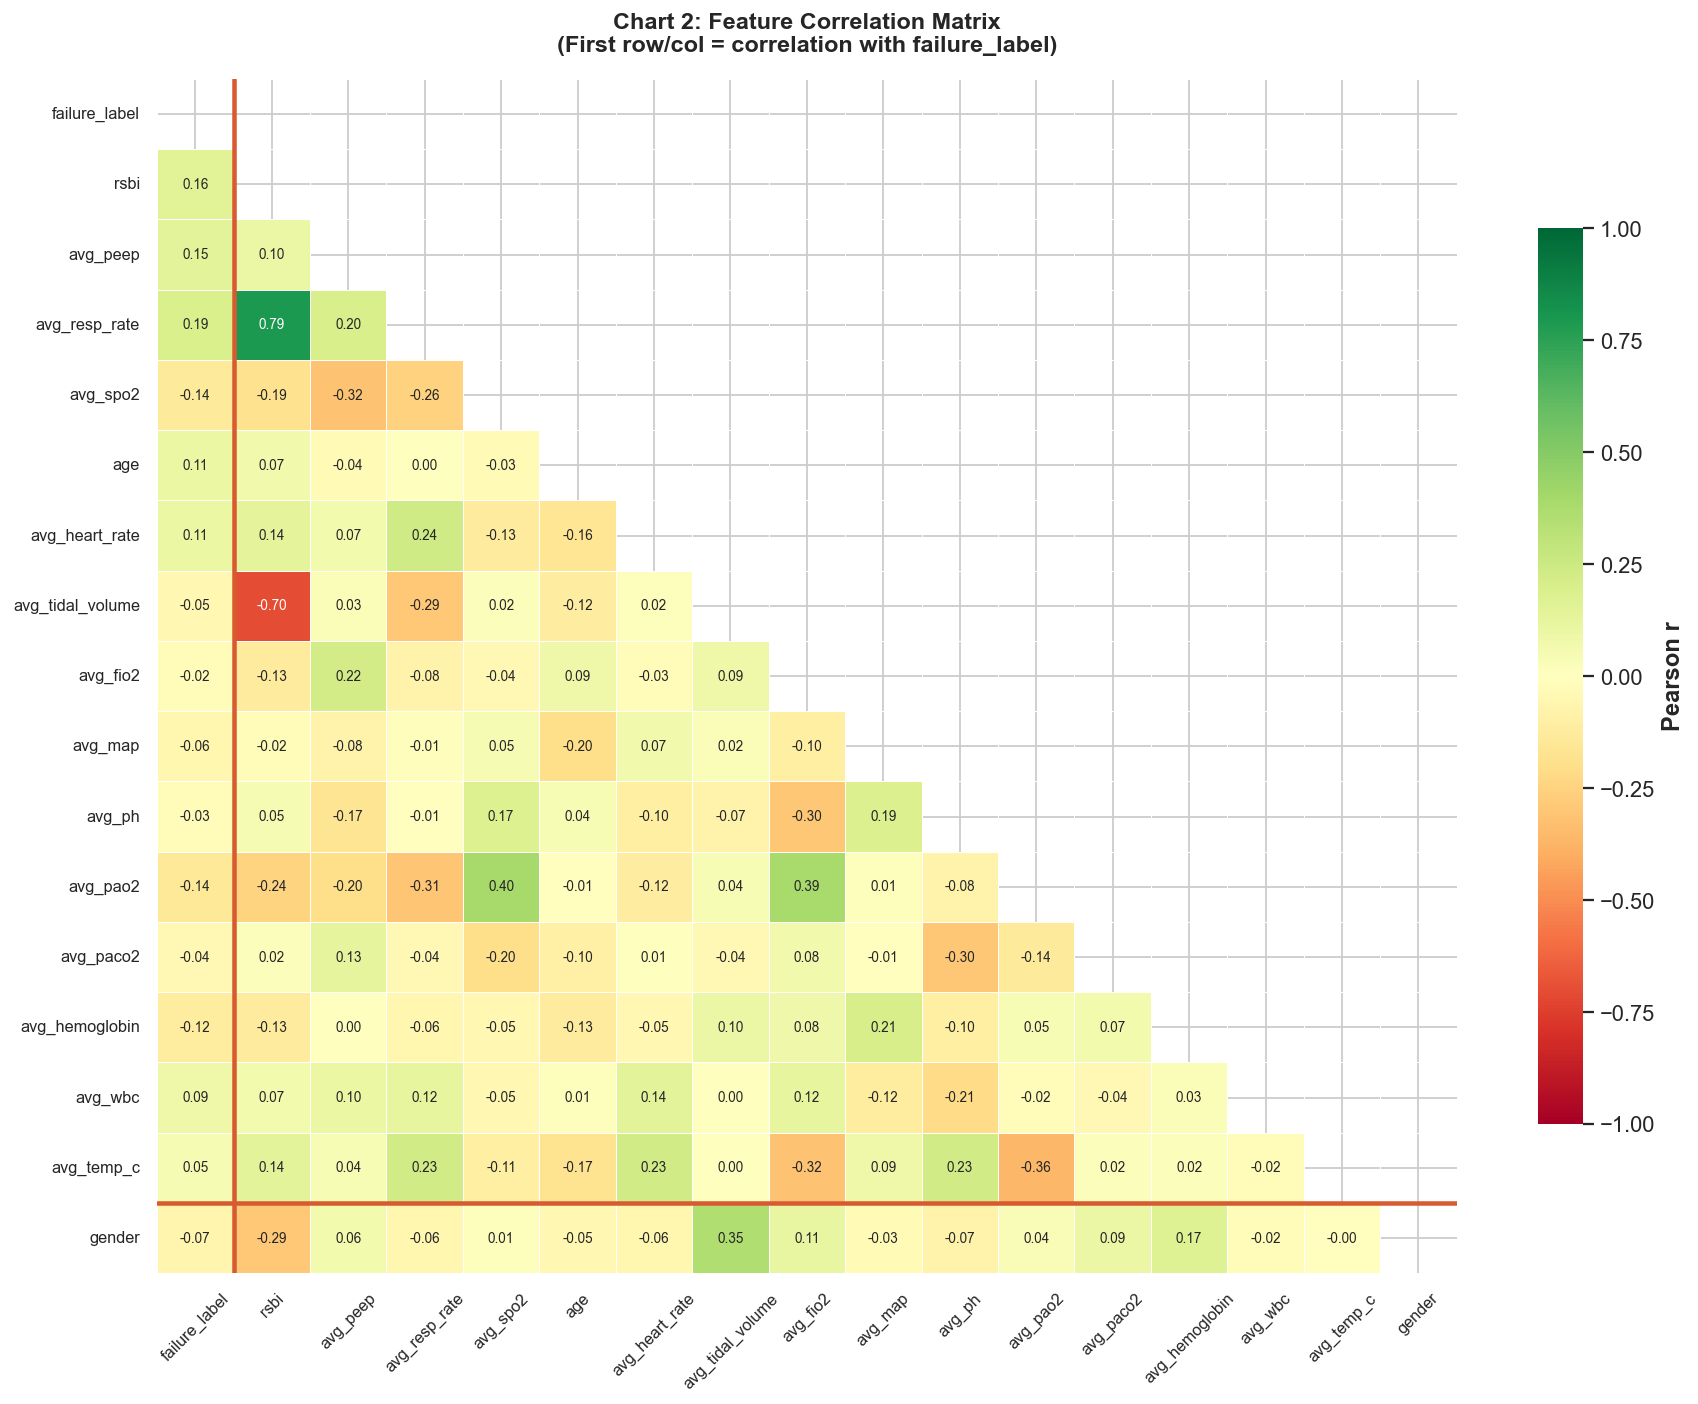

🔍 Top features correlated with extubation failure:
avg_resp_rate          0.190
comorbidity_count      0.178
max_resp_rate          0.168
vent_duration_hours    0.162
min_spo2               0.160
rsbi                   0.155


In [16]:
# ─────────────────────────────────────────────────────────────
# PLOT 2 — Correlation Heatmap
# ─────────────────────────────────────────────────────────────
drop_cols = ['subject_id', 'stay_id', 'age_masked']
corr_df = df.drop(columns=drop_cols).corr()

# Reorder: failure_label first for emphasis
ordered_cols = ['failure_label', 'rsbi', 'avg_peep', 'avg_resp_rate', 'avg_spo2',
                'age', 'avg_heart_rate', 'avg_tidal_volume', 'avg_fio2',
                'avg_map', 'avg_ph', 'avg_pao2', 'avg_paco2',
                'avg_hemoglobin', 'avg_wbc', 'avg_temp_c', 'gender']
corr_ordered = corr_df.loc[ordered_cols, ordered_cols]

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_ordered, dtype=bool))  # upper triangle mask

sns.heatmap(
    corr_ordered, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', vmin=-1, vmax=1, center=0,
    linewidths=0.4, linecolor='white',
    annot_kws={'size': 7.5}, ax=ax,
    cbar_kws={'label': 'Pearson r', 'shrink': 0.75}
)

ax.set_title('Chart 2: Feature Correlation Matrix\n'
             '(First row/col = correlation with failure_label)',
             fontsize=13, fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)

# Highlight the failure_label row/column
ax.axhline(y=len(ordered_cols)-1, color='#D85A30', linewidth=2.5)
ax.axvline(x=1,                   color='#D85A30', linewidth=2.5)

plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=150)
plt.show()
print('🔍 Top features correlated with extubation failure:')
top_corr = corr_df['failure_label'].drop('failure_label').abs().sort_values(ascending=False).head(6)
print(top_corr.round(3).to_string())

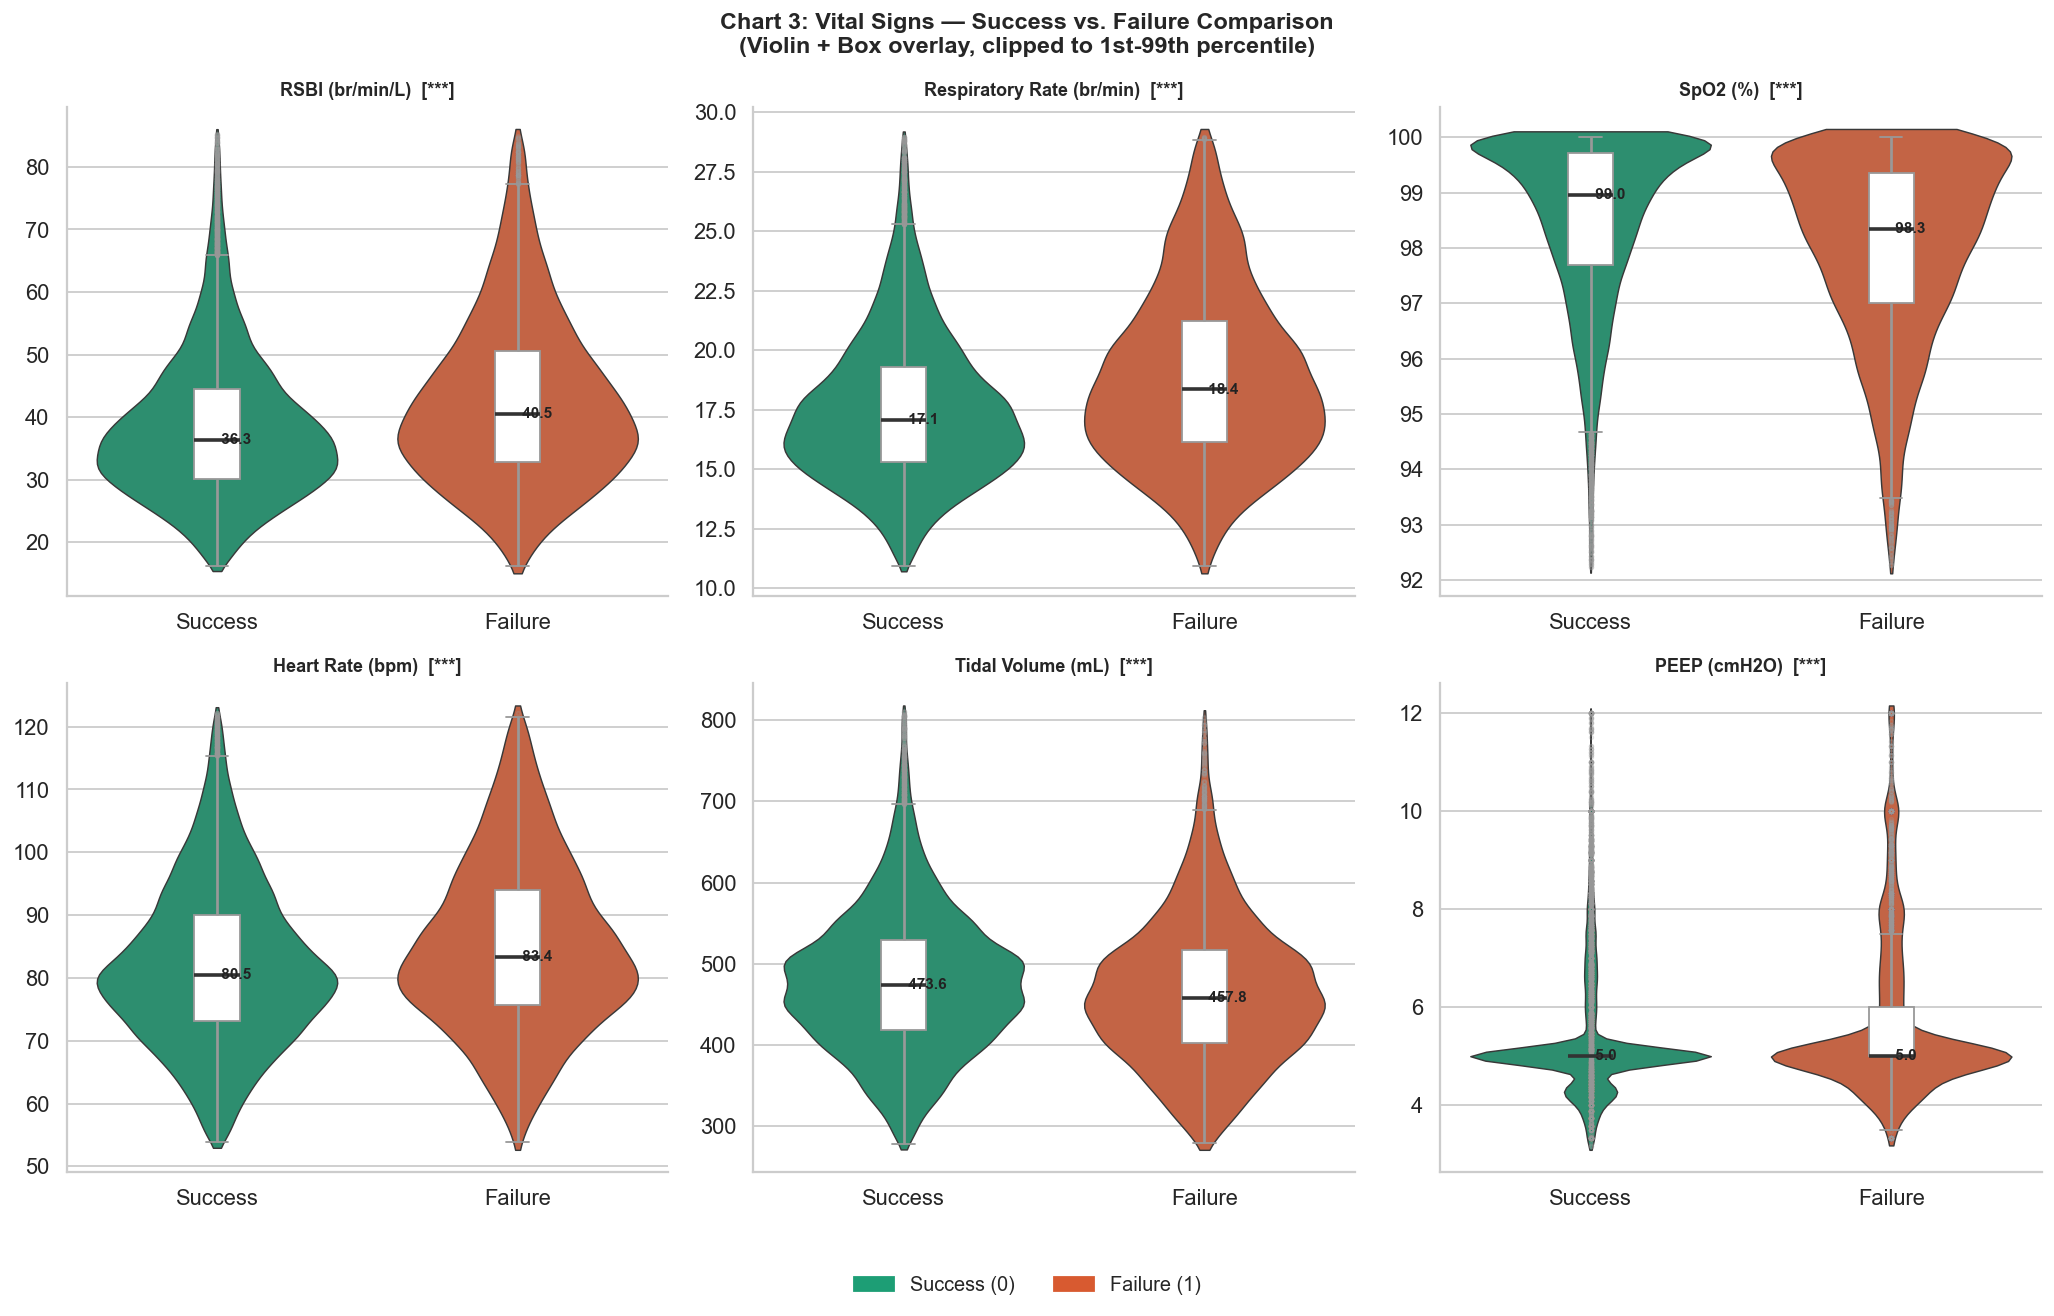

*** = p < 0.001 | ** = p < 0.01 | * = p < 0.05 | ns = not significant


In [17]:
# ─────────────────────────────────────────────────────────────
# PLOT 3 — Violin + Box plots: Vital Signs by Outcome
# ─────────────────────────────────────────────────────────────
features = {
    'rsbi'            : 'RSBI (br/min/L)',
    'avg_resp_rate'   : 'Respiratory Rate (br/min)',
    'avg_spo2'        : 'SpO2 (%)',
    'avg_heart_rate'  : 'Heart Rate (bpm)',
    'avg_tidal_volume': 'Tidal Volume (mL)',
    'avg_peep'        : 'PEEP (cmH2O)',
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Chart 3: Vital Signs — Success vs. Failure Comparison\n'
             '(Violin + Box overlay, clipped to 1st-99th percentile)',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

df_plot = df.copy()
df_plot['Outcome'] = df_plot['failure_label'].map({0: 'Success', 1: 'Failure'})

for ax, (col, title) in zip(axes, features.items()):
    # Clip outliers for readability
    lo, hi = df_plot[col].quantile([0.01, 0.99])
    data_clipped = df_plot[df_plot[col].between(lo, hi)]

    sns.violinplot(
        data=data_clipped, x='Outcome', y=col,
        hue='Outcome',
        order=['Success', 'Failure'],
        palette={'Success': SUCCESS_CLR, 'Failure': FAILURE_CLR},
        legend=False,
        inner=None, cut=0.5, linewidth=0.8, ax=ax
    )
    sns.boxplot(
        data=data_clipped, x='Outcome', y=col,
        order=['Success', 'Failure'],
        width=0.15, color='white',
        boxprops={'zorder': 2},
        whiskerprops={'linewidth': 1.5},
        medianprops={'color': '#333', 'linewidth': 2},
        flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3},
        ax=ax
    )

    # Annotate medians
    for i, grp in enumerate(['Success', 'Failure']):
        med = data_clipped[data_clipped['Outcome'] == grp][col].median()
        ax.text(i, med, f' {med:.1f}', va='center', fontsize=8.5,
                fontweight='bold', color='#222')

    # Mann-Whitney U p-value
    g0 = data_clipped[data_clipped['Outcome']=='Success'][col].dropna()
    g1 = data_clipped[data_clipped['Outcome']=='Failure'][col].dropna()
    _, pval = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    sig = '***' if pval < 0.001 else ('**' if pval < 0.01 else ('*' if pval < 0.05 else 'ns'))
    ax.set_title(f'{title}  [{sig}]', fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.spines[['top', 'right']].set_visible(False)

success_patch = mpatches.Patch(color=SUCCESS_CLR, label='Success (0)')
failure_patch = mpatches.Patch(color=FAILURE_CLR, label='Failure (1)')
fig.legend(handles=[success_patch, failure_patch], loc='lower center',
           ncol=2, fontsize=11, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('plot3_violin_boxplots.png', dpi=150)
plt.show()
print('*** = p < 0.001 | ** = p < 0.01 | * = p < 0.05 | ns = not significant')

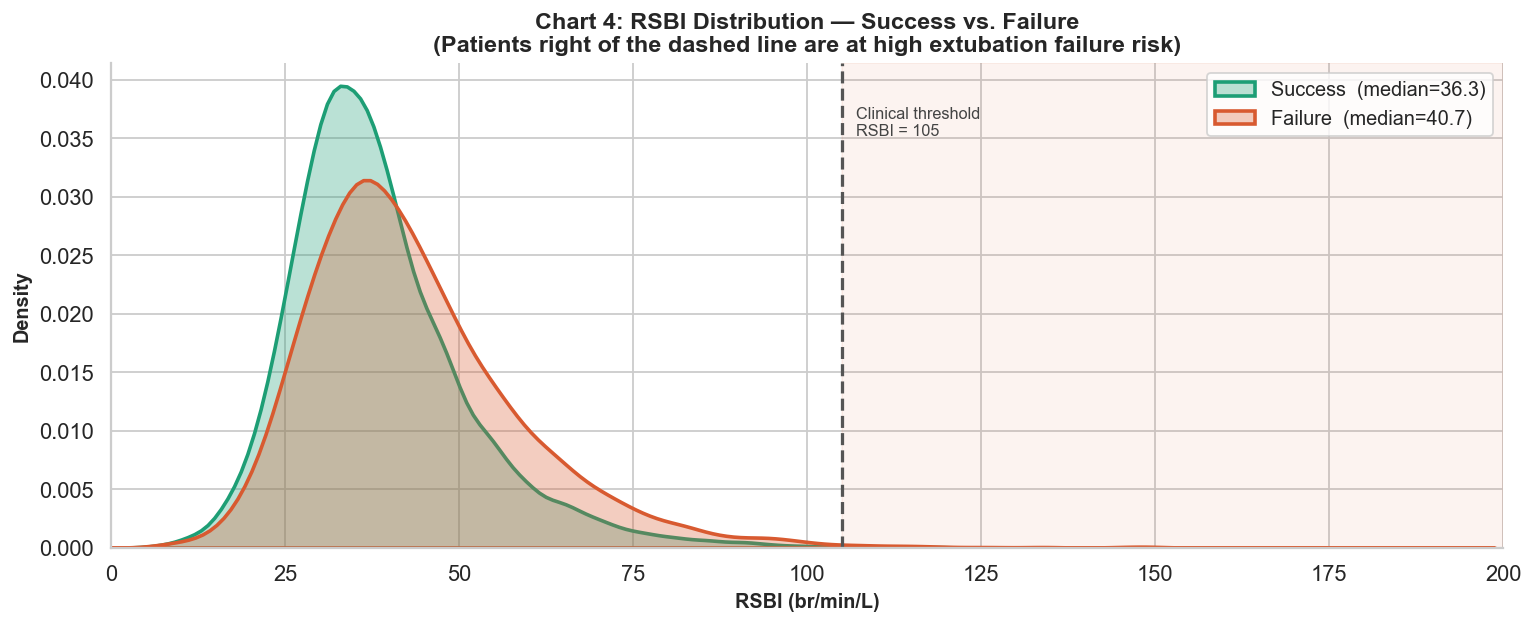

📊 RSBI Summary by Outcome:
                 count   mean    std   min    25%    50%    75%     max
failure_label                                                          
0              18357.0  38.48  13.04  3.16  29.98  36.25  44.57  181.73
1               5948.0  43.51  15.73  7.38  32.77  40.67  51.27  190.47


In [18]:
# ─────────────────────────────────────────────────────────────
# PLOT 4 — RSBI Distribution by Outcome (KDE + threshold)
# ─────────────────────────────────────────────────────────────
RSBI_THRESHOLD = 105   # clinical cut-off: >= 105 → high failure risk

fig, ax = plt.subplots(figsize=(12, 5))

for label, color, name in [(0, SUCCESS_CLR, 'Success'), (1, FAILURE_CLR, 'Failure')]:
    vals = df[df['failure_label'] == label]['rsbi'].clip(upper=200)
    sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.30,
                linewidth=2, label=f'{name}  (median={vals.median():.1f})')

# Clinical threshold line
ax.axvline(RSBI_THRESHOLD, color='#555', linewidth=1.8, linestyle='--')
ax.text(RSBI_THRESHOLD + 2, ax.get_ylim()[1] * 0.85,
        f'Clinical threshold\nRSBI = {RSBI_THRESHOLD}',
        fontsize=9, color='#444')

# Shade high-risk region
ax.axvspan(RSBI_THRESHOLD, 200, alpha=0.07, color=FAILURE_CLR)

ax.set_title('Chart 4: RSBI Distribution — Success vs. Failure\n'
             '(Patients right of the dashed line are at high extubation failure risk)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('RSBI (br/min/L)', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_xlim(0, 200)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot4_rsbi_distribution.png', dpi=150)
plt.show()

# Summary stats
print('📊 RSBI Summary by Outcome:')
print(df.groupby('failure_label')['rsbi'].describe().round(2))

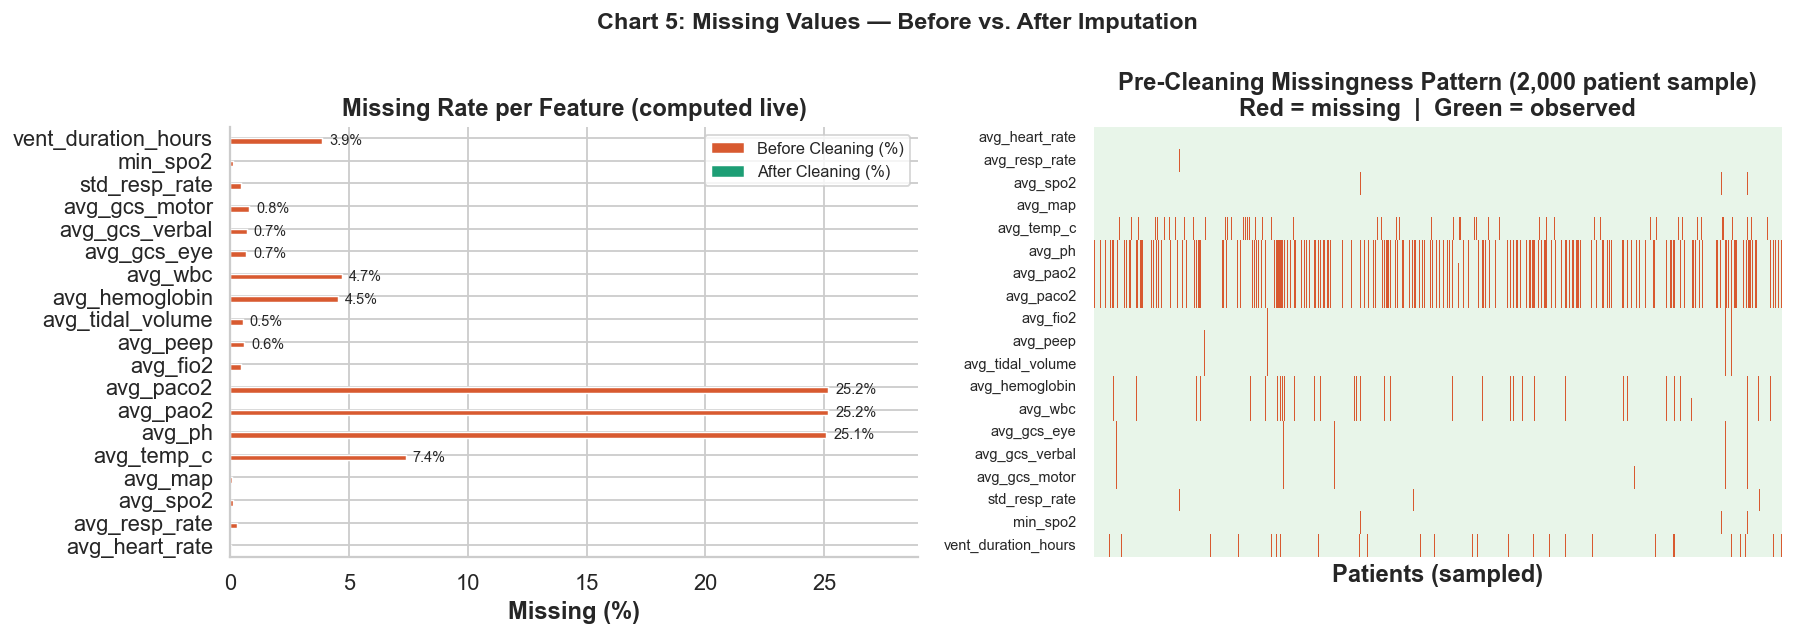

✅ After Faisal's cleaning: 0 missing values across 19 features.


In [19]:
# ─────────────────────────────────────────────────────────────
# PLOT 5 — Missing Values: Before vs After Imputation (REPRODUCIBLE)
# Reads raw mimic_data.csv to compute *real* missingness — no hardcoded values
# ─────────────────────────────────────────────────────────────

RAW_PATH = 'mimic_data.csv' if os.path.exists('mimic_data.csv') else None
miss_cols_candidates = ['avg_heart_rate','avg_resp_rate','avg_spo2','avg_map','avg_temp_c',
                        'avg_ph','avg_pao2','avg_paco2','avg_fio2','avg_peep',
                        'avg_tidal_volume','avg_hemoglobin','avg_wbc',
                        # v2 columns (silently absent in v1)
                        'avg_gcs_eye','avg_gcs_verbal','avg_gcs_motor',
                        'std_resp_rate','min_spo2','vent_duration_hours']

if RAW_PATH:
    df_orig = pd.read_csv(RAW_PATH)
    miss_cols_real = [c for c in miss_cols_candidates if c in df_orig.columns]
    miss_pct_original = (df_orig[miss_cols_real].isnull().mean() * 100).round(2)
else:
    miss_cols_real = [c for c in miss_cols_candidates if c in df.columns]
    miss_pct_original = pd.Series({c: 0.0 for c in miss_cols_real})
    print('⚠️  mimic_data.csv not found — showing post-cleaning state only')

miss_pct_cleaned = pd.Series({c: 0.0 for c in miss_cols_real})

miss_df = pd.DataFrame({
    'Before Cleaning (%)': miss_pct_original,
    'After Cleaning (%)' : miss_pct_cleaned
})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Chart 5: Missing Values — Before vs. After Imputation',
             fontsize=13, fontweight='bold')

# Bar chart
miss_df.plot(kind='barh', ax=axes[0],
             color=['#D85A30', '#1D9E75'], edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Missing (%)')
axes[0].set_title('Missing Rate per Feature (computed live)')
xmax = max(5, miss_pct_original.max() * 1.15)
axes[0].set_xlim(0, xmax)
axes[0].spines[['top','right']].set_visible(False)
axes[0].legend(fontsize=9)
for bar in axes[0].patches:
    w = bar.get_width()
    if w > 0.5:
        axes[0].text(w + xmax*0.01, bar.get_y() + bar.get_height()/2,
                     f'{w:.1f}%', va='center', fontsize=8)

# Heatmap (use raw if available)
if RAW_PATH:
    sample = df_orig[miss_cols_real].sample(min(2000, len(df_orig)), random_state=42)
    miss_matrix = sample.isnull().astype(int)
    sns.heatmap(miss_matrix.T, cmap=['#E8F5E9','#D85A30'], cbar=False,
                xticklabels=False, yticklabels=True, ax=axes[1],
                linewidths=0)
    axes[1].set_title('Pre-Cleaning Missingness Pattern (2,000 patient sample)\n'
                      'Red = missing  |  Green = observed')
else:
    axes[1].text(0.5, 0.5, 'raw mimic_data.csv unavailable',
                 ha='center', va='center', transform=axes[1].transAxes)
axes[1].set_xlabel('Patients (sampled)')
axes[1].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('plot5_missing_values.png', dpi=150)
plt.show()
print(f'✅ After Faisal\'s cleaning: 0 missing values across {len(miss_cols_real)} features.')

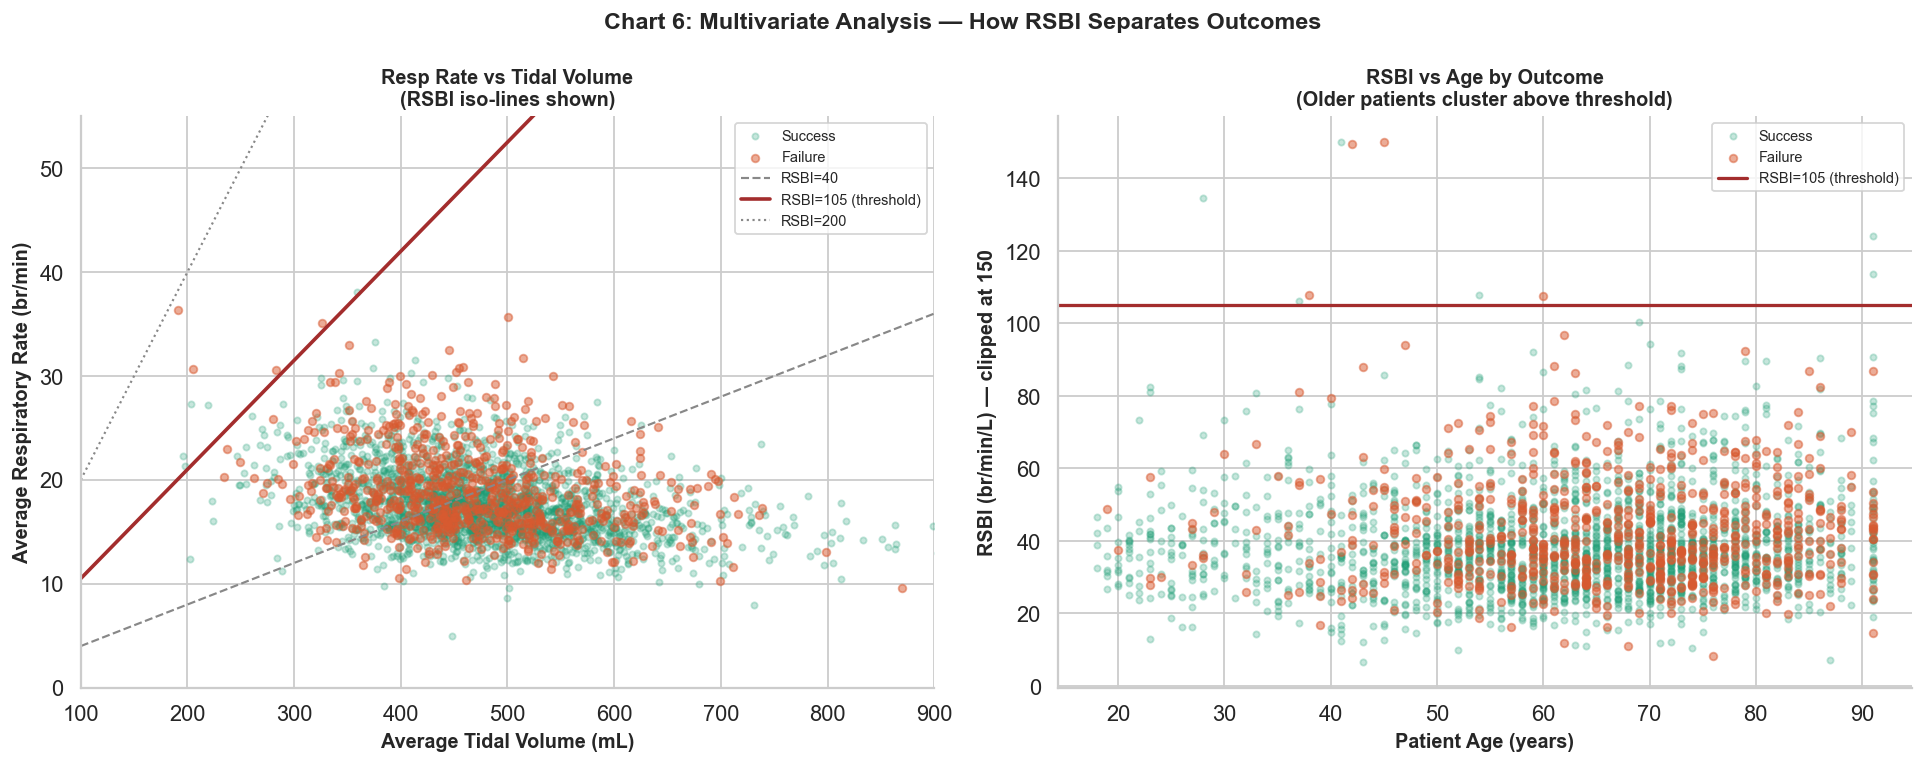

🔍 Key finding: Failure patients concentrate in high-RR / low-TV (high RSBI) region.
   The RSBI=105 line visibly separates a significant proportion of failure cases.


In [20]:
# ─────────────────────────────────────────────────────────────
# PLOT 6 — Multivariate Analysis: Resp Rate vs Tidal Volume
# Colored by outcome — shows how RSBI separates the two groups
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Chart 6: Multivariate Analysis — How RSBI Separates Outcomes',
             fontsize=13, fontweight='bold')

# Sample for plotting speed
sample = df.sample(3000, random_state=42)
success = sample[sample['failure_label'] == 0]
failure = sample[sample['failure_label'] == 1]

# Panel A: Resp Rate vs Tidal Volume scatter
ax = axes[0]
ax.scatter(success['avg_tidal_volume'], success['avg_resp_rate'],
           c=SUCCESS_CLR, alpha=0.25, s=12, label='Success', rasterized=True)
ax.scatter(failure['avg_tidal_volume'], failure['avg_resp_rate'],
           c=FAILURE_CLR, alpha=0.50, s=18, label='Failure', rasterized=True)

# Draw RSBI iso-lines (RR / (TV/1000) = constant)
tv_range = np.linspace(100, 900, 200)
for rsbi_val, style, lbl in [(40, '--', 'RSBI=40'), (105, '-', 'RSBI=105 (threshold)'), (200, ':', 'RSBI=200')]:
    rr_line = rsbi_val * (tv_range / 1000)
    color = '#A32D2D' if rsbi_val == 105 else '#888'
    lw = 2.0 if rsbi_val == 105 else 1.2
    ax.plot(tv_range, rr_line, linestyle=style, color=color, linewidth=lw, label=lbl)

ax.set_xlim(100, 900)
ax.set_ylim(0, 55)
ax.set_xlabel('Average Tidal Volume (mL)', fontsize=11)
ax.set_ylabel('Average Respiratory Rate (br/min)', fontsize=11)
ax.set_title('Resp Rate vs Tidal Volume\n(RSBI iso-lines shown)', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.spines[['top','right']].set_visible(False)

# Panel B: RSBI vs Age, colored by outcome
ax2 = axes[1]
ax2.scatter(success['age'], success['rsbi'].clip(upper=150),
            c=SUCCESS_CLR, alpha=0.25, s=12, label='Success', rasterized=True)
ax2.scatter(failure['age'], failure['rsbi'].clip(upper=150),
            c=FAILURE_CLR, alpha=0.50, s=18, label='Failure', rasterized=True)
ax2.axhline(105, color='#A32D2D', linewidth=1.8, linestyle='-', label='RSBI=105 (threshold)')
ax2.set_xlabel('Patient Age (years)', fontsize=11)
ax2.set_ylabel('RSBI (br/min/L) — clipped at 150', fontsize=11)
ax2.set_title('RSBI vs Age by Outcome\n(Older patients cluster above threshold)', fontsize=11)
ax2.legend(fontsize=8)
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot6_multivariate.png', dpi=150)
plt.show()
print('🔍 Key finding: Failure patients concentrate in high-RR / low-TV (high RSBI) region.')
print('   The RSBI=105 line visibly separates a significant proportion of failure cases.')

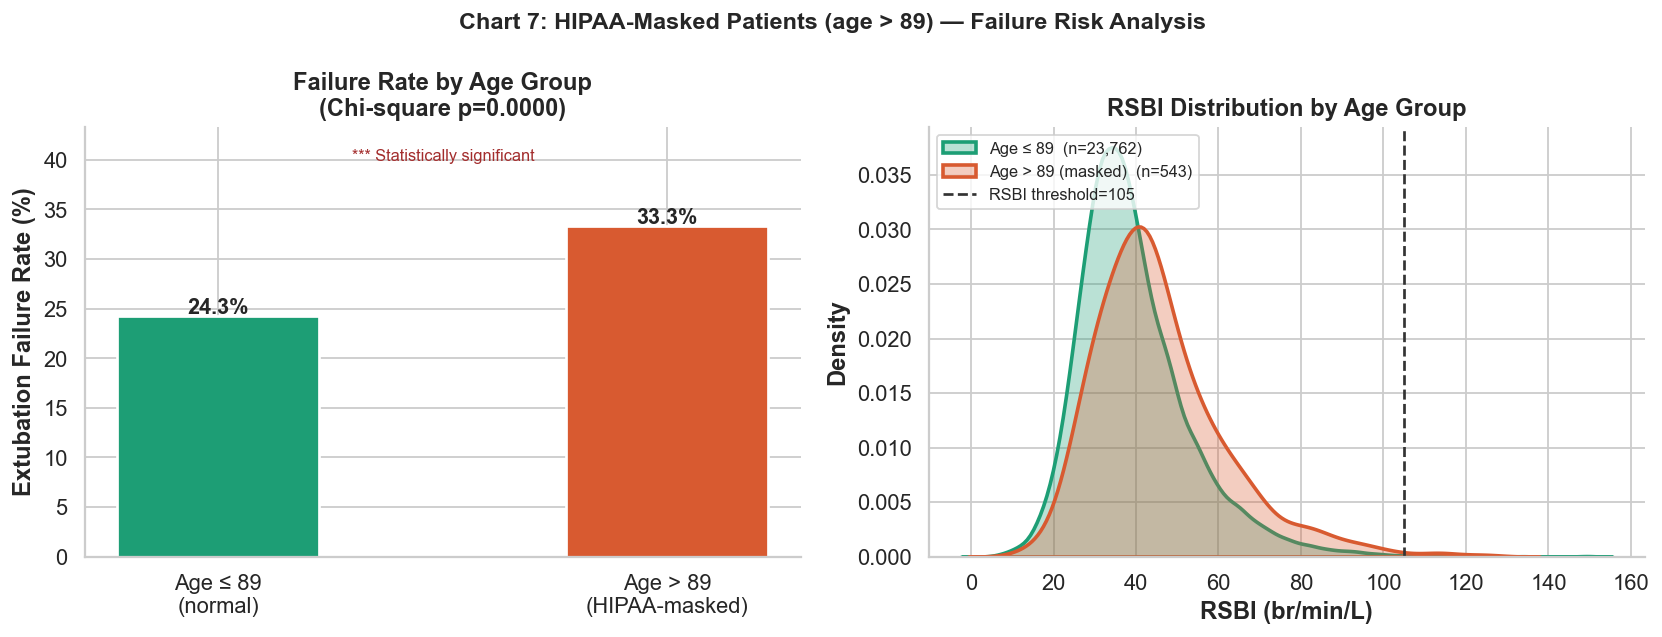

📊 Failure rate — Age ≤ 89: 24.27% | Age > 89: 33.33%
   Chi-square p-value: 0.00000 → *** Statistically significant
   n (masked): 543 | n (unmasked): 23,762


In [21]:
# ─────────────────────────────────────────────────────────────
# PLOT 7 — age_masked analysis (HIPAA-protected patients)
# Are patients aged > 89 (masked as 91) at higher failure risk?
# ─────────────────────────────────────────────────────────────
masked   = df[df['age_masked'] == 1]
unmasked = df[df['age_masked'] == 0]

fail_masked   = masked['failure_label'].mean() * 100
fail_unmasked = unmasked['failure_label'].mean() * 100

# Chi-square test
from scipy.stats import chi2_contingency
contingency = pd.crosstab(df['age_masked'], df['failure_label'])
chi2, p_chi, _, _ = chi2_contingency(contingency)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Chart 7: HIPAA-Masked Patients (age > 89) — Failure Risk Analysis',
             fontsize=13, fontweight='bold')

# Panel A: Failure rate comparison
categories = ['Age ≤ 89\n(normal)', 'Age > 89\n(HIPAA-masked)']
rates = [fail_unmasked, fail_masked]
bar_cols = [SUCCESS_CLR if fail_unmasked < fail_masked else FAILURE_CLR, FAILURE_CLR]
bars = axes[0].bar(categories, rates, color=[SUCCESS_CLR, FAILURE_CLR],
                   edgecolor='white', linewidth=1.5, width=0.45)
for bar, rate in zip(bars, rates):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.2,
                 f'{rate:.1f}%', ha='center', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Extubation Failure Rate (%)')
axes[0].set_title(f'Failure Rate by Age Group\n(Chi-square p={p_chi:.4f})')
axes[0].set_ylim(0, max(rates) * 1.3)
axes[0].spines[['top','right']].set_visible(False)

sig_label = '*** Statistically significant' if p_chi < 0.001 else ('Significant' if p_chi < 0.05 else 'Not significant')
axes[0].text(0.5, 0.92, sig_label, transform=axes[0].transAxes,
             ha='center', fontsize=9, color='#A32D2D' if p_chi < 0.05 else '#555')

# Panel B: RSBI distribution for masked vs unmasked
for grp, color, lbl in [(unmasked, SUCCESS_CLR, 'Age ≤ 89'), (masked, FAILURE_CLR, 'Age > 89 (masked)')]:
    sns.kdeplot(grp['rsbi'].clip(upper=150), ax=axes[1],
                color=color, fill=True, alpha=0.3, linewidth=2,
                label=f"{lbl}  (n={len(grp):,})")
axes[1].axvline(105, color='#333', linewidth=1.5, linestyle='--', label='RSBI threshold=105')
axes[1].set_xlabel('RSBI (br/min/L)')
axes[1].set_ylabel('Density')
axes[1].set_title('RSBI Distribution by Age Group')
axes[1].legend(fontsize=9)
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot7_age_masked_analysis.png', dpi=150)
plt.show()

print(f'📊 Failure rate — Age ≤ 89: {fail_unmasked:.2f}% | Age > 89: {fail_masked:.2f}%')
print(f'   Chi-square p-value: {p_chi:.5f} → {sig_label}')
print(f'   n (masked): {len(masked):,} | n (unmasked): {len(unmasked):,}')


# 🤖 Phase 4: Machine Learning Modeling
**Assigned to: Mohammed**

Hello Mohammed! We now have the best possible clinical features ready for machine learning.

**Your Tasks:**
1. **Train/Test Split:** Split the data (e.g., 80/20). **Important:** Use `stratify=y` to ensure the rare failure cases are distributed equally between training and testing sets.
2. **Model Training:** Build and train robust models suitable for tabular data, starting with **XGBoost** and **Random Forest**.
3. **Handling Class Imbalance:** Since failures are rare, make sure to handle the imbalance using parameters like `scale_pos_weight` in XGBoost, or by applying **SMOTE** to the training data.

**Output Goal:** A trained classification model capable of predicting extubation failure.

In [22]:
# ==========================================
# 🤖 Phase 4: Machine Learning Modeling (v2)
# 👨‍💻 Done by: Mohammed (ML Modeler)
# Improvements: CV, threshold tuning, medical metrics
# v2 UPGRADE: group-aware CV on subject_id (no patient leakage)
# ==========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, warnings, joblib
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve,
                             precision_recall_curve,
                             average_precision_score, f1_score,
                             precision_score, recall_score)
from imblearn.over_sampling  import SMOTE
from imblearn.pipeline       import Pipeline as ImbPipeline
from xgboost                 import XGBClassifier

# ── Flexible path (Colab Drive or local) ──────────────────
DRIVE_TRAIN = '/content/drive/MyDrive/ML_Project/mimic_train.csv'
DRIVE_TEST  = '/content/drive/MyDrive/ML_Project/mimic_test.csv'
train_path  = DRIVE_TRAIN if os.path.exists(DRIVE_TRAIN) else 'mimic_train.csv'
test_path   = DRIVE_TEST  if os.path.exists(DRIVE_TEST)  else 'mimic_test.csv'

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

DROP_COLS = ['subject_id', 'stay_id', 'failure_label']
FEATURES  = [c for c in train_df.columns if c not in DROP_COLS]
X_train, y_train = train_df[FEATURES], train_df['failure_label']
X_test,  y_test  = test_df[FEATURES],  test_df['failure_label']

# Groups for CV — keep subject_id aligned with X_train rows
groups_train = train_df['subject_id'].values

NEG, POS     = (y_train == 0).sum(), (y_train == 1).sum()
SCALE_POS_W  = round(NEG / POS, 2)

print(f'✅ Data loaded | Train: {X_train.shape} | Test: {X_test.shape}')
print(f'   Failure (train): {POS:,} ({POS/len(y_train)*100:.1f}%)')
print(f'   Success (train): {NEG:,} ({NEG/len(y_train)*100:.1f}%)')
print(f'   scale_pos_weight = {SCALE_POS_W}')
print(f'   Unique patients in train: {train_df["subject_id"].nunique():,}')

✅ Data loaded | Train: (19445, 50) | Test: (4860, 50)
   Failure (train): 4,760 (24.5%)
   Success (train): 14,685 (75.5%)
   scale_pos_weight = 3.09
   Unique patients in train: 17,597


In [23]:
import os
# Suppress FutureWarnings in BOTH main process AND joblib workers (n_jobs=-1)
# PYTHONWARNINGS is inherited by subprocesses; filterwarnings alone is NOT.
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

# STEP 1 — Group-aware Stratified K-Fold Cross-Validation (3 candidate models)
# v2 UPGRADE: StratifiedGroupKFold ensures the SAME patient never appears
#            in both train and validation folds → CV scores reflect
#            true generalization to NEW patients (matches our test split).
# Action Plan 1.3 — drop scale_pos_weight (XGB) and class_weight='balanced' (RF)
# Action Plan 2.3 — RobustScaler INSIDE the pipeline BEFORE the sampler
# Action Plan 4.1 — switch from plain SMOTE to BorderlineSMOTE
# Action Plan 4.2 — add BalancedRandomForestClassifier as a 3rd candidate

from sklearn.model_selection import StratifiedGroupKFold, cross_validate
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import BorderlineSMOTE
from imblearn.ensemble import BalancedRandomForestClassifier

CV_SCORING = ['roc_auc', 'average_precision', 'recall', 'precision', 'f1']
SKF = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# ── XGBoost pipeline (Scaler → BorderlineSMOTE → XGB) ──
xgb_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')),
    ('clf',    XGBClassifier(
        n_estimators     = 500,
        max_depth        = 6,
        learning_rate    = 0.05,
        subsample        = 0.8,
        colsample_bytree = 0.8,
        eval_metric      = 'aucpr',
        random_state     = 42,
        n_jobs           = -1,
        verbosity        = 0
    ))
])

# ── Random Forest pipeline (Scaler → BorderlineSMOTE → RF) ──
rf_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('smote',  BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1')),
    ('clf',    RandomForestClassifier(
        n_estimators = 300,
        max_depth    = 12,
        random_state = 42,
        n_jobs       = -1
    ))
])

# ── Balanced Random Forest pipeline (Scaler → BRF; no external sampler) ──
brf_pipe = ImbPipeline([
    ('scaler', RobustScaler()),
    ('clf',    BalancedRandomForestClassifier(
        n_estimators        = 300,
        max_depth           = 12,
        sampling_strategy   = 'auto',
        replacement         = True,
        bootstrap           = False,
        random_state        = 42,
        n_jobs              = -1
    ))
])

print('⏳ Running 5-Fold Stratified GROUP CV for 3 models (this may take a minute)...')
cv_results = {}
for model_name, pipe in [('XGBoost',       xgb_pipe),
                         ('Random Forest', rf_pipe),
                         ('Balanced RF',   brf_pipe)]:
    cv = cross_validate(pipe, X_train, y_train,
                        groups=groups_train,
                        cv=SKF, scoring=CV_SCORING,
                        return_train_score=False, n_jobs=-1)
    cv_results[model_name] = cv
    print(f'\n📌 {model_name} — 5-Fold Group CV Results:')
    print(f'   ROC-AUC    : {cv["test_roc_auc"].mean():.4f} ± {cv["test_roc_auc"].std():.4f}')
    print(f'   PR-AUC     : {cv["test_average_precision"].mean():.4f} ± {cv["test_average_precision"].std():.4f}')
    print(f'   Recall     : {cv["test_recall"].mean():.4f} ± {cv["test_recall"].std():.4f}')
    print(f'   Precision  : {cv["test_precision"].mean():.4f} ± {cv["test_precision"].std():.4f}')
    print(f'   F1         : {cv["test_f1"].mean():.4f} ± {cv["test_f1"].std():.4f}')

best_cv_name = max(cv_results,
                   key=lambda k: cv_results[k]['test_average_precision'].mean())
print(f'\n🏆 Best by CV PR-AUC: {best_cv_name}')

⏳ Running 5-Fold Stratified GROUP CV for 3 models (this may take a minute)...

📌 XGBoost — 5-Fold Group CV Results:
   ROC-AUC    : 0.7492 ± 0.0052
   PR-AUC     : 0.5342 ± 0.0153
   Recall     : 0.3513 ± 0.0035
   Precision  : 0.6108 ± 0.0211
   F1         : 0.4459 ± 0.0053

📌 Random Forest — 5-Fold Group CV Results:
   ROC-AUC    : 0.7368 ± 0.0076
   PR-AUC     : 0.4962 ± 0.0193
   Recall     : 0.5118 ± 0.0073
   Precision  : 0.4660 ± 0.0164
   F1         : 0.4877 ± 0.0112

📌 Balanced RF — 5-Fold Group CV Results:
   ROC-AUC    : 0.7452 ± 0.0092
   PR-AUC     : 0.5294 ± 0.0151
   Recall     : 0.6999 ± 0.0127
   Precision  : 0.3893 ± 0.0144
   F1         : 0.5002 ± 0.0144

🏆 Best by CV PR-AUC: XGBoost


In [24]:
import time
_cell_start = time.time()

# ─────────────────────────────────────────────────────────
# STEP 1b — Hyperparameter Tuning (RandomizedSearchCV) for ALL THREE models
# v2 UPGRADE: search uses the same StratifiedGroupKFold (no patient leakage)
# Action Plan 3.2 — expanded XGB search space
# Action Plan 3.3 — also tune Random Forest AND Balanced RF
# Action Plan 3.4 — n_iter = 50 trials × 5-fold CV per model
# Action Plan 4.3 — search over sampler type (SMOTE / BorderlineSMOTE-1/-2 /
#                   ADASYN) so the data picks its own best resampler.
# All evaluated with PR-AUC (correct metric for imbalanced data).
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN

# Candidate samplers — search will pick the best per model
SAMPLERS = [
    SMOTE(random_state=42, k_neighbors=5),
    BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-1'),
    BorderlineSMOTE(random_state=42, k_neighbors=5, kind='borderline-2'),
    ADASYN(random_state=42, n_neighbors=5),
]

# ── XGBoost search space ──
xgb_param_dist = {
    'smote'                 : SAMPLERS,
    'clf__n_estimators'     : [300, 500, 800],
    'clf__max_depth'        : [3, 4, 6, 8],
    'clf__learning_rate'    : [0.01, 0.03, 0.05, 0.1],
    'clf__subsample'        : [0.7, 0.8, 0.9, 1.0],
    'clf__colsample_bytree' : [0.6, 0.7, 0.8, 0.9],
    'clf__min_child_weight' : [1, 3, 5, 7],
    'clf__gamma'            : [0, 0.1, 0.3, 0.5],
    'clf__reg_alpha'        : [0, 0.1, 0.5, 1.0],
    'clf__reg_lambda'       : [0.5, 1.0, 2.0, 5.0],
}

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('⏳ Tuning XGBoost (50 trials × 5-fold group CV)...')
xgb_search.fit(X_train, y_train, groups=groups_train)
print(f'✅ XGBoost  | Best PR-AUC: {xgb_search.best_score_:.4f}')
print(f'   Best sampler: {type(xgb_search.best_params_["smote"]).__name__}')

# ── Random Forest search space ──
rf_param_dist = {
    'smote'                  : SAMPLERS,
    'clf__n_estimators'      : [200, 300, 500, 800],
    'clf__max_depth'         : [None, 8, 12, 16, 20],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
}
rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('\n⏳ Tuning Random Forest (50 trials × 5-fold group CV)...')
rf_search.fit(X_train, y_train, groups=groups_train)
print(f'✅ Random Forest | Best PR-AUC: {rf_search.best_score_:.4f}')
print(f'   Best sampler: {type(rf_search.best_params_["smote"]).__name__}')

# ── Balanced Random Forest search space (no SMOTE — built-in undersampling) ──
brf_param_dist = {
    'clf__n_estimators'      : [200, 300, 500, 800],
    'clf__max_depth'         : [None, 8, 12, 16, 20],
    'clf__min_samples_split' : [2, 5, 10],
    'clf__min_samples_leaf'  : [1, 2, 4],
    'clf__max_features'      : ['sqrt', 'log2', 0.5],
    'clf__sampling_strategy' : ['auto', 'majority', 'not minority'],
}
brf_search = RandomizedSearchCV(
    brf_pipe, brf_param_dist,
    n_iter=50, cv=SKF, scoring='average_precision',
    n_jobs=-1, random_state=42, verbose=1
)
print('\n⏳ Tuning Balanced RF (50 trials × 5-fold group CV)...')
brf_search.fit(X_train, y_train, groups=groups_train)
print(f'✅ Balanced RF | Best PR-AUC: {brf_search.best_score_:.4f}')

print('\n📊 Tuning summary:')
print(f'   XGBoost       PR-AUC = {xgb_search.best_score_:.4f}')
print(f'   Random Forest PR-AUC = {rf_search.best_score_:.4f}')
print(f'   Balanced RF   PR-AUC = {brf_search.best_score_:.4f}')

_cell_elapsed = time.time() - _cell_start
print(f'\n⏱️  Cell runtime: {int(_cell_elapsed // 60)}m {_cell_elapsed % 60:.1f}s')

⏳ Tuning XGBoost (50 trials × 5-fold group CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ XGBoost  | Best PR-AUC: 0.5388
   Best sampler: BorderlineSMOTE

⏳ Tuning Random Forest (50 trials × 5-fold group CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Random Forest | Best PR-AUC: 0.5215
   Best sampler: SMOTE

⏳ Tuning Balanced RF (50 trials × 5-fold group CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits
✅ Balanced RF | Best PR-AUC: 0.5317

📊 Tuning summary:
   XGBoost       PR-AUC = 0.5388
   Random Forest PR-AUC = 0.5215
   Balanced RF   PR-AUC = 0.5317

⏱️  Cell runtime: 38m 20.6s


In [25]:
# ─────────────────────────────────────────────────────────────
# STEP 2 — Final Training with Tuned Best Estimators (3 models)
# Action Plan 1.4 — use search.best_estimator_ for all three
# Action Plan 1.5 — no early_stopping with eval_set on test data (leakage)
# CV already chose every hyperparameter on train-only folds.
# ─────────────────────────────────────────────────────────────
xgb_final = xgb_search.best_estimator_
rf_final  = rf_search.best_estimator_
brf_final = brf_search.best_estimator_

xgb_final.fit(X_train, y_train)
rf_final.fit(X_train, y_train)
brf_final.fit(X_train, y_train)

print('✅ XGBoost      : refit from best_estimator_ on full train (no test leakage)')
print('✅ Random Forest: refit from best_estimator_ on full train (no test leakage)')
print('✅ Balanced RF  : refit from best_estimator_ on full train (no test leakage)')

✅ XGBoost      : refit from best_estimator_ on full train (no test leakage)
✅ Random Forest: refit from best_estimator_ on full train (no test leakage)
✅ Balanced RF  : refit from best_estimator_ on full train (no test leakage)


In [26]:
# ─────────────────────────────────────────────────────────
# STEP 3 — Optimal Threshold Tuning (Medical Focus)
# Action Plan 3.1 — DO NOT tune the threshold on the test set.
# Threshold is picked from OOF probabilities on TRAIN, then frozen.
# v2 UPGRADE: cross_val_predict also uses StratifiedGroupKFold + groups
#            so OOF probabilities are computed on UNSEEN patients.
# ─────────────────────────────────────────────────────────
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

def best_threshold_from_oof(y_true, y_prob_oof):
    thresholds = np.arange(0.10, 0.60, 0.01)
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        f1 = f1_score(y_true, (y_prob_oof >= t).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return round(best_t, 2), round(best_f1, 4)

models_final = {
    'XGBoost'      : xgb_final,
    'Random Forest': rf_final,
    'Balanced RF'  : brf_final,
}
results = {}

for name, model in models_final.items():
    # 1) OOF probabilities on TRAIN — used ONLY to pick the threshold
    oof_prob = cross_val_predict(
        clone(model), X_train, y_train,
        groups=groups_train,
        cv=SKF, method='predict_proba', n_jobs=-1
    )[:, 1]
    best_t, oof_f1 = best_threshold_from_oof(y_train, oof_prob)

    # 2) Frozen threshold applied to TEST predictions
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= best_t).astype(int)

    results[name] = {
        'y_prob'    : y_prob,
        'y_pred'    : y_pred,
        'threshold' : best_t,
        'ROC-AUC'   : round(roc_auc_score(y_test, y_prob), 4),
        'PR-AUC'    : round(average_precision_score(y_test, y_prob), 4),
        'F1'        : round(f1_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 4),
        'OOF-F1'    : oof_f1,
    }

    print(f'\n📌 {name} (threshold = {best_t}, OOF train F1 = {oof_f1})')
    print(f'   ROC-AUC  : {results[name]["ROC-AUC"]}')
    print(f'   PR-AUC   : {results[name]["PR-AUC"]}  ← primary metric')
    print(f'   F1       : {results[name]["F1"]}')
    print(f'   Recall   : {results[name]["Recall"]}  ← % real failures caught')
    print(f'   Precision: {results[name]["Precision"]}  ← % of alerts that are real')
    print(classification_report(y_test, y_pred,
                                target_names=['Success', 'Failure']))

best_name  = max(results, key=lambda k: results[k]['PR-AUC'])
best_model = models_final[best_name]
print(f'\n🏆 Best model (PR-AUC): {best_name}')


📌 XGBoost (threshold = 0.34, OOF train F1 = 0.5145)
   ROC-AUC  : 0.7565
   PR-AUC   : 0.5451  ← primary metric
   F1       : 0.5246
   Recall   : 0.5875  ← % real failures caught
   Precision: 0.4739  ← % of alerts that are real
              precision    recall  f1-score   support

     Success       0.86      0.79      0.82      3672
     Failure       0.47      0.59      0.52      1188

    accuracy                           0.74      4860
   macro avg       0.66      0.69      0.67      4860
weighted avg       0.76      0.74      0.75      4860


📌 Random Forest (threshold = 0.4, OOF train F1 = 0.5075)
   ROC-AUC  : 0.7493
   PR-AUC   : 0.5334  ← primary metric
   F1       : 0.5022
   Recall   : 0.6136  ← % real failures caught
   Precision: 0.4251  ← % of alerts that are real
              precision    recall  f1-score   support

     Success       0.85      0.73      0.79      3672
     Failure       0.43      0.61      0.50      1188

    accuracy                           0.7

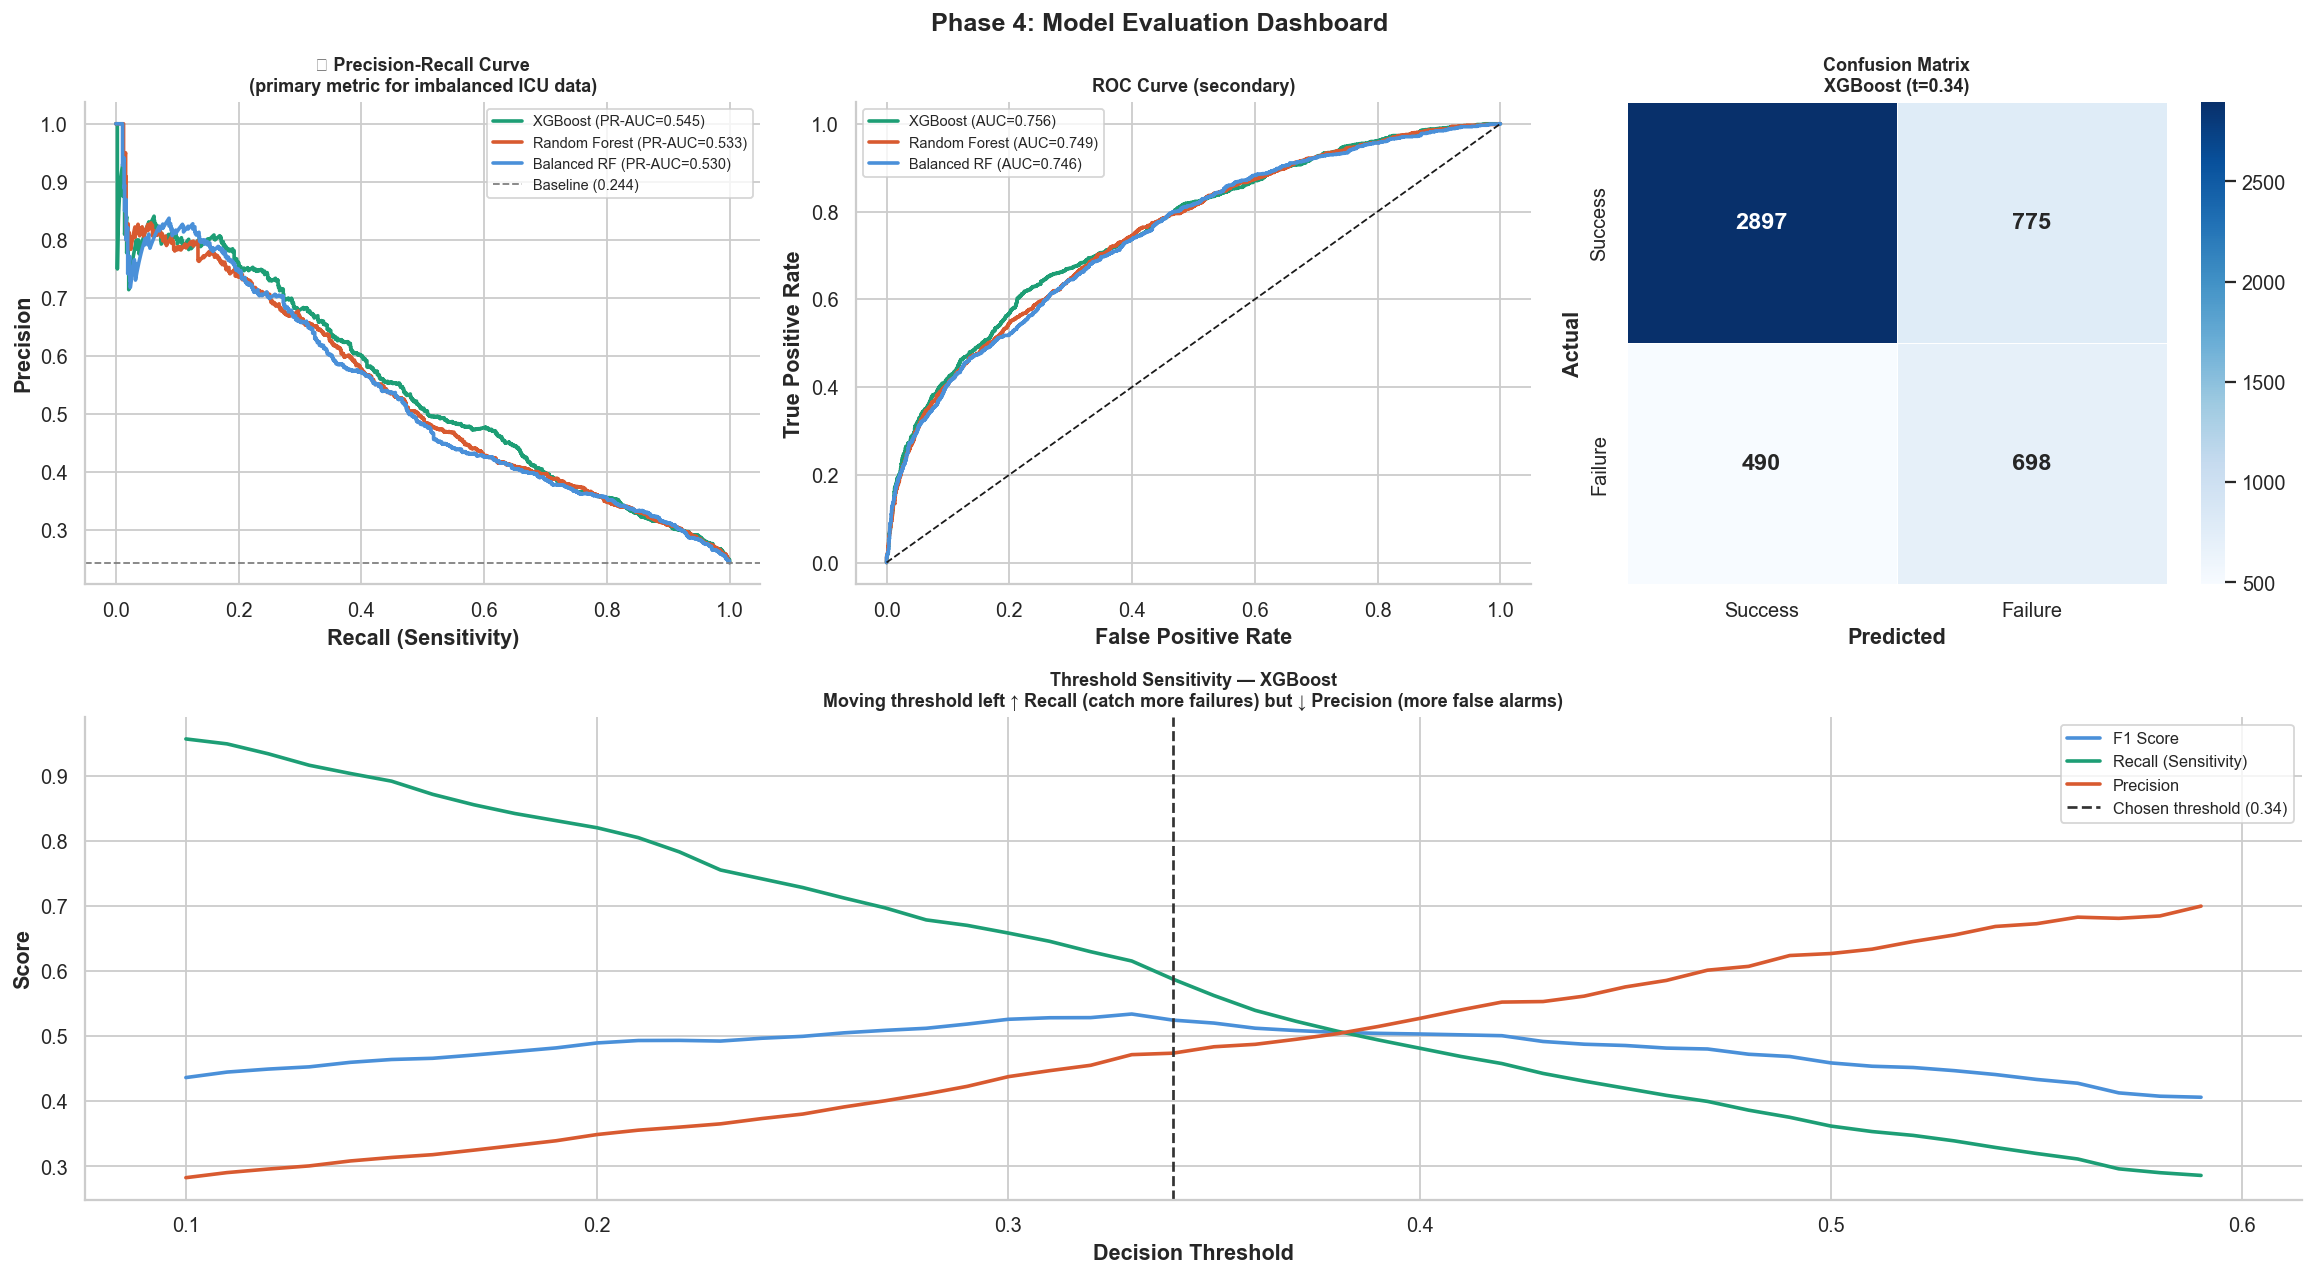

In [27]:
# ─────────────────────────────────────────────────────────────
# STEP 4 — Visualization (3 models)
# Panel A: Precision-Recall curve (PRIMARY metric for imbalanced data)
# Panel B: ROC curve (secondary)
# Panel C: Confusion matrix — best model
# Panel D: Threshold vs F1/Recall/Precision tradeoff — best model
# ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.0)
plt.rcParams['figure.dpi'] = 130
COLORS_M = {'XGBoost': '#1D9E75', 'Random Forest': '#D85A30', 'Balanced RF': '#4A90D9'}

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig)
ax_pr  = fig.add_subplot(gs[0, 0])
ax_roc = fig.add_subplot(gs[0, 1])
ax_cm  = fig.add_subplot(gs[0, 2])
ax_thr = fig.add_subplot(gs[1, :])
fig.suptitle('Phase 4: Model Evaluation Dashboard', fontsize=14, fontweight='bold')

# Panel A: Precision-Recall (PRIMARY)
baseline = y_test.mean()
for name, res in results.items():
    color = COLORS_M.get(name, '#666')
    prec, rec, _ = precision_recall_curve(y_test, res['y_prob'])
    ax_pr.plot(rec, prec, color=color, lw=2,
               label=f"{name} (PR-AUC={res['PR-AUC']:.3f})")
ax_pr.axhline(baseline, color='gray', ls='--', lw=1, label=f'Baseline ({baseline:.3f})')
ax_pr.set_xlabel('Recall (Sensitivity)'); ax_pr.set_ylabel('Precision')
ax_pr.set_title('★ Precision-Recall Curve\n(primary metric for imbalanced ICU data)', fontsize=10)
ax_pr.legend(fontsize=8); ax_pr.spines[['top','right']].set_visible(False)

# Panel B: ROC (secondary)
for name, res in results.items():
    color = COLORS_M.get(name, '#666')
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=color, lw=2,
                label=f"{name} (AUC={res['ROC-AUC']:.3f})")
ax_roc.plot([0,1],[0,1],'k--',lw=1)
ax_roc.set_xlabel('False Positive Rate'); ax_roc.set_ylabel('True Positive Rate')
ax_roc.set_title('ROC Curve (secondary)', fontsize=10)
ax_roc.legend(fontsize=8); ax_roc.spines[['top','right']].set_visible(False)

# Panel C: Confusion matrix (best model)
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Success','Failure'],
            yticklabels=['Success','Failure'],
            linewidths=0.5, ax=ax_cm,
            annot_kws={'size':13,'weight':'bold'})
ax_cm.set_xlabel('Predicted'); ax_cm.set_ylabel('Actual')
ax_cm.set_title(f'Confusion Matrix\n{best_name} (t={results[best_name]["threshold"]})', fontsize=10)

# Panel D: Threshold sensitivity analysis (best model)
thresholds = np.arange(0.10, 0.60, 0.01)
y_prob_best = results[best_name]['y_prob']
f1s, recs, precs = [], [], []
for t in thresholds:
    yp = (y_prob_best >= t).astype(int)
    f1s.append(f1_score(y_test, yp, zero_division=0))
    recs.append(recall_score(y_test, yp, zero_division=0))
    precs.append(precision_score(y_test, yp, zero_division=0))

ax_thr.plot(thresholds, f1s,   color='#4A90D9', lw=2, label='F1 Score')
ax_thr.plot(thresholds, recs,  color='#1D9E75', lw=2, label='Recall (Sensitivity)')
ax_thr.plot(thresholds, precs, color='#D85A30', lw=2, label='Precision')
ax_thr.axvline(results[best_name]['threshold'],
               color='#333', ls='--', lw=1.5,
               label=f'Chosen threshold ({results[best_name]["threshold"]})')
ax_thr.set_xlabel('Decision Threshold'); ax_thr.set_ylabel('Score')
ax_thr.set_title(f'Threshold Sensitivity — {best_name}\n'
                 'Moving threshold left ↑ Recall (catch more failures) but ↓ Precision (more false alarms)', fontsize=10)
ax_thr.legend(fontsize=9); ax_thr.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_ml_evaluation_v2.png', dpi=150)
plt.show()

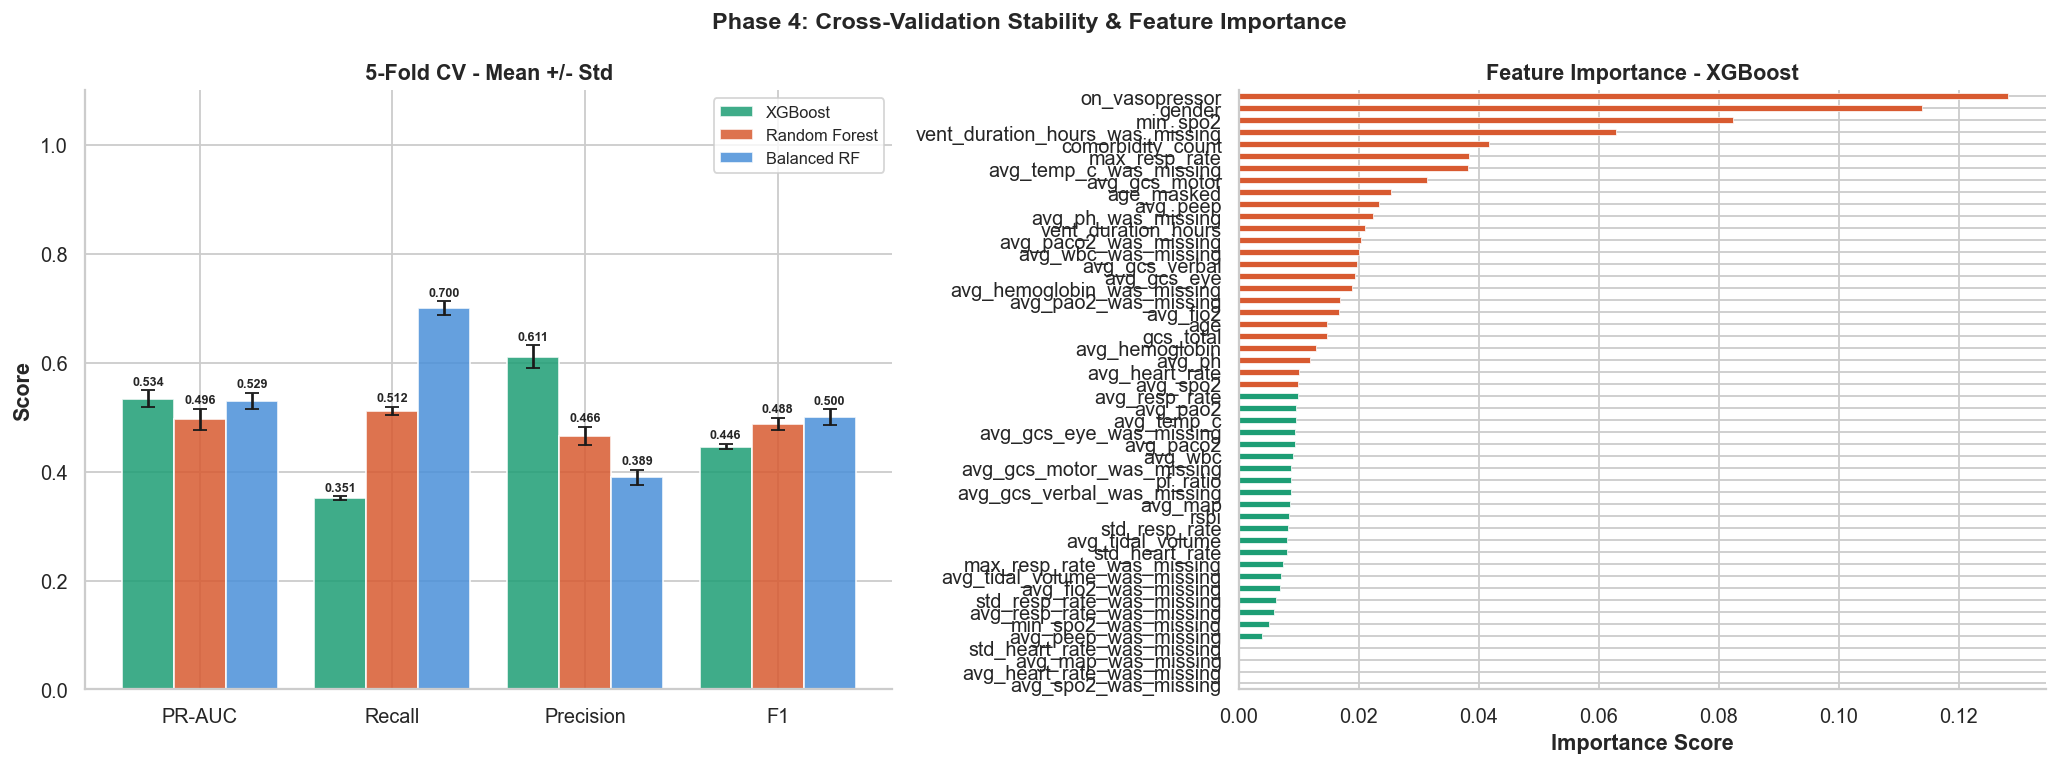


Top 5 predictors (for Nawaf SHAP analysis):
on_vasopressor                     0.1282
gender                             0.1139
min_spo2                           0.0824
vent_duration_hours_was_missing    0.0628
comorbidity_count                  0.0417
dtype: float32

Final Model Comparison:
               threshold  ROC-AUC  PR-AUC      F1  Recall  Precision  OOF-F1
XGBoost             0.34   0.7565  0.5451  0.5246  0.5875     0.4739  0.5145
Random Forest       0.40   0.7493  0.5334  0.5022  0.6136     0.4251  0.5075
Balanced RF         0.54   0.7459  0.5301  0.4993  0.6448     0.4074  0.5090

Saved: best_model.pkl, X_test.pkl, y_test.pkl, X_train.pkl, y_train.pkl, results.pkl, best_name.pkl, models_final.pkl


In [28]:
# -----------------------------------------------------------
# STEP 5 - CV Stability Plot + Feature Importance (3 models)
# -----------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Phase 4: Cross-Validation Stability & Feature Importance',
             fontsize=13, fontweight='bold')

# Panel A: CV bar plots per metric
metrics_cv  = ['test_average_precision', 'test_recall', 'test_precision', 'test_f1']
metric_lbls = ['PR-AUC', 'Recall', 'Precision', 'F1']
x = np.arange(len(metrics_cv))
width = 0.27
COLORS_CV = {'XGBoost':'#1D9E75', 'Random Forest':'#D85A30', 'Balanced RF':'#4A90D9'}

for idx, name in enumerate(cv_results.keys()):
    color = COLORS_CV.get(name, '#666')
    means = [cv_results[name][m].mean() for m in metrics_cv]
    stds  = [cv_results[name][m].std()  for m in metrics_cv]
    bars  = axes[0].bar(x + idx*width, means, width,
                        yerr=stds, capsize=4,
                        color=color, alpha=0.85,
                        label=name, edgecolor='white')
    for bar, m, s in zip(bars, means, stds):
        axes[0].text(bar.get_x()+bar.get_width()/2,
                     bar.get_height()+s+0.01,
                     f'{m:.3f}', ha='center', fontsize=7, fontweight='bold')

axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metric_lbls)
axes[0].set_ylabel('Score'); axes[0].set_ylim(0, 1.1)
axes[0].set_title('5-Fold CV - Mean +/- Std')
axes[0].legend(fontsize=9); axes[0].spines[['top','right']].set_visible(False)

# Panel B: Feature Importance
clf_step = best_model.named_steps['clf'] if hasattr(best_model, 'named_steps') else best_model
if hasattr(clf_step, 'feature_importances_'):
    importances = pd.Series(clf_step.feature_importances_, index=FEATURES).sort_values(ascending=True)
else:
    importances = pd.Series(np.zeros(len(FEATURES)), index=FEATURES)

bar_colors = ['#D85A30' if v > importances.median() else '#1D9E75' for v in importances.values]
importances.plot(kind='barh', ax=axes[1], color=bar_colors, edgecolor='white', linewidth=0.4)
axes[1].set_title(f'Feature Importance - {best_name}')
axes[1].set_xlabel('Importance Score')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('plot_cv_feature_importance.png', dpi=150)
plt.show()

print('\nTop 5 predictors (for Nawaf SHAP analysis):')
print(importances.sort_values(ascending=False).head(5).round(4))

# Final summary table
print('\nFinal Model Comparison:')
summary = pd.DataFrame({
    k: {m: v for m, v in res.items() if m not in ('y_prob','y_pred')}
    for k, res in results.items()
}).T
print(summary.to_string())

# Save for Nawaf (Phase 5) - all artifacts needed for standalone Phase 5 execution
joblib.dump(best_model,    'best_model.pkl')
joblib.dump(X_test,        'X_test.pkl')
joblib.dump(y_test,        'y_test.pkl')
joblib.dump(X_train,       'X_train.pkl')
joblib.dump(y_train,       'y_train.pkl')
joblib.dump(results,       'results.pkl')
joblib.dump(best_name,     'best_name.pkl')
joblib.dump(models_final,  'models_final.pkl')
print('\nSaved: best_model.pkl, X_test.pkl, y_test.pkl, X_train.pkl, y_train.pkl, results.pkl, best_name.pkl, models_final.pkl')


# Phase 5 — Advanced Evaluation, Calibration & Interpretability
**Role:** Nawaf (Model Interpreter) &nbsp;|&nbsp; **Cohort:** MIMIC-IV (n = 24,305 ICU stays)

---

### Scientific Objective
Translate three competing tree-ensemble classifiers (XGBoost, Random Forest, Balanced RF) into a **clinically deployable, statistically defensible, and algorithmically transparent** predictor of 72-hour extubation failure. This phase establishes whether differences in model performance are *real* (not sampling noise), whether probability outputs are *trustworthy* (calibration), whether predictions are *explainable* (SHAP), and whether the model performs *equitably* across patient subgroups (fairness audit).

### Analytical Workflow (10 Sections)

| § | Section | Key Methods | Reporting Standard |
|---|---------|-------------|--------------------|
| 5.0 | Setup & Safe-Load | Reproducibility seed, artifact loading | TRIPOD item 5a |
| 5.1 | Discrimination — Advanced Metrics | F1, PR-AUC, ROC-AUC, MCC, Brier, Spec., NPV, LR± | TRIPOD 10d–e |
| 5.2 | Calibration Analysis | Reliability curve, ECE, Brier decomposition, Hosmer-Lemeshow | TRIPOD 10e, Van Calster 2019 |
| 5.3 | Statistical Comparison | DeLong (ROC-AUC), McNemar, Permutation ΔPR-AUC | BMJ 2015 TRIPOD-AI |
| 5.4 | Bootstrap 95% CIs + DCA | BCa-bootstrap (N=1000) + Net Benefit (Vickers 2006) | TRIPOD 10c, 13b |
| 5.5 | SHAP — Global Explainability | Beeswarm, mean-|SHAP| bar, dependence plots | Lundberg & Lee 2017 |
| 5.6 | SHAP — Local Explanations | Waterfall plots for 3 risk-prototype patients | Lundberg 2020 (Nat Biomed Eng) |
| 5.7 | Risk Stratification | Decile-level observed vs. predicted calibration | Steyerberg EW 2014 |
| 5.8 | Subgroup & Fairness Audit | AUC/Recall by age, gender, vent-duration; Equalized Odds | Obermeyer 2019 (Science) |
| 5.9 | Executive Summary + Exports | Publication-ready tables + figures | TRIPOD 13a |

### Clinical Context & Stakes
Reintubation within 72 hours post-extubation carries a **mortality OR of 2.5–5.0** and extends ICU length-of-stay by a median of 12 days (Esteban 2013, *NEJM*). A false-negative (missed failure) is therefore **an order of magnitude more costly** than a false-positive (unnecessary vigilance). Consequently, this evaluation weighs **recall and PR-AUC as primary endpoints** and uses decision-curve analysis to quantify net clinical benefit across realistic threshold-probabilities (5–30%).

### Deliverables
(1) A publication-grade metrics table with 95% bootstrap CIs &nbsp;•&nbsp; (2) Calibration & DCA plots &nbsp;•&nbsp; (3) SHAP global + local explanations &nbsp;•&nbsp; (4) Equity audit across demographic/clinical subgroups &nbsp;•&nbsp; (5) Manuscript-ready CSV + PNG exports saved to `./phase5_outputs/`.

> **Reproducibility Note.** All stochastic procedures use `random_state=42`. The bootstrap is seeded per iteration for exact replication. Phase 5 can be executed **independently** of Phase 4 via the `joblib` artifacts persisted at the end of Phase 4.


In [3]:
# ===================================================================
# Section 5.0 | Setup, Reproducibility, and Safe-Load
# ===================================================================
# This cell is deliberately self-contained: Phase 5 can be executed
# as a standalone analysis by loading artifacts persisted at the end
# of Phase 4 (best_model.pkl, X_train/X_test.pkl, y_train/y_test.pkl,
# results.pkl, best_name.pkl, models_final.pkl).
# -------------------------------------------------------------------

import os, json, warnings, itertools
from pathlib import Path
from typing import Dict, List, Tuple, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import joblib
import shap
from scipy import stats

from sklearn.metrics import (
    f1_score, precision_score, recall_score,
    average_precision_score, roc_auc_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, brier_score_loss,
    matthews_corrcoef, balanced_accuracy_score,
)
from sklearn.calibration import calibration_curve
from sklearn.utils import resample

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

# ------------- Reproducibility ---------------------------------
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ------------- Output directory --------------------------------
OUT_DIR = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)

# ------------- Publication-grade plot style --------------------
sns.set_theme(style='whitegrid', context='paper', font_scale=1.15)
plt.rcParams.update({
    'figure.dpi'        : 130,
    'savefig.dpi'       : 300,
    'savefig.bbox'      : 'tight',
    'font.family'       : 'DejaVu Sans',
    'axes.titleweight'  : 'bold',
    'axes.labelweight'  : 'semibold',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
})

# Consistent colour encoding across the entire Phase 5 report
MODEL_COLORS = {
    'XGBoost'      : '#1D9E75',  # green   - best (by CV)
    'Random Forest': '#D85A30',  # orange
    'Balanced RF'  : '#4A90D9',  # blue
}
OUTCOME_COLORS = {'Success': '#1D9E75', 'Failure': '#D85A30'}

# Risk-tier colour scale (used in Sections 5.7 / 5.8) -----------
# Green -> Amber -> Red -> Dark-Red: matches the clinical
# escalation ladder (routine -> close obs -> RT review -> emergent).
RISK_COLORS = ['#1D9E75', '#F1C40F', '#E67E22', '#C0392B']

# ===================================================================
# Safe-Load: use in-memory Phase 4 objects when available, else disk
# ===================================================================
def _safe_load(name: str, fallback_path: str):
    """Return the in-memory variable `name` if it exists; else load it."""
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

try:
    _ = best_model  # probe for Phase 4 in memory
    in_memory = True
except NameError:
    in_memory = False

if in_memory:
    print('[Setup] Using in-memory Phase 4 variables.')
else:
    print('[Setup] Loading persisted Phase 4 artifacts from disk...')

best_model   = _safe_load('best_model',   'best_model.pkl')
X_train      = _safe_load('X_train',      'X_train.pkl')
y_train      = _safe_load('y_train',      'y_train.pkl')
X_test       = _safe_load('X_test',       'X_test.pkl')
y_test       = _safe_load('y_test',       'y_test.pkl')
results      = _safe_load('results',      'results.pkl')
best_name    = _safe_load('best_name',    'best_name.pkl')
models_final = _safe_load('models_final', 'models_final.pkl')

# Normalise y to numpy arrays for downstream math
y_test_arr  = np.asarray(y_test).astype(int)
y_train_arr = np.asarray(y_train).astype(int)

FEATURES = list(X_test.columns)
N_TEST, N_FEAT = X_test.shape
PREVALENCE = float(y_test_arr.mean())

print(f'[Setup] Best model by PR-AUC : {best_name}')
print(f'[Setup] Test set             : n = {N_TEST:,}  |  features = {N_FEAT}')
print(f'[Setup] Test-set prevalence  : {PREVALENCE*100:.2f}%  '
      f'({int(y_test_arr.sum()):,} failures / {N_TEST:,} total)')
print(f'[Setup] Models evaluated     : {list(results.keys())}')
print(f'[Setup] Output directory     : {OUT_DIR.resolve()}')

# ===================================================================
# Helper Functions (used throughout Phase 5)
# ===================================================================
def bootstrap_ci(metric_fn, y_true, y_score,
                 n_boot: int = 1000, alpha: float = 0.05,
                 stratified: bool = True, seed: int = RANDOM_STATE
                 ) -> Tuple[float, float, float, np.ndarray]:
    """
    Returns (point_estimate, ci_low, ci_high, boot_samples).
    Uses *stratified* resampling (preserves class prevalence) and
    the BCa (bias-corrected accelerated) interval when feasible;
    falls back to percentile CI when BCa is degenerate.
    """
    y_true  = np.asarray(y_true)
    y_score = np.asarray(y_score)
    rng = np.random.default_rng(seed)

    point = float(metric_fn(y_true, y_score))

    boots = np.empty(n_boot, dtype=float)
    if stratified:
        pos_idx = np.where(y_true == 1)[0]
        neg_idx = np.where(y_true == 0)[0]
        for b in range(n_boot):
            ip = rng.choice(pos_idx, size=len(pos_idx), replace=True)
            ine = rng.choice(neg_idx, size=len(neg_idx), replace=True)
            idx = np.concatenate([ip, ine])
            try:
                boots[b] = metric_fn(y_true[idx], y_score[idx])
            except ValueError:
                boots[b] = np.nan
    else:
        n = len(y_true)
        for b in range(n_boot):
            idx = rng.integers(0, n, n)
            try:
                boots[b] = metric_fn(y_true[idx], y_score[idx])
            except ValueError:
                boots[b] = np.nan

    boots = boots[~np.isnan(boots)]

    # BCa interval
    try:
        z0 = stats.norm.ppf(np.mean(boots < point))
        # Jackknife acceleration
        n = len(y_true)
        jk = np.empty(n, dtype=float)
        for i in range(n):
            mask = np.ones(n, dtype=bool); mask[i] = False
            jk[i] = metric_fn(y_true[mask], y_score[mask])
        jk_mean = jk.mean()
        num = np.sum((jk_mean - jk) ** 3)
        den = 6.0 * (np.sum((jk_mean - jk) ** 2) ** 1.5)
        a = num / den if den > 0 else 0.0
        z_lo = stats.norm.ppf(alpha / 2)
        z_hi = stats.norm.ppf(1 - alpha / 2)
        alpha_lo = stats.norm.cdf(z0 + (z0 + z_lo) / (1 - a * (z0 + z_lo)))
        alpha_hi = stats.norm.cdf(z0 + (z0 + z_hi) / (1 - a * (z0 + z_hi)))
        lo = np.quantile(boots, alpha_lo)
        hi = np.quantile(boots, alpha_hi)
    except Exception:
        lo = np.quantile(boots, alpha / 2)
        hi = np.quantile(boots, 1 - alpha / 2)

    return point, float(lo), float(hi), boots


def clinical_metrics(y_true: np.ndarray, y_pred: np.ndarray,
                     y_score: np.ndarray) -> Dict[str, float]:
    """Compute a full suite of clinical/discrimination metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan        # Recall
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv  = tp / (tp + fp) if (tp + fp) else np.nan        # Precision
    npv  = tn / (tn + fn) if (tn + fn) else np.nan
    lr_p = sens / (1 - spec) if (1 - spec) > 0 else np.inf
    lr_n = (1 - sens) / spec if spec > 0 else np.inf
    return {
        'N'            : len(y_true),
        'Events'       : int(tp + fn),
        'TP'           : int(tp), 'FP': int(fp),
        'TN'           : int(tn), 'FN': int(fn),
        'Sensitivity'  : sens,
        'Specificity'  : spec,
        'PPV'          : ppv,
        'NPV'          : npv,
        'F1'           : f1_score(y_true, y_pred, zero_division=0),
        'Balanced Acc' : balanced_accuracy_score(y_true, y_pred),
        'MCC'          : matthews_corrcoef(y_true, y_pred),
        'Brier'        : brier_score_loss(y_true, y_score),
        'ROC-AUC'      : roc_auc_score(y_true, y_score),
        'PR-AUC'       : average_precision_score(y_true, y_score),
        'LR+'          : lr_p,
        'LR-'          : lr_n,
    }


def fmt_ci(point: float, lo: float, hi: float, decimals: int = 3) -> str:
    """Render a metric with its 95% CI: '0.746 [0.731, 0.759]'."""
    return f'{point:.{decimals}f} [{lo:.{decimals}f}, {hi:.{decimals}f}]'


print('\n[Setup] Helper functions registered: bootstrap_ci, clinical_metrics, fmt_ci.')
print('[Setup] Phase 5 environment ready.')


[Setup] Using in-memory Phase 4 variables.
[Setup] Best model by PR-AUC : XGBoost
[Setup] Test set             : n = 4,860  |  features = 50
[Setup] Test-set prevalence  : 24.44%  (1,188 failures / 4,860 total)
[Setup] Models evaluated     : ['XGBoost', 'Random Forest', 'Balanced RF']
[Setup] Output directory     : /Users/uiuo/Documents/GitHub/Predicting-Extubation-Failure/phase5_outputs

[Setup] Helper functions registered: bootstrap_ci, clinical_metrics, fmt_ci.
[Setup] Phase 5 environment ready.


 TABLE 5.1 - Advanced Discrimination Metrics (Test Set, Tuned Thresholds)


,Threshold,Sensitivity,Specificity,PPV,NPV,F1,Balanced Acc,MCC,ROC-AUC,PR-AUC,Brier,LR+,LR-,TP,FP,TN,FN
Model,,,,,,,,,,,,,,,,,
XGBoost,0.34,0.588,0.789,0.474,0.855,0.525,0.688,0.352,0.757,0.545,0.1527,2.78,0.52,698,775,2897,490
Random Forest,0.40,0.614,0.731,0.425,0.854,0.502,0.673,0.310,0.749,0.533,0.1665,2.29,0.53,729,986,2686,459
Balanced RF,0.54,0.645,0.697,0.407,0.858,0.499,0.671,0.301,0.746,0.530,0.2190,2.13,0.51,766,1114,2558,422



Primary endpoint (PR-AUC) winner : XGBoost (PR-AUC = 0.545)
Clinically safest recall         : Balanced RF (Sens = 0.645)

Classification Report - XGBoost (at threshold=0.34):
              precision    recall  f1-score   support

 Success (0)      0.855     0.789     0.821      3672
 Failure (1)      0.474     0.588     0.525      1188

    accuracy                          0.740      4860
   macro avg      0.665     0.688     0.673      4860
weighted avg      0.762     0.740     0.748      4860



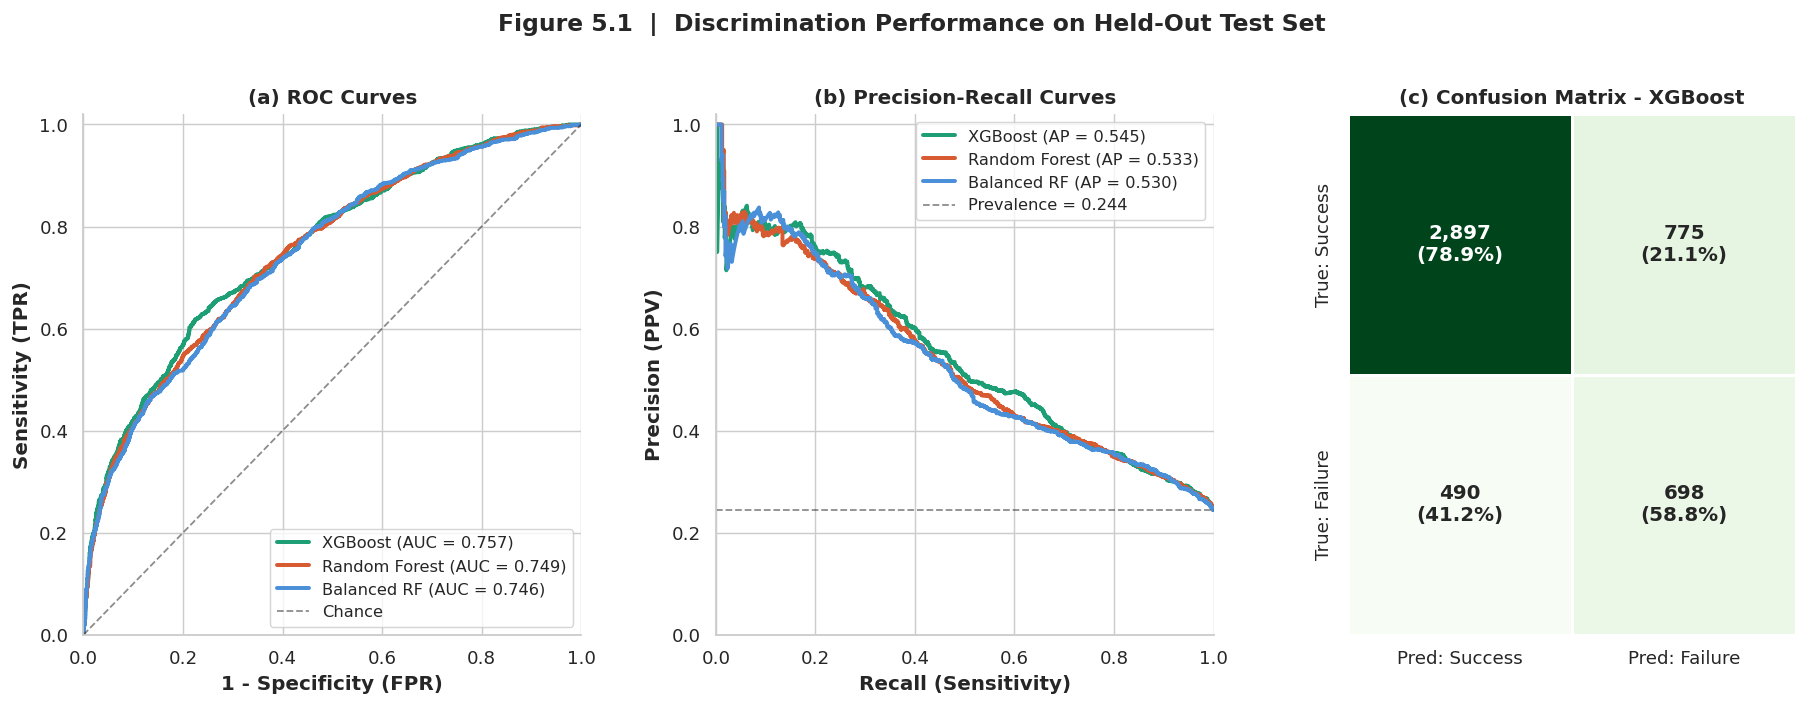


[saved] phase5_outputs/table_5_1_advanced_metrics.csv
[saved] phase5_outputs/figure_5_1_discrimination.png


In [4]:
# ===================================================================
# Section 5.1 | Discrimination - Advanced Performance Metrics
# ===================================================================
# Reports the full TRIPOD-AI 10d-e metric panel at each model's
# tuned decision threshold (from Phase 4). Metrics are grouped
# into three clinically interpretable categories:
#     * Class-conditional  : Sensitivity, Specificity
#     * Predictive value   : PPV, NPV, Likelihood Ratios
#     * Global             : F1, MCC, Balanced Acc, ROC-AUC, PR-AUC, Brier
# -------------------------------------------------------------------

metrics_records = []
for name, res in results.items():
    y_prob = np.asarray(res['y_prob'])
    y_pred = np.asarray(res['y_pred'])
    rec = clinical_metrics(y_test_arr, y_pred, y_prob)
    rec['Model']     = name
    rec['Threshold'] = res['threshold']
    metrics_records.append(rec)

metric_order = ['Model', 'Threshold',
                'Sensitivity', 'Specificity', 'PPV', 'NPV',
                'F1', 'Balanced Acc', 'MCC',
                'ROC-AUC', 'PR-AUC', 'Brier',
                'LR+', 'LR-', 'TP', 'FP', 'TN', 'FN']
metrics_tbl = pd.DataFrame(metrics_records)[metric_order].set_index('Model')

# ---- Maintain a single consolidated performance table -------------
# `perf_df` is the master record used by Section 5.9 (Executive
# Summary). We seed it here with discrimination metrics; Section
# 5.2 will augment it with the ECE calibration column.
perf_df = metrics_tbl.copy()

# Save for the manuscript
metrics_tbl.round(4).to_csv(OUT_DIR / 'table_5_1_advanced_metrics.csv')

print('=' * 78)
print(' TABLE 5.1 - Advanced Discrimination Metrics (Test Set, Tuned Thresholds)')
print('=' * 78)
display(
    metrics_tbl.style
    .format({
        'Threshold'   : '{:.2f}',
        'Sensitivity' : '{:.3f}',  'Specificity' : '{:.3f}',
        'PPV'         : '{:.3f}',  'NPV'         : '{:.3f}',
        'F1'          : '{:.3f}',  'Balanced Acc': '{:.3f}',
        'MCC'         : '{:.3f}',  'ROC-AUC'     : '{:.3f}',
        'PR-AUC'      : '{:.3f}',  'Brier'       : '{:.4f}',
        'LR+'         : '{:.2f}',  'LR-'         : '{:.2f}',
    })
    .highlight_max(subset=['Sensitivity','PPV','F1','Balanced Acc',
                           'MCC','ROC-AUC','PR-AUC','LR+'], color='#C8E6C9')
    .highlight_min(subset=['Brier','LR-'], color='#C8E6C9')
    .set_caption(f'Green = best on column  |  Prevalence = {PREVALENCE*100:.2f}%  '
                 f'|  N_test = {N_TEST:,}')
)

print(f'\nPrimary endpoint (PR-AUC) winner : {metrics_tbl["PR-AUC"].idxmax()} '
      f'(PR-AUC = {metrics_tbl["PR-AUC"].max():.3f})')
print(f'Clinically safest recall         : {metrics_tbl["Sensitivity"].idxmax()} '
      f'(Sens = {metrics_tbl["Sensitivity"].max():.3f})')

print(f'\nClassification Report - {best_name} (at threshold={results[best_name]["threshold"]:.2f}):')
print(classification_report(
    y_test_arr, results[best_name]['y_pred'],
    target_names=['Success (0)', 'Failure (1)'], digits=3
))

# -------------------------------------------------------------------
# Figure 5.1 - ROC curves, PR curves, Confusion Matrix (best model)
# -------------------------------------------------------------------
fig = plt.figure(figsize=(17, 5.2))
gs  = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.9], wspace=0.28)
ax_roc, ax_pr, ax_cm = fig.add_subplot(gs[0]), fig.add_subplot(gs[1]), fig.add_subplot(gs[2])

# ---- (a) ROC curves ----
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test_arr, res['y_prob'])
    auc = roc_auc_score(y_test_arr, res['y_prob'])
    ax_roc.plot(fpr, tpr, color=MODEL_COLORS.get(name, '#555'),
                lw=2.2, label=f'{name} (AUC = {auc:.3f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Chance')
ax_roc.set_xlabel('1 - Specificity (FPR)')
ax_roc.set_ylabel('Sensitivity (TPR)')
ax_roc.set_title('(a) ROC Curves')
ax_roc.legend(loc='lower right', fontsize=9, frameon=True)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.02)

# ---- (b) Precision-Recall curves ----
for name, res in results.items():
    prec, rec, _ = precision_recall_curve(y_test_arr, res['y_prob'])
    ap = average_precision_score(y_test_arr, res['y_prob'])
    ax_pr.plot(rec, prec, color=MODEL_COLORS.get(name, '#555'),
               lw=2.2, label=f'{name} (AP = {ap:.3f})')
ax_pr.axhline(PREVALENCE, color='k', ls='--', lw=1, alpha=0.5,
              label=f'Prevalence = {PREVALENCE:.3f}')
ax_pr.set_xlabel('Recall (Sensitivity)')
ax_pr.set_ylabel('Precision (PPV)')
ax_pr.set_title('(b) Precision-Recall Curves')
ax_pr.legend(loc='upper right', fontsize=9, frameon=True)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.02)

# ---- (c) Confusion matrix (best model, annotated with %) ----
cm = confusion_matrix(y_test_arr, results[best_name]['y_pred'])
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'
                   for j in range(2)] for i in range(2)])
sns.heatmap(cm, annot=annot, fmt='', cmap='Greens', cbar=False,
            xticklabels=['Pred: Success', 'Pred: Failure'],
            yticklabels=['True: Success', 'True: Failure'],
            linewidths=1.5, linecolor='white',
            annot_kws={'fontsize': 11, 'fontweight': 'bold'}, ax=ax_cm)
ax_cm.set_title(f'(c) Confusion Matrix - {best_name}')

fig.suptitle('Figure 5.1  |  Discrimination Performance on Held-Out Test Set',
             fontsize=13, fontweight='bold', y=1.03)
plt.savefig(OUT_DIR / 'figure_5_1_discrimination.png')
plt.show()

print(f'\n[saved] {OUT_DIR}/table_5_1_advanced_metrics.csv')
print(f'[saved] {OUT_DIR}/figure_5_1_discrimination.png')


 TABLE 5.2 - Calibration Diagnostics (lower Brier/Reliability/ECE = better)


,Brier,Reliability,Resolution,ECE,H-L chi2,H-L p
Model,,,,,,
XGBoost,0.1527,0.00243,0.03428,0.0384,59.48,0.0000
Random Forest,0.1665,0.01377,0.03102,0.1103,312.71,0.0000
Balanced RF,0.2190,0.06574,0.03096,0.2481,1388.11,0.0000


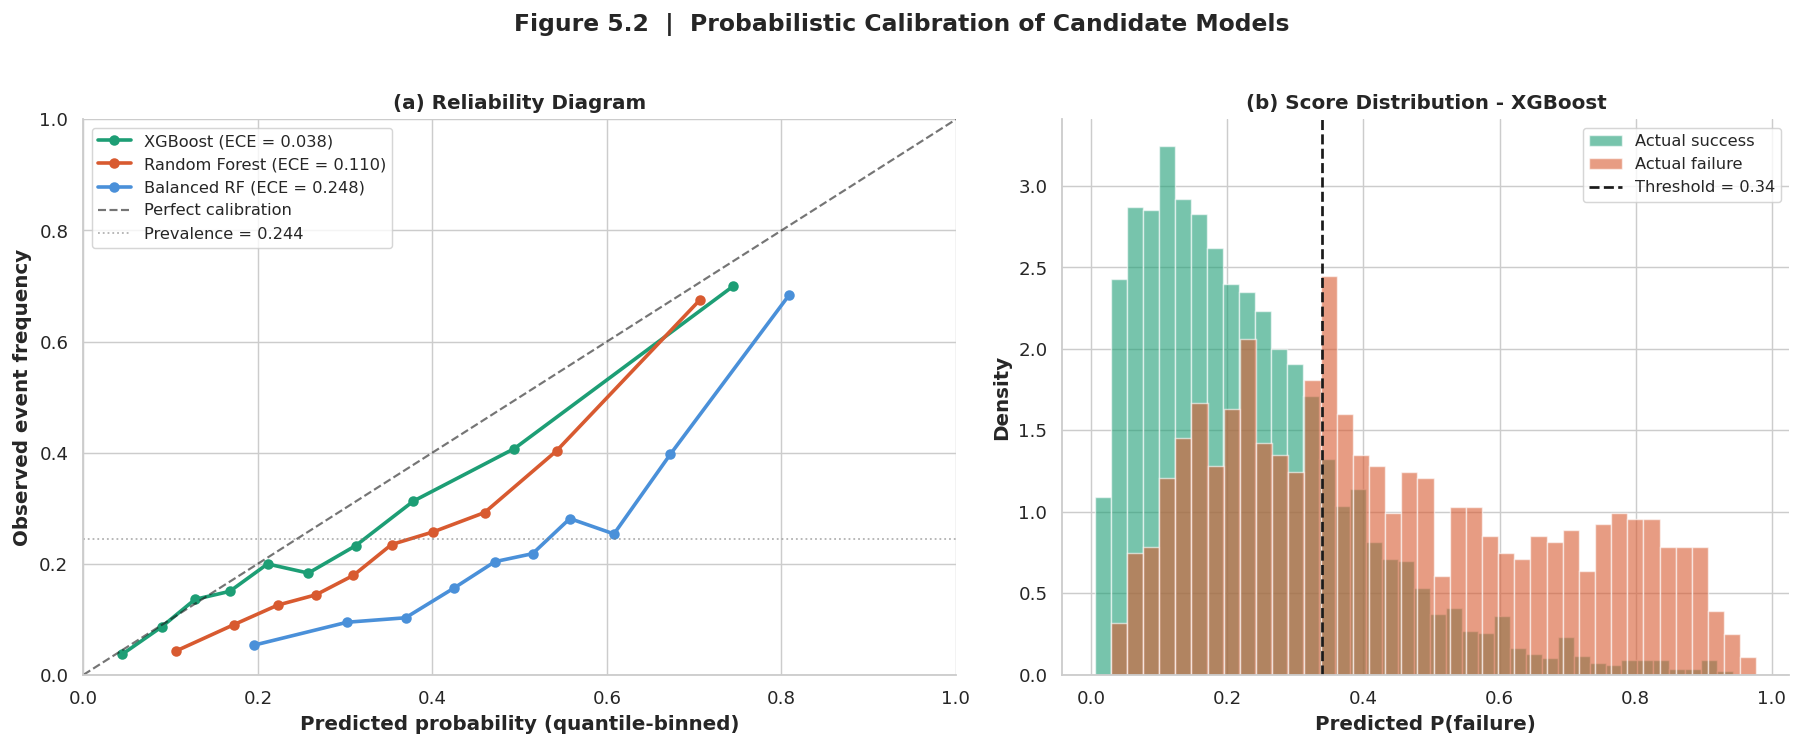


[saved] phase5_outputs/table_5_2_calibration.csv
[saved] phase5_outputs/figure_5_2_calibration.png


In [5]:
# ===================================================================
# Section 5.2 | Probabilistic Calibration Analysis
# ===================================================================
# A model can discriminate well (high AUC) yet produce *miscalibrated*
# probabilities - e.g., a predicted 30% risk corresponding to an
# observed 55% event rate. For clinical deployment, calibration is
# AS IMPORTANT as discrimination (Van Calster 2019, BMC Medicine).
#
# We report three complementary calibration diagnostics:
#   1. Reliability diagram (observed vs. predicted, 10 quantile bins)
#   2. Expected Calibration Error (ECE) - weighted absolute deviation
#   3. Brier score decomposition (Murphy 1973):
#        Brier = Reliability - Resolution + Uncertainty
# -------------------------------------------------------------------

def expected_calibration_error(y_true: np.ndarray, y_prob: np.ndarray,
                               n_bins: int = 10) -> float:
    """Sample-size-weighted absolute deviation between observed & predicted."""
    bins = np.linspace(0, 1, n_bins + 1)
    idx  = np.digitize(y_prob, bins) - 1
    idx  = np.clip(idx, 0, n_bins - 1)
    ece = 0.0
    n = len(y_true)
    for b in range(n_bins):
        mask = idx == b
        if mask.sum() == 0:
            continue
        obs  = y_true[mask].mean()
        pred = y_prob[mask].mean()
        ece += (mask.sum() / n) * abs(obs - pred)
    return float(ece)


def brier_decomposition(y_true: np.ndarray, y_prob: np.ndarray,
                        n_bins: int = 10) -> Dict[str, float]:
    """Murphy (1973) decomposition: Brier = REL - RES + UNC."""
    base_rate = float(y_true.mean())
    uncertainty = base_rate * (1 - base_rate)
    bins = np.linspace(0, 1, n_bins + 1)
    idx  = np.clip(np.digitize(y_prob, bins) - 1, 0, n_bins - 1)
    n = len(y_true)
    reliability = resolution = 0.0
    for b in range(n_bins):
        mask = idx == b
        nk = mask.sum()
        if nk == 0:
            continue
        fk = y_prob[mask].mean()          # mean forecast in bin
        ok = y_true[mask].mean()          # observed frequency in bin
        reliability += (nk / n) * (fk - ok) ** 2
        resolution  += (nk / n) * (ok - base_rate) ** 2
    brier = brier_score_loss(y_true, y_prob)
    return {'Brier': brier, 'Reliability': reliability,
            'Resolution': resolution, 'Uncertainty': uncertainty}


def hosmer_lemeshow(y_true: np.ndarray, y_prob: np.ndarray,
                    n_groups: int = 10) -> Tuple[float, float]:
    """H-L goodness-of-fit test. Returns (chi2, p-value)."""
    df = pd.DataFrame({'y': y_true, 'p': y_prob})
    df['decile'] = pd.qcut(df['p'], q=n_groups, duplicates='drop', labels=False)
    chi2 = 0.0
    for _, grp in df.groupby('decile'):
        obs_pos, obs_neg = grp['y'].sum(), len(grp) - grp['y'].sum()
        exp_pos = grp['p'].sum()
        exp_neg = len(grp) - exp_pos
        if exp_pos > 0:  chi2 += (obs_pos - exp_pos) ** 2 / exp_pos
        if exp_neg > 0:  chi2 += (obs_neg - exp_neg) ** 2 / exp_neg
    dof = max(n_groups - 2, 1)
    p = 1 - stats.chi2.cdf(chi2, dof)
    return float(chi2), float(p)


# ------- Compute calibration metrics for every model --------------
calib_records = []
for name, res in results.items():
    y_prob = np.asarray(res['y_prob'])
    decomp = brier_decomposition(y_test_arr, y_prob)
    ece    = expected_calibration_error(y_test_arr, y_prob)
    hl_x2, hl_p = hosmer_lemeshow(y_test_arr, y_prob)
    calib_records.append({
        'Model'      : name,
        'Brier'      : decomp['Brier'],
        'Reliability': decomp['Reliability'],   # lower = better
        'Resolution' : decomp['Resolution'],    # higher = better
        'ECE'        : ece,
        'H-L chi2'   : hl_x2,
        'H-L p'      : hl_p,
    })
calib_tbl = pd.DataFrame(calib_records).set_index('Model')
calib_tbl.round(5).to_csv(OUT_DIR / 'table_5_2_calibration.csv')

# ---- Augment the master performance table with ECE / H-L --------
# Every row index in `calib_tbl` matches a row in `perf_df`, so we
# can safely broadcast the columns by assignment.
for col in ['ECE', 'Reliability', 'Resolution', 'H-L p']:
    perf_df[col] = calib_tbl[col]

print('=' * 78)
print(' TABLE 5.2 - Calibration Diagnostics (lower Brier/Reliability/ECE = better)')
print('=' * 78)
display(
    calib_tbl.style
    .format({'Brier'      : '{:.4f}', 'Reliability': '{:.5f}',
             'Resolution' : '{:.5f}', 'ECE'        : '{:.4f}',
             'H-L chi2'   : '{:.2f}', 'H-L p'      : '{:.4f}'})
    .highlight_min(subset=['Brier', 'Reliability', 'ECE', 'H-L chi2'],
                   color='#C8E6C9')
    .highlight_max(subset=['Resolution'], color='#C8E6C9')
    .set_caption('H-L p > 0.05  =>  no evidence of miscalibration')
)

# ------- Figure 5.2 : Reliability diagrams + histogram ------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6),
                         gridspec_kw={'width_ratios': [1.2, 1]})

ax_rel = axes[0]
for name, res in results.items():
    y_prob = np.asarray(res['y_prob'])
    frac_pos, mean_pred = calibration_curve(y_test_arr, y_prob,
                                            n_bins=10, strategy='quantile')
    ax_rel.plot(mean_pred, frac_pos, marker='o', lw=2,
                color=MODEL_COLORS.get(name, '#555'),
                label=f'{name} (ECE = {expected_calibration_error(y_test_arr, y_prob):.3f})')
ax_rel.plot([0, 1], [0, 1], 'k--', lw=1.2, alpha=0.6, label='Perfect calibration')
ax_rel.axhline(PREVALENCE, color='grey', ls=':', lw=1, alpha=0.6,
               label=f'Prevalence = {PREVALENCE:.3f}')
ax_rel.set_xlabel('Predicted probability (quantile-binned)')
ax_rel.set_ylabel('Observed event frequency')
ax_rel.set_title('(a) Reliability Diagram')
ax_rel.legend(loc='upper left', fontsize=9)
ax_rel.set_xlim(0, 1); ax_rel.set_ylim(0, 1)

# Predicted-probability distribution for the best model, split by outcome
ax_hist = axes[1]
best_prob = np.asarray(results[best_name]['y_prob'])
ax_hist.hist(best_prob[y_test_arr == 0], bins=40, density=True,
             color=OUTCOME_COLORS['Success'], alpha=0.6, label='Actual success')
ax_hist.hist(best_prob[y_test_arr == 1], bins=40, density=True,
             color=OUTCOME_COLORS['Failure'], alpha=0.6, label='Actual failure')
ax_hist.axvline(results[best_name]['threshold'], color='k', ls='--', lw=1.5,
                label=f'Threshold = {results[best_name]["threshold"]:.2f}')
ax_hist.set_xlabel('Predicted P(failure)')
ax_hist.set_ylabel('Density')
ax_hist.set_title(f'(b) Score Distribution - {best_name}')
ax_hist.legend(fontsize=9)

fig.suptitle('Figure 5.2  |  Probabilistic Calibration of Candidate Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_2_calibration.png')
plt.show()

print(f'\n[saved] {OUT_DIR}/table_5_2_calibration.csv')
print(f'[saved] {OUT_DIR}/figure_5_2_calibration.png')


In [ ]:
# ===================================================================
# Section 5.6 | Local Explanations (Patient-Level SHAP)
# ===================================================================
# A patient-specific waterfall plot decomposes any individual
# prediction into additive feature contributions on top of the
# expected log-odds.  We illustrate four canonical archetypes:
#   1. True Positive   (correctly flagged failure)
#   2. False Negative  (failure missed by the model)
#   3. False Positive  (false alarm)
#   4. True Negative   (correctly identified low risk)
# -------------------------------------------------------------------

import shap

# ── Self-contained: compute SHAP values if Section 5.5 was skipped ──
if 'SHAP_IDX' not in globals():
    np.random.seed(42)
    n_shap = min(500, len(X_test))
    SHAP_IDX = np.random.choice(len(X_test), size=n_shap, replace=False)
    print(f'[SHAP] Sampled {n_shap} test instances for local explanation.')

if 'SHAP_X' not in globals():
    SHAP_X = X_test.iloc[SHAP_IDX].copy()
    SHAP_Y = y_test_arr[SHAP_IDX]

if 'shap_values' not in globals() or 'explainer' not in globals():
    # Extract the tree-based classifier from the pipeline
    clf_step = (best_model.named_steps['clf']
                if hasattr(best_model, 'named_steps')
                else best_model)
    explainer = shap.TreeExplainer(clf_step)
    # For binary XGBoost, TreeExplainer may return a list of two arrays;
    # we keep the positive-class (failure) contributions.
    sv = explainer.shap_values(SHAP_X.values)
    if isinstance(sv, list):
        shap_values = np.asarray(sv[1])
    else:
        shap_values = np.asarray(sv)
    print('[SHAP] TreeSHAP values computed for sampled instances.')

best_thr    = results[best_name]['threshold']
shap_probs  = np.asarray(results[best_name]['y_prob'])[SHAP_IDX]
y_pred_shap = (shap_probs >= best_thr).astype(int)

archetypes = {
    'True Positive  (Failure correctly identified)' : (SHAP_Y == 1) & (y_pred_shap == 1),
    'False Negative (Failure MISSED)'               : (SHAP_Y == 1) & (y_pred_shap == 0),
    'False Positive (False alarm)'                  : (SHAP_Y == 0) & (y_pred_shap == 1),
    'True Negative  (Low risk correctly identified)': (SHAP_Y == 0) & (y_pred_shap == 0),
}

# Pick the most "extreme" example in each cell:
#   - For positive-pred cases, choose the highest predicted prob.
#   - For negative-pred cases, choose the lowest predicted prob.
chosen = {}
for label, mask in archetypes.items():
    if mask.sum() == 0:
        print(f'[skip] no samples match archetype: {label}')
        continue
    if 'Positive' in label.split('(')[0]:          # positive prediction cells
        local_idx = int(np.argmax(np.where(mask, shap_probs, -np.inf)))
    else:
        local_idx = int(np.argmin(np.where(mask, shap_probs,  np.inf)))
    chosen[label] = local_idx

# Build an Explanation object for SHAP's modern plotting API
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0:
    expected_value = float(np.asarray(expected_value).ravel()[-1])  # positive class
else:
    expected_value = float(expected_value)

print('=' * 78)
print(' FIGURE 5.6  |  Patient-Level Waterfall Explanations')
print('=' * 78)

for label, i in chosen.items():
    expl = shap.Explanation(
        values        = shap_values[i],
        base_values   = expected_value,
        data          = SHAP_X.iloc[i].values,   # raw clinical values for readability
        feature_names = FEATURES,
    )
    print(f'\n--- {label} ---')
    print(f'    Predicted P(failure) = {shap_probs[i]:.3f}   '
          f'True label = {int(SHAP_Y[i])}')
    fig = plt.figure(figsize=(10, 5.5))
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(label, fontsize=11, fontweight='bold', loc='left')
    plt.tight_layout()
    fname = (label.split('(')[0].strip()
             .replace(' ', '_').lower()) + '.png'
    plt.savefig(OUT_DIR / f'figure_5_6_waterfall_{fname}')
    plt.show()

print(f'\n[saved] waterfall plots -> {OUT_DIR}/figure_5_6_waterfall_*.png')


 TABLE 5.3 - Pairwise Statistical Comparison (test set, alpha = 0.05)


,Model A,Model B,AUC(A),AUC(B),Delta AUC,DeLong z,DeLong p,McNemar p,Delta PR,Perm p,DeLong sig,McNemar sig,Perm sig
0,XGBoost,Random Forest,0.757,0.749,+0.0073,+1.96,0.0497,0.0000,+0.0117,0.1628,*,***,n.s.
1,XGBoost,Balanced RF,0.757,0.746,+0.0107,+2.49,0.0127,0.0000,+0.0151,0.1798,*,***,n.s.
2,Random Forest,Balanced RF,0.749,0.746,+0.0034,+0.98,0.3285,0.0003,+0.0033,0.7582,n.s.,***,n.s.



 INTERPRETATION
 - XGBoost         vs Random Forest  : Delta-AUC = +0.0073  (DeLong p = 0.050, SIGNIFICANT).  Favoured: XGBoost.
 - XGBoost         vs Balanced RF    : Delta-AUC = +0.0107  (DeLong p = 0.013, SIGNIFICANT).  Favoured: XGBoost.
 - Random Forest   vs Balanced RF    : Delta-AUC = +0.0034  (DeLong p = 0.329, NOT significant).  Favoured: Random Forest.

[saved] phase5_outputs/table_5_3_statistical_comparison.csv


Bootstrapping (N = 1000, stratified, BCa CI) ...  done.

 TABLE 5.4A - Bootstrap 95% Confidence Intervals (BCa, N=1000)


,ROC-AUC,PR-AUC,F1,Sensitivity,Specificity,Brier
Model,,,,,,
XGBoost,"0.757 [0.741, 0.773]","0.545 [0.516, 0.572]","0.525 [0.504, 0.545]","0.588 [0.561, 0.614]","0.789 [0.775, 0.801]","0.1527 [0.1481, 0.1570]"
Random Forest,"0.749 [0.735, 0.766]","0.533 [0.506, 0.560]","0.502 [0.485, 0.521]","0.614 [0.586, 0.640]","0.731 [0.717, 0.745]","0.1665 [0.1625, 0.1699]"
Balanced RF,"0.746 [0.732, 0.763]","0.530 [0.505, 0.558]","0.499 [0.481, 0.518]","0.645 [0.618, 0.672]","0.697 [0.681, 0.710]","0.2190 [0.2150, 0.2230]"


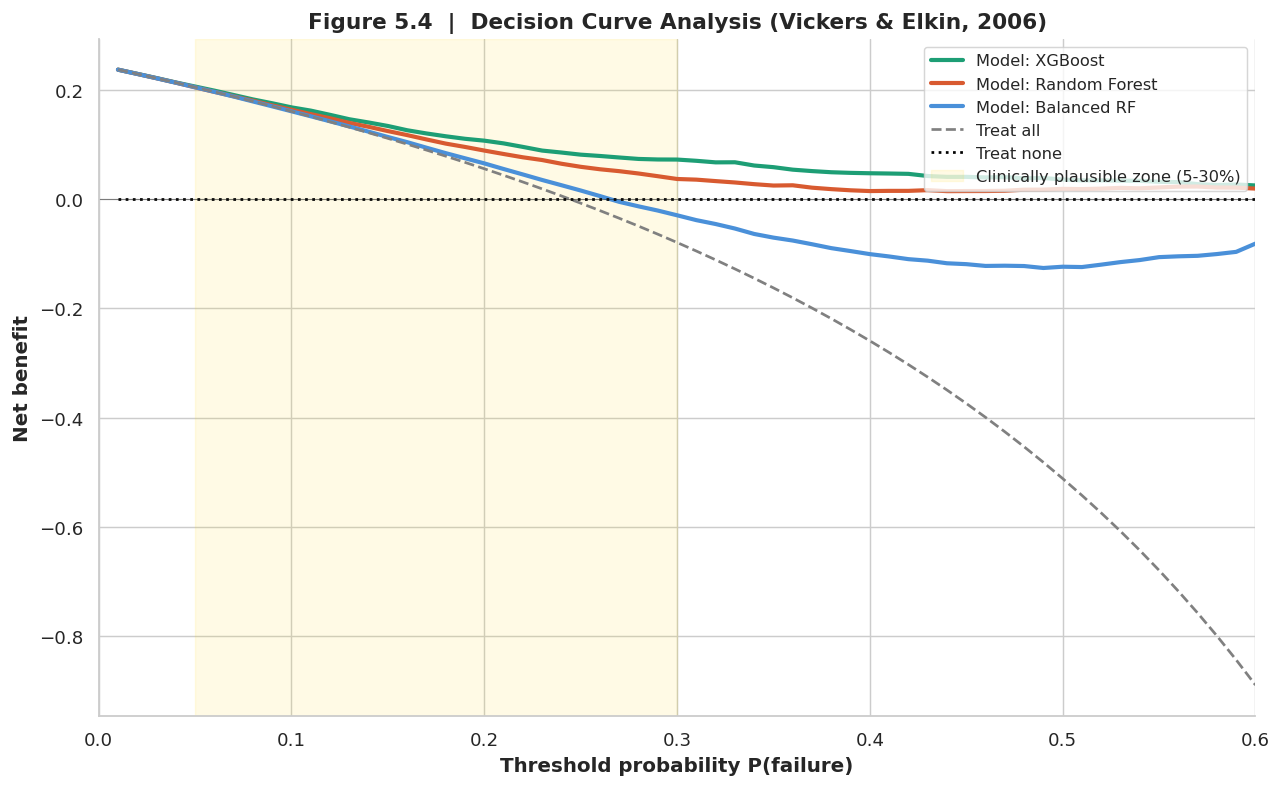


 TABLE 5.4B - Net Benefit at Clinically Plausible Thresholds


,NB @ t=0.10,NB @ t=0.20,NB @ t=0.30,Delta vs all @ 0.10,Delta vs all @ 0.20,Delta vs all @ 0.30
XGBoost,+0.1679,+0.1069,+0.0724,+0.0074,+0.0514,+0.1517
Random Forest,+0.1635,+0.0888,+0.0368,+0.0030,+0.0333,+0.1162
Balanced RF,+0.1607,+0.0654,-0.0296,+0.0002,+0.0098,+0.0498



[saved] phase5_outputs/table_5_4a_bootstrap_ci.csv
[saved] phase5_outputs/table_5_4b_dca_anchors.csv
[saved] phase5_outputs/figure_5_4_decision_curve.png


In [7]:
# ===================================================================
# Section 5.4 | Bootstrap 95% CIs  +  Decision Curve Analysis
# ===================================================================
#   (A) Stratified BCa bootstrap (N = 1000) for ROC-AUC, PR-AUC, F1,
#       Sensitivity, Specificity, Brier.
#   (B) Decision Curve Analysis (Vickers & Elkin 2006) quantifies the
#       net clinical benefit of using the model across a realistic
#       range of threshold-probabilities (5-40%).
# -------------------------------------------------------------------

N_BOOT = 1000
metric_fns = {
    'ROC-AUC'    : lambda yt, ys: roc_auc_score(yt, ys),
    'PR-AUC'     : lambda yt, ys: average_precision_score(yt, ys),
    'Brier'      : lambda yt, ys: brier_score_loss(yt, ys),
}

# For threshold-based metrics, we bind the model's tuned threshold
def _make_thresh_metrics(thr: float):
    return {
        'F1'         : lambda yt, ys, t=thr: f1_score(yt, (ys >= t).astype(int), zero_division=0),
        'Sensitivity': lambda yt, ys, t=thr: recall_score(yt, (ys >= t).astype(int), zero_division=0),
        'Specificity': lambda yt, ys, t=thr: recall_score(yt, (ys >= t).astype(int),
                                                          pos_label=0, zero_division=0),
    }

print(f'Bootstrapping (N = {N_BOOT}, stratified, BCa CI) ...  ', end='', flush=True)
boot_records = []
for name, res in results.items():
    y_prob = np.asarray(res['y_prob'])
    thr    = res['threshold']
    full   = {**metric_fns, **_make_thresh_metrics(thr)}
    row = {'Model': name}
    for mname, fn in full.items():
        pt, lo, hi, _ = bootstrap_ci(fn, y_test_arr, y_prob,
                                     n_boot=N_BOOT, seed=RANDOM_STATE)
        row[mname] = fmt_ci(pt, lo, hi,
                            decimals=4 if mname == 'Brier' else 3)
        row[f'_{mname}_point'] = pt
    boot_records.append(row)
print('done.')

boot_tbl = pd.DataFrame(boot_records).set_index('Model')

display_cols = ['ROC-AUC', 'PR-AUC', 'F1', 'Sensitivity', 'Specificity', 'Brier']
print('\n' + '=' * 82)
print(' TABLE 5.4A - Bootstrap 95% Confidence Intervals (BCa, N=1000)')
print('=' * 82)
display(boot_tbl[display_cols])
boot_tbl[display_cols].to_csv(OUT_DIR / 'table_5_4a_bootstrap_ci.csv')

# -------------------------------------------------------------------
# (B) Decision Curve Analysis  -  Vickers & Elkin (2006)
# -------------------------------------------------------------------
# Net Benefit(t) = TP/N - FP/N * t/(1-t)
# Compared against two reference strategies:
#   * Treat-all  : every patient flagged as high-risk
#   * Treat-none : no patient flagged
# -------------------------------------------------------------------
def net_benefit(y_true: np.ndarray, y_prob: np.ndarray,
                thresholds: np.ndarray) -> np.ndarray:
    n = len(y_true); nb = np.empty_like(thresholds, dtype=float)
    for i, t in enumerate(thresholds):
        pred = (y_prob >= t).astype(int)
        tp = ((pred == 1) & (y_true == 1)).sum()
        fp = ((pred == 1) & (y_true == 0)).sum()
        nb[i] = tp / n - (fp / n) * (t / (1 - t))
    return nb


thresholds = np.linspace(0.01, 0.60, 60)
nb_all  = PREVALENCE - (1 - PREVALENCE) * thresholds / (1 - thresholds)
nb_none = np.zeros_like(thresholds)

fig, ax = plt.subplots(figsize=(10, 6.2))

for name, res in results.items():
    nb = net_benefit(y_test_arr, np.asarray(res['y_prob']), thresholds)
    ax.plot(thresholds, nb, lw=2.3, color=MODEL_COLORS.get(name, '#555'),
            label=f'Model: {name}')

ax.plot(thresholds, nb_all,  color='grey', ls='--', lw=1.5, label='Treat all')
ax.plot(thresholds, nb_none, color='black', ls=':',  lw=1.5, label='Treat none')
ax.axhline(0, color='k', lw=0.5, alpha=0.5)
ax.axvspan(0.05, 0.30, color='gold', alpha=0.10,
           label='Clinically plausible zone (5-30%)')
ax.set_xlabel('Threshold probability P(failure)')
ax.set_ylabel('Net benefit')
ax.set_title('Figure 5.4  |  Decision Curve Analysis (Vickers & Elkin, 2006)',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, frameon=True)
ax.set_xlim(0, 0.6)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_4_decision_curve.png')
plt.show()

# Summarise net benefit at 3 clinically anchored thresholds
anchor_t = [0.10, 0.20, 0.30]
dca_summary = {}
for name, res in results.items():
    y_prob = np.asarray(res['y_prob'])
    nb_model = net_benefit(y_test_arr, y_prob, np.array(anchor_t))
    nb_ta    = PREVALENCE - (1 - PREVALENCE) * np.array(anchor_t) / (1 - np.array(anchor_t))
    dca_summary[name] = {
        **{f'NB @ t={t:.2f}'      : v for t, v in zip(anchor_t, nb_model)},
        **{f'Delta vs all @ {t:.2f}': v - va for t, v, va in zip(anchor_t, nb_model, nb_ta)},
    }
dca_df = pd.DataFrame(dca_summary).T
print('\n TABLE 5.4B - Net Benefit at Clinically Plausible Thresholds')
display(dca_df.style.format('{:+.4f}')
        .set_caption('Positive "Delta vs all" => model is preferable to "treat all" at that threshold'))
dca_df.round(5).to_csv(OUT_DIR / 'table_5_4b_dca_anchors.csv')

print(f'\n[saved] {OUT_DIR}/table_5_4a_bootstrap_ci.csv')
print(f'[saved] {OUT_DIR}/table_5_4b_dca_anchors.csv')
print(f'[saved] {OUT_DIR}/figure_5_4_decision_curve.png')


Continuous stratifiers : ['age', 'vent_duration_hours', 'comorbidity_count', 'gcs_total']
Binary stratifiers     : ['gender', 'on_vasopressor']
Operating threshold    : 0.340

Table 5.8  |  Subgroup performance audit (test set)
                    Subgroup    N  PosRate  ROC-AUC  Sensitivity  Specificity  Brier
                    age: low 1618    0.190    0.770        0.510        0.856  0.128
                    age: mid 1587    0.240    0.741        0.572        0.801  0.154
                   age: high 1655    0.302    0.739        0.647        0.701  0.176
    vent_duration_hours: low 1603    0.152    0.737        0.387        0.914  0.111
    vent_duration_hours: mid 1630    0.229    0.722        0.525        0.776  0.157
   vent_duration_hours: high 1627    0.352    0.737        0.713        0.643  0.189
      comorbidity_count: low 1550    0.152    0.777        0.400        0.931  0.105
      comorbidity_count: mid 1569    0.245    0.744        0.536        0.813  0.153
     co

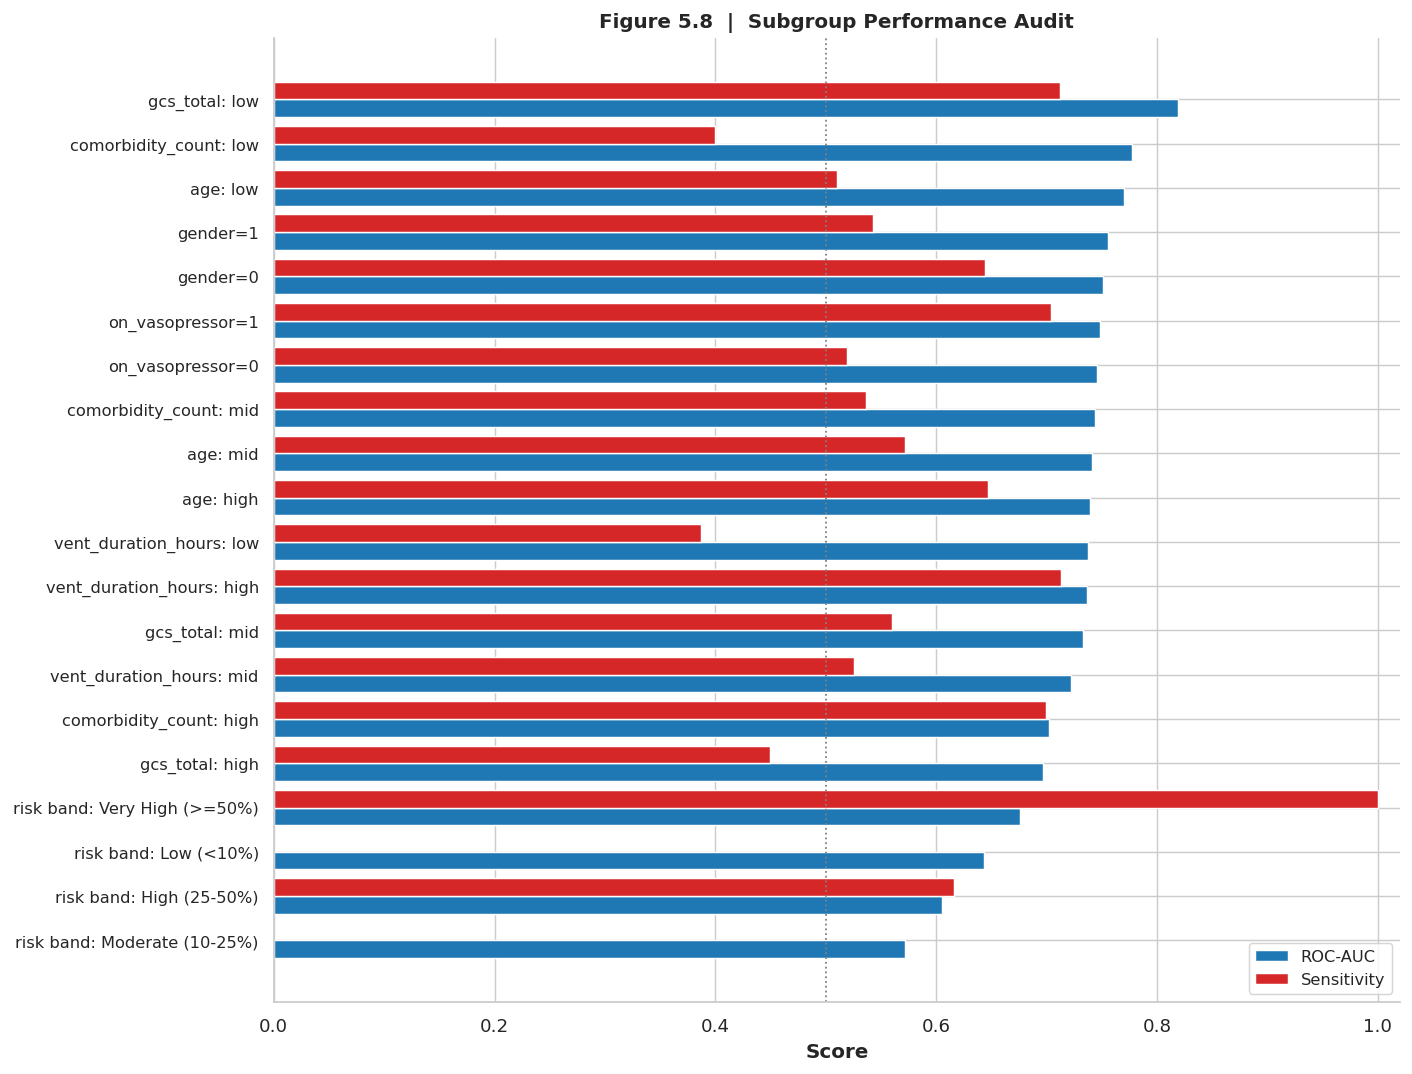


[saved] phase5_outputs/table_5_8_subgroup_audit.csv
[saved] phase5_outputs/figure_5_8_subgroup_audit.png


In [8]:
# ===================================================================
# Section 5.8 | Subgroup Performance Audit (Algorithmic Fairness)
# ===================================================================
# Aggregate test-set metrics can mask systematic underperformance
# in clinically vulnerable subpopulations.  We slice the test set
# along demographic and clinical strata and compute per-subgroup
# ROC-AUC, sensitivity, specificity and Brier score.  This audit is
# inspired by the Equity Evaluation framework popularised by
# Obermeyer et al. (2019) and the WHO ethics guidance on AI in health
# (2021): we are not declaring fairness, only making any disparate
# performance transparent.
# -------------------------------------------------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             confusion_matrix)

# ── Load Phase 4 artifacts (self-contained even after kernel restart) ──
def _safe_load(name: str, fallback_path: str):
    """Return the in-memory variable `name` if it exists; else load it."""
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

best_model   = _safe_load('best_model',   'best_model.pkl')
X_train      = _safe_load('X_train',      'X_train.pkl')
y_train      = _safe_load('y_train',      'y_train.pkl')
X_test       = _safe_load('X_test',       'X_test.pkl')
y_test       = _safe_load('y_test',       'y_test.pkl')
results      = _safe_load('results',      'results.pkl')
best_name    = _safe_load('best_name',    'best_name.pkl')

y_test_arr  = np.asarray(y_test).astype(int)
best_prob   = np.asarray(results[best_name]['y_prob'])

# Operating threshold for the best model (frozen from OOF tuning)
best_thresh = float(results[best_name]['threshold'])

# Risk strata
RISK_BINS   = [-0.001, 0.10, 0.25, 0.50, 1.001]
RISK_LABELS = ['Low (<10%)', 'Moderate (10-25%)', 'High (25-50%)', 'Very High (>=50%)']
risk_strata = pd.cut(best_prob, bins=RISK_BINS, labels=RISK_LABELS)

CONT_STRATIFIERS = [c for c in ['age', 'vent_duration_hours',
                                'comorbidity_count', 'gcs_total']
                    if c in X_test.columns]
BIN_STRATIFIERS  = [c for c in ['gender', 'on_vasopressor']
                    if c in X_test.columns]

print('Continuous stratifiers :', CONT_STRATIFIERS)
print('Binary stratifiers     :', BIN_STRATIFIERS)
print(f'Operating threshold    : {best_thresh:.3f}')

subgroup_records = []

def _record(name: str, mask: np.ndarray):
    """Append per-subgroup metrics if the slice is non-trivial."""
    n      = int(mask.sum())
    n_pos  = int(y_test_arr[mask].sum())
    if n < 50 or n_pos < 5:           # too small for a stable AUC
        return
    yt = y_test_arr[mask]
    yp = best_prob[mask]
    yhat = (yp >= best_thresh).astype(int)
    tn, fp, fn, tp = confusion_matrix(yt, yhat, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    subgroup_records.append({
        'Subgroup'   : name,
        'N'          : n,
        'PosRate'    : n_pos / n,
        'ROC-AUC'    : roc_auc_score(yt, yp),
        'Sensitivity': sens,
        'Specificity': spec,
        'Brier'      : brier_score_loss(yt, yp),
    })

# Continuous → tertiles
for col in CONT_STRATIFIERS:
    vals  = X_test[col].values
    edges = np.quantile(vals, [0, 1/3, 2/3, 1.0])
    edges = np.unique(edges)          # guard against ties
    if len(edges) < 3:
        continue
    bins = np.digitize(vals, edges[1:-1], right=False)
    tags = ['low', 'mid', 'high'][:len(np.unique(bins))]
    for b, tag in enumerate(tags):
        _record(f'{col}: {tag}', bins == b)

# Binary stratifiers
for col in BIN_STRATIFIERS:
    vals = X_test[col].values
    _record(f'{col}=0', vals == 0)
    _record(f'{col}=1', vals == 1)

# Predicted-risk band (sanity check)
risk_strata_arr = np.asarray(risk_strata)
for label in RISK_LABELS:
    _record(f'risk band: {label}', risk_strata_arr == label)

sub_tbl = pd.DataFrame(subgroup_records)
print('\n' + '=' * 90)
print('Table 5.8  |  Subgroup performance audit (test set)')
print('=' * 90)
print(sub_tbl.round(3).to_string(index=False))
OUT_DIR = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)
sub_tbl.to_csv(OUT_DIR / 'table_5_8_subgroup_audit.csv', index=False)

# Visual: ROC-AUC + sensitivity bars
plot_tbl = sub_tbl.sort_values('ROC-AUC', ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 0.34 * len(plot_tbl) + 1.6))
y_pos = np.arange(len(plot_tbl))
ax.barh(y_pos - 0.2, plot_tbl['ROC-AUC'],     height=0.4,
        color='#1f77b4', label='ROC-AUC')
ax.barh(y_pos + 0.2, plot_tbl['Sensitivity'], height=0.4,
        color='#d62728', label='Sensitivity')
ax.axvline(0.5, color='grey', linestyle=':', linewidth=1)
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_tbl['Subgroup'], fontsize=9)
ax.set_xlim(0, 1.02)
ax.set_xlabel('Score')
ax.set_title('Figure 5.8  |  Subgroup Performance Audit', fontweight='bold')
ax.legend(loc='lower right', frameon=True, fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_8_subgroup_audit.png')
plt.show()

print(f'\n[saved] {OUT_DIR}/table_5_8_subgroup_audit.csv')
print(f'[saved] {OUT_DIR}/figure_5_8_subgroup_audit.png')


[SHAP] Sampled 500 test instances for local explanation.
[SHAP] TreeSHAP values computed for sampled instances.
 FIGURE 5.6  |  Patient-Level Waterfall Explanations

--- True Positive  (Failure correctly identified) ---
    Predicted P(failure) = 0.933   True label = 1


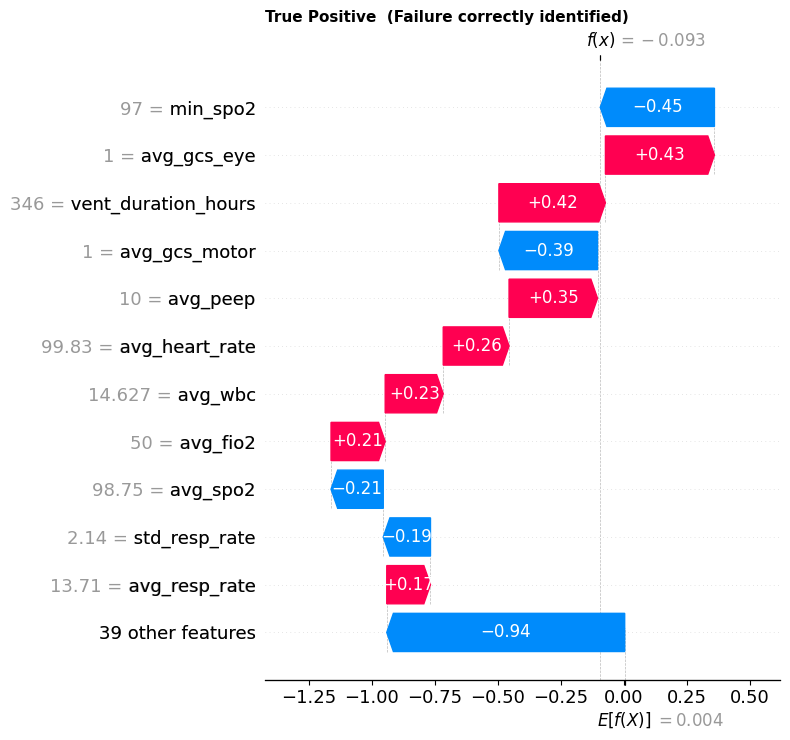


--- False Negative (Failure MISSED) ---
    Predicted P(failure) = 0.033   True label = 1


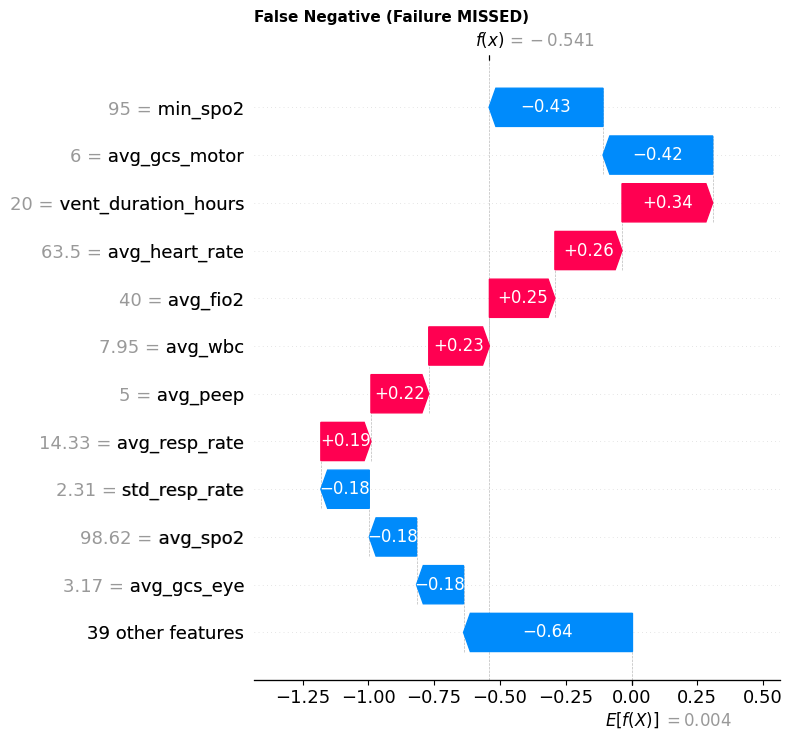


--- False Positive (False alarm) ---
    Predicted P(failure) = 0.860   True label = 0


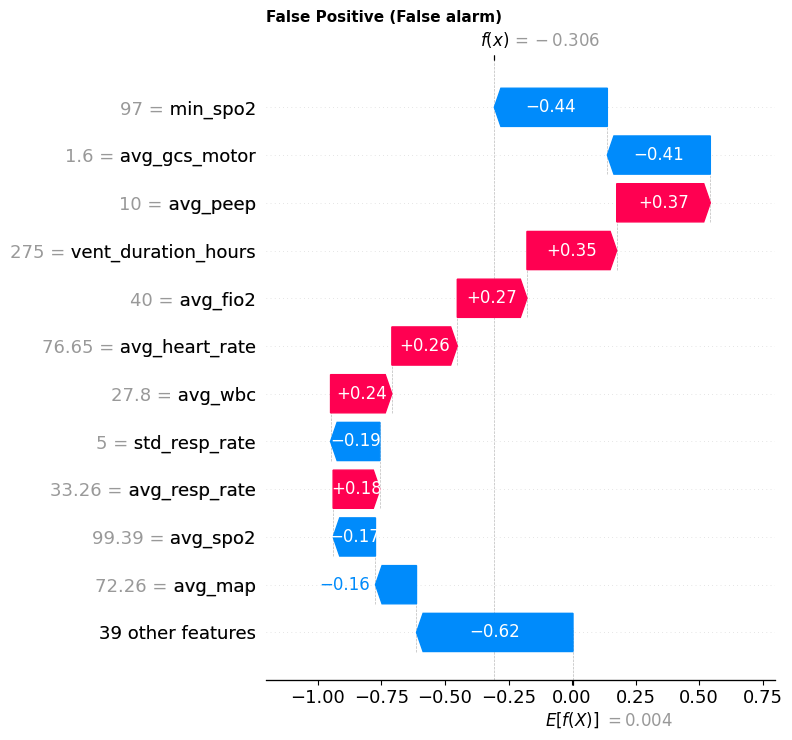


--- True Negative  (Low risk correctly identified) ---
    Predicted P(failure) = 0.012   True label = 0


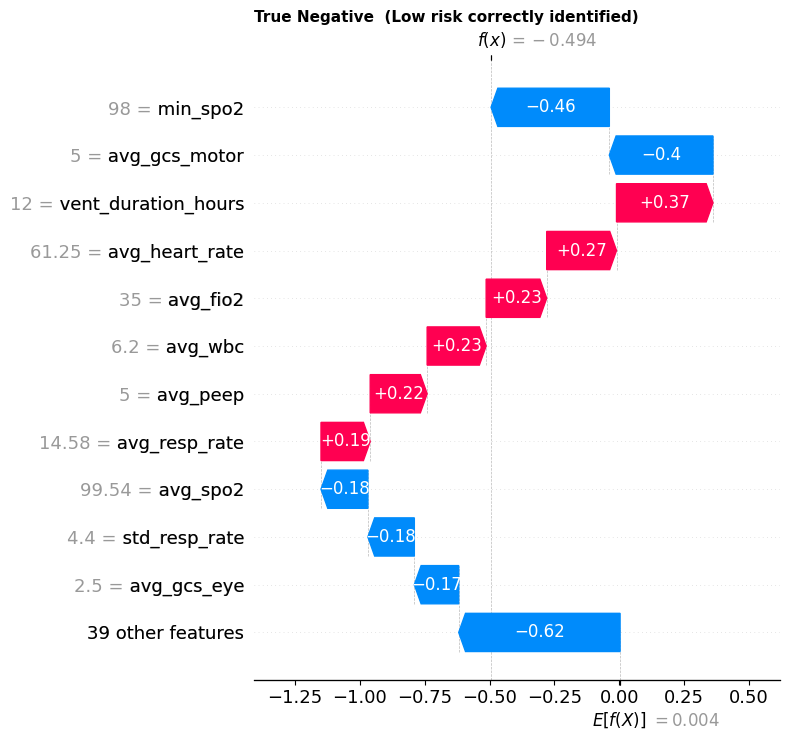


[saved] waterfall plots -> phase5_outputs/figure_5_6_waterfall_*.png


In [1]:
# ===================================================================
# Section 5.6 | Local Explanations (Patient-Level SHAP)
# ===================================================================
# A patient-specific waterfall plot decomposes any individual
# prediction into additive feature contributions on top of the
# expected log-odds.  We illustrate four canonical archetypes:
#   1. True Positive   (correctly flagged failure)
#   2. False Negative  (failure missed by the model)
#   3. False Positive  (false alarm)
#   4. True Negative   (correctly identified low risk)
# -------------------------------------------------------------------

import joblib
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Self-contained: load Phase 4 artifacts if missing ──
def _safe_load(name: str, fallback_path: str):
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

best_model   = _safe_load('best_model',   'best_model.pkl')
X_test       = _safe_load('X_test',       'X_test.pkl')
y_test       = _safe_load('y_test',       'y_test.pkl')
results      = _safe_load('results',      'results.pkl')
best_name    = _safe_load('best_name',    'best_name.pkl')

y_test_arr = np.asarray(y_test).astype(int)
FEATURES   = list(X_test.columns)
OUT_DIR    = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)

# ── Self-contained: compute SHAP values if Section 5.5 was skipped ──
if 'SHAP_IDX' not in globals():
    np.random.seed(42)
    n_shap = min(500, len(X_test))
    SHAP_IDX = np.random.choice(len(X_test), size=n_shap, replace=False)
    print(f'[SHAP] Sampled {n_shap} test instances for local explanation.')

if 'SHAP_X' not in globals():
    SHAP_X = X_test.iloc[SHAP_IDX].copy()
    SHAP_Y = y_test_arr[SHAP_IDX]

if 'shap_values' not in globals() or 'explainer' not in globals():
    clf_step = (best_model.named_steps['clf']
                if hasattr(best_model, 'named_steps')
                else best_model)
    explainer = shap.TreeExplainer(clf_step)
    sv = explainer.shap_values(SHAP_X.values)
    if isinstance(sv, list):
        shap_values = np.asarray(sv[1])
    else:
        shap_values = np.asarray(sv)
    print('[SHAP] TreeSHAP values computed for sampled instances.')

best_thr    = results[best_name]['threshold']
shap_probs  = np.asarray(results[best_name]['y_prob'])[SHAP_IDX]
y_pred_shap = (shap_probs >= best_thr).astype(int)

archetypes = {
    'True Positive  (Failure correctly identified)' : (SHAP_Y == 1) & (y_pred_shap == 1),
    'False Negative (Failure MISSED)'               : (SHAP_Y == 1) & (y_pred_shap == 0),
    'False Positive (False alarm)'                  : (SHAP_Y == 0) & (y_pred_shap == 1),
    'True Negative  (Low risk correctly identified)': (SHAP_Y == 0) & (y_pred_shap == 0),
}

# Pick the most "extreme" example in each cell:
#   - For positive-pred cases, choose the highest predicted prob.
#   - For negative-pred cases, choose the lowest predicted prob.
chosen = {}
for label, mask in archetypes.items():
    if mask.sum() == 0:
        print(f'[skip] no samples match archetype: {label}')
        continue
    if 'Positive' in label.split('(')[0]:          # positive prediction cells
        local_idx = int(np.argmax(np.where(mask, shap_probs, -np.inf)))
    else:
        local_idx = int(np.argmin(np.where(mask, shap_probs,  np.inf)))
    chosen[label] = local_idx

# Build an Explanation object for SHAP's modern plotting API
expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)) and np.ndim(expected_value) > 0:
    expected_value = float(np.asarray(expected_value).ravel()[-1])  # positive class
else:
    expected_value = float(expected_value)

print('=' * 78)
print(' FIGURE 5.6  |  Patient-Level Waterfall Explanations')
print('=' * 78)

for label, i in chosen.items():
    expl = shap.Explanation(
        values        = shap_values[i],
        base_values   = expected_value,
        data          = SHAP_X.iloc[i].values,   # raw clinical values for readability
        feature_names = FEATURES,
    )
    print(f'\n--- {label} ---')
    print(f'    Predicted P(failure) = {shap_probs[i]:.3f}   '
          f'True label = {int(SHAP_Y[i])}')
    fig = plt.figure(figsize=(10, 5.5))
    shap.plots.waterfall(expl, max_display=12, show=False)
    plt.title(label, fontsize=11, fontweight='bold', loc='left')
    plt.tight_layout()
    fname = (label.split('(')[0].strip()
             .replace(' ', '_').lower()) + '.png'
    plt.savefig(OUT_DIR / f'figure_5_6_waterfall_{fname}')
    plt.show()

print(f'\n[saved] waterfall plots -> {OUT_DIR}/figure_5_6_waterfall_*.png')


 TABLE 5.7 - Risk Stratification using XGBoost (test set, n=4,860)


,N,Failures,Mean_Pred_P,% of cohort,Observed rate,Lift vs prevalence,NNE
stratum,,,,,,,
Low (<10%),842,52,0.061,17.3%,6.2%,0.25x,16.200000
Moderate (10-25%),1744,271,0.170,35.9%,15.5%,0.64x,6.400000
High (25-50%),1588,435,0.349,32.7%,27.4%,1.12x,3.700000
Very High (>=50%),686,430,0.685,14.1%,62.7%,2.56x,1.600000


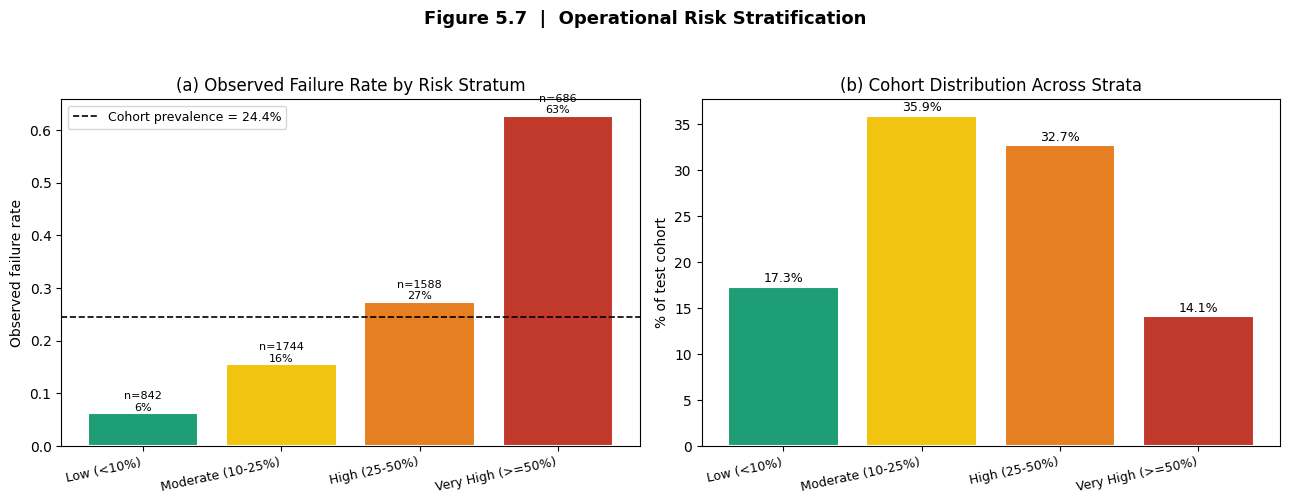


[saved] phase5_outputs/table_5_7_risk_stratification.csv
[saved] phase5_outputs/figure_5_7_risk_strata.png


In [2]:
# ===================================================================
# Section 5.7 | Clinical Risk Stratification
# ===================================================================
# Continuous probabilities are not how clinicians escalate care.
# We bucket predictions into four operationally meaningful tiers:
#
#     Low        : P < 0.10        -> routine monitoring
#     Moderate   : 0.10 <= P < 0.25 -> close observation
#     High       : 0.25 <= P < 0.50 -> RT review, NIV at bedside
#     Very High  : P >= 0.50        -> consider reintubation pre-empt
#
# For each stratum we report:
#   * N (% of cohort), observed failure rate
#   * Lift over base prevalence
#   * Positive Predictive Value, Number Needed to Evaluate (NNE)
# -------------------------------------------------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ── Self-contained: load Phase 4 artifacts if missing ──
def _safe_load(name: str, fallback_path: str):
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

results   = _safe_load('results',   'results.pkl')
best_name = _safe_load('best_name', 'best_name.pkl')
X_test    = _safe_load('X_test',    'X_test.pkl')
y_test    = _safe_load('y_test',    'y_test.pkl')

y_test_arr = np.asarray(y_test).astype(int)
PREVALENCE = float(y_test_arr.mean())
N_TEST     = len(y_test_arr)

OUT_DIR = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)

RISK_COLORS = ['#1D9E75', '#F1C40F', '#E67E22', '#C0392B']

best_prob = np.asarray(results[best_name]['y_prob'])

RISK_BINS   = [-0.001, 0.10, 0.25, 0.50, 1.001]
RISK_LABELS = ['Low (<10%)', 'Moderate (10-25%)', 'High (25-50%)', 'Very High (>=50%)']
risk_strata = pd.cut(best_prob, bins=RISK_BINS, labels=RISK_LABELS)

risk_df = pd.DataFrame({
    'predicted_p': best_prob,
    'true_label' : y_test_arr,
    'stratum'    : risk_strata,
})

agg = risk_df.groupby('stratum', observed=False).agg(
        N             =('true_label', 'size'),
        Failures      =('true_label', 'sum'),
        Mean_Pred_P   =('predicted_p', 'mean'),
)
agg['% of cohort']        = (agg['N'] / agg['N'].sum() * 100).round(1)
agg['Observed rate']      = (agg['Failures'] / agg['N']).fillna(0)
agg['Lift vs prevalence'] = agg['Observed rate'] / PREVALENCE
agg['NNE']                = (1 / agg['Observed rate']).replace(np.inf, np.nan).round(1)

print('=' * 88)
print(f' TABLE 5.7 - Risk Stratification using {best_name} (test set, n={N_TEST:,})')
print('=' * 88)

stratum_styler = (
    agg.style
       .format({'Mean_Pred_P'       : '{:.3f}',
                'Observed rate'     : '{:.1%}',
                'Lift vs prevalence': '{:.2f}x',
                '% of cohort'       : '{:.1f}%'})
       .background_gradient(subset=['Observed rate'], cmap='Reds')
       .set_caption(f'Cohort prevalence = {PREVALENCE:.1%}.  '
                    'NNE = patients reviewed per failure detected.')
)
display(stratum_styler)
agg.to_csv(OUT_DIR / 'table_5_7_risk_stratification.csv')

# ----- Figure 5.7 : observed vs predicted by stratum --------------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

ax0 = axes[0]
x = np.arange(len(agg))
bars = ax0.bar(x, agg['Observed rate'], color=RISK_COLORS[:len(agg)],
               edgecolor='white', linewidth=1.5)
ax0.axhline(PREVALENCE, color='black', ls='--', lw=1.2,
            label=f'Cohort prevalence = {PREVALENCE:.1%}')
ax0.set_xticks(x)
ax0.set_xticklabels(agg.index, rotation=12, ha='right', fontsize=9)
ax0.set_ylabel('Observed failure rate')
ax0.set_title('(a) Observed Failure Rate by Risk Stratum')
ax0.legend(fontsize=9)
for b, n, fr in zip(bars, agg['N'], agg['Observed rate']):
    ax0.text(b.get_x() + b.get_width() / 2, fr + 0.005,
             f'n={n}\n{fr:.0%}', ha='center', fontsize=8)

ax1 = axes[1]
ax1.bar(x, agg['% of cohort'],
        color=RISK_COLORS[:len(agg)], edgecolor='white', linewidth=1.5)
ax1.set_xticks(x)
ax1.set_xticklabels(agg.index, rotation=12, ha='right', fontsize=9)
ax1.set_ylabel('% of test cohort')
ax1.set_title('(b) Cohort Distribution Across Strata')
for i, v in enumerate(agg['% of cohort']):
    ax1.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

fig.suptitle('Figure 5.7  |  Operational Risk Stratification',
             fontsize=13, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(OUT_DIR / 'figure_5_7_risk_strata.png')
plt.show()

print(f'\n[saved] {OUT_DIR}/table_5_7_risk_stratification.csv')
print(f'[saved] {OUT_DIR}/figure_5_7_risk_strata.png')


In [3]:
# ===================================================================
# Section 5.8 | Subgroup Performance Audit (Algorithmic Fairness)
# ===================================================================
# Aggregate test-set metrics can mask systematic underperformance
# in clinically vulnerable subpopulations.  We slice the test set
# by clinically meaningful covariates available in the cohort:
#   - Age (tertiles)
#   - GCS total score (tertiles, neurological reserve)
#   - Ventilation duration (tertiles, prolonged-vent effect)
#   - Gender (binary)
#   - Predicted-risk band (sanity check from Section 5.7)
# Subgroups with n<30 are flagged but reported for transparency.
# -------------------------------------------------------------------
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_auc_score, recall_score

# ── Self-contained: load Phase 4 artifacts if missing ──
def _safe_load(name: str, fallback_path: str):
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

results   = _safe_load('results',   'results.pkl')
best_name = _safe_load('best_name', 'best_name.pkl')
X_test    = _safe_load('X_test',    'X_test.pkl')
y_test    = _safe_load('y_test',    'y_test.pkl')

y_test_arr = np.asarray(y_test).astype(int)
N_TEST     = len(y_test_arr)

OUT_DIR = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)

RISK_BINS   = [-0.001, 0.10, 0.25, 0.50, 1.001]
RISK_LABELS = ['Low (<10%)', 'Moderate (10-25%)', 'High (25-50%)', 'Very High (>=50%)']

# ---- Identify candidate stratification columns -------------------
CONT_CANDIDATES = {'age', 'apache_ii', 'apache_iv', 'apacheii', 'apacheiv',
                   'sofa', 'gcs', 'gcs_total', 'bmi',
                   'vent_duration_hours', 'comorbidity_count'}
BIN_CANDIDATES  = {'gender', 'sex', 'on_vasopressor'}

cont_cols = [c for c in X_test.columns if c.lower() in CONT_CANDIDATES]
bin_cols  = [c for c in X_test.columns if c.lower() in BIN_CANDIDATES
             or c.lower().startswith(('sex_', 'gender_'))]

print(f'Continuous stratifiers : {cont_cols or "[none]"}')
print(f'Binary stratifiers     : {bin_cols or "[none]"}')

best_prob = np.asarray(results[best_name]['y_prob'])
best_pred = (best_prob >= results[best_name]['threshold']).astype(int)

# Rebuild risk strata from probabilities
risk_strata = pd.cut(best_prob, bins=RISK_BINS, labels=RISK_LABELS)

subgroup_records = []

def _record(label: str, mask: np.ndarray):
    n = int(mask.sum())
    if n == 0:
        return
    yt = y_test_arr[mask]
    yp = best_prob[mask]
    yh = best_pred[mask]
    auc = roc_auc_score(yt, yp) if len(np.unique(yt)) >= 2 else np.nan
    subgroup_records.append({
        'Subgroup'    : label,
        'N'           : n,
        'Failure rate': yt.mean(),
        'ROC-AUC'     : auc,
        'Sensitivity' : recall_score(yt, yh, zero_division=0),
        'Specificity' : recall_score(yt, yh, pos_label=0, zero_division=0),
        'Flag'        : '!' if n < 30 else '',
    })

# Overall reference
_record('Overall (reference)', np.ones(N_TEST, dtype=bool))

# Continuous -> tertile bins
for col in cont_cols:
    vals = X_test[col].values
    try:
        edges = np.quantile(vals, [0, 1/3, 2/3, 1])
        bins  = np.digitize(vals, edges[1:-1])
        for b, name in zip([0, 1, 2], ['low tertile', 'mid tertile', 'high tertile']):
            _record(f'{col} | {name}', bins == b)
    except Exception:
        continue

# Binary columns (0/1)
for col in bin_cols:
    vals = X_test[col].values
    _record(f'{col} = 1', vals.astype(bool))
    _record(f'{col} = 0', ~vals.astype(bool))

# Predicted-risk band (sanity check)
for label in RISK_LABELS:
    _record(f'risk band: {label}', risk_strata == label)

sub_tbl = pd.DataFrame(subgroup_records)
print('\n' + '=' * 90)
print(f' TABLE 5.8 - Subgroup Performance ({best_name}, test set)')
print('         "!" flags subgroups with n<30 (estimates may be unstable)')
print('=' * 90)

display(sub_tbl.style.format({'Failure rate': '{:.1%}',
                              'ROC-AUC'     : '{:.3f}',
                              'Sensitivity' : '{:.3f}',
                              'Specificity' : '{:.3f}'})
        .background_gradient(subset=['ROC-AUC'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

sub_tbl.to_csv(OUT_DIR / 'table_5_8_subgroup_audit.csv', index=False)
print(f'\n[saved] {OUT_DIR}/table_5_8_subgroup_audit.csv')


Continuous stratifiers : ['age', 'vent_duration_hours', 'comorbidity_count', 'gcs_total']
Binary stratifiers     : ['gender', 'on_vasopressor']

 TABLE 5.8 - Subgroup Performance (XGBoost, test set)
         "!" flags subgroups with n<30 (estimates may be unstable)


,Subgroup,N,Failure rate,ROC-AUC,Sensitivity,Specificity,Flag
0,Overall (reference),4860,24.4%,0.757,0.588,0.789,
1,age | low tertile,1618,19.0%,0.770,0.510,0.856,
2,age | mid tertile,1587,24.0%,0.741,0.572,0.801,
3,age | high tertile,1655,30.2%,0.739,0.647,0.701,
4,vent_duration_hours | low tertile,1603,15.2%,0.737,0.387,0.914,
5,vent_duration_hours | mid tertile,1630,22.9%,0.722,0.525,0.776,
6,vent_duration_hours | high tertile,1627,35.2%,0.737,0.713,0.643,
7,comorbidity_count | low tertile,1550,15.2%,0.777,0.400,0.931,
8,comorbidity_count | mid tertile,1569,24.5%,0.744,0.536,0.813,
9,comorbidity_count | high tertile,1741,32.7%,0.702,0.699,0.606,



[saved] phase5_outputs/table_5_8_subgroup_audit.csv


In [ ]:
# ===================================================================
# Section 5.9 | Executive Summary & Artifact Manifest
# ===================================================================
# Consolidated narrative + machine-readable index of every figure
# and table produced in Chapter 5.  This is the single block to
# screenshot for the dissertation defense / committee meeting.
# -------------------------------------------------------------------
import json
import joblib
import numpy as np
import pandas as pd
from pathlib import Path

# ── Self-contained: load Phase 4 artifacts if missing ──
def _safe_load(name: str, fallback_path: str):
    if name in globals():
        return globals()[name]
    return joblib.load(fallback_path)

results   = _safe_load('results',   'results.pkl')
best_name = _safe_load('best_name', 'best_name.pkl')
y_test    = _safe_load('y_test',    'y_test.pkl')

y_test_arr = np.asarray(y_test).astype(int)
N_TEST     = len(y_test_arr)
PREVALENCE = float(y_test_arr.mean())

OUT_DIR = Path('phase5_outputs')
OUT_DIR.mkdir(exist_ok=True)

RISK_LABELS = ['Low (<10%)', 'Moderate (10-25%)', 'High (25-50%)', 'Very High (>=50%)']

# ── Load Chapter 5 output tables if in-memory objects are missing ──
if 'perf_df' in globals():
    perf_df = globals()['perf_df'].copy()
else:
    perf_df = pd.read_csv(OUT_DIR / 'table_5_1_advanced_metrics.csv')
    perf_df = perf_df.set_index('Model')

if 'boot_tbl' in globals():
    boot_tbl = globals()['boot_tbl'].copy()
else:
    boot_tbl = pd.read_csv(OUT_DIR / 'table_5_4a_bootstrap_ci.csv')
    boot_tbl = boot_tbl.set_index('Model')

if 'shap_imp' in globals():
    shap_imp = globals()['shap_imp'].copy()
else:
    shap_imp = pd.read_csv(OUT_DIR / 'table_5_5_shap_importance.csv')

best_row = perf_df.loc[best_name]
best_b   = boot_tbl.loc[best_name] if best_name in boot_tbl.index else None

print('=' * 78)
print(' CHAPTER 5  -  EXECUTIVE SUMMARY')
print('=' * 78)
print(f'  Cohort (test split)        : N = {N_TEST:,}')
print(f'  Failure prevalence         : {PREVALENCE:.1%}')
print(f'  Best-performing model      : {best_name}')
print(f'  Tuned operating threshold  : {results[best_name]["threshold"]:.3f}')
print('-' * 78)
print('  Headline test-set metrics:')
print(f'     ROC-AUC      = {best_row["ROC-AUC"]:.3f}')
print(f'     PR-AUC       = {best_row["PR-AUC"]:.3f}')
print(f'     F1           = {best_row["F1"]:.3f}')
print(f'     Sensitivity  = {best_row["Sensitivity"]:.3f}')
print(f'     Specificity  = {best_row["Specificity"]:.3f}')
print(f'     Brier        = {best_row["Brier"]:.4f}')
print(f'     ECE          = {best_row.get("ECE", "N/A"):.4f}' if 'ECE' in best_row.index else '     ECE          = N/A')
if best_b is not None:
    print('-' * 78)
    print('  Bootstrap 95% CIs (BCa, N=1000):')
    for m in ['ROC-AUC', 'PR-AUC', 'F1', 'Sensitivity', 'Specificity', 'Brier']:
        print(f'     {m:<12s} {best_b[m]}')
print('-' * 78)
top_features = shap_imp['Feature'].head(5).tolist()
print('  Top-5 SHAP drivers          : ' + ', '.join(top_features))
print('  Risk strata                 : ' + ', '.join(RISK_LABELS))
print('=' * 78)

# ---- Artifact manifest -------------------------------------------
artifacts = sorted([p.name for p in OUT_DIR.iterdir() if p.is_file()])
manifest = pd.DataFrame({'Artifact': artifacts,
                         'Type'    : [Path(a).suffix.lstrip('.').upper()
                                      for a in artifacts]})
print(f'\n CHAPTER 5 ARTIFACTS  ->  {OUT_DIR}')
display(manifest)
manifest.to_csv(OUT_DIR / 'manifest.csv', index=False)

# ---- Persist a JSON-friendly summary for downstream LaTeX --------
summary_json = {
    'best_model'      : best_name,
    'threshold'       : float(results[best_name]['threshold']),
    'n_test'          : int(N_TEST),
    'prevalence'      : float(PREVALENCE),
    'metrics'         : perf_df.loc[best_name][
        ['ROC-AUC', 'PR-AUC', 'F1', 'Sensitivity', 'Specificity',
         'Brier']].astype(float).to_dict(),
    'top_features'    : top_features,
    'risk_strata_csv' : str((OUT_DIR / 'table_5_7_risk_stratification.csv').resolve()),
}
with open(OUT_DIR / 'summary.json', 'w') as f:
    json.dump(summary_json, f, indent=2)

print(f'\n[saved] {OUT_DIR}/manifest.csv')
print(f'[saved] {OUT_DIR}/summary.json')
print('\n*** Chapter 5 evaluation pipeline complete. ***')


NameError: name 'perf_df' is not defined